## Identifying burnout level and whether a person seeks professional help, <br> author: `Kacper Gawroński`

### Why this dataset?
I' ve found this dataset quite interesting, because of two factors - The subject of this dataset is quite intriguing and the nature of this dataset required some additional steps for finding the best model. It taught me that some models, even though they have lesser global accuracy and other metrics, they might be the best choice for some problems. (**One class value is nearly non-existent, but is the most important one**)

#### Notes
Some cells save files in csv or other formats, instead of using the existing values, because previously this one notebook was split into few .py and .ipnyb files

# STEP 1 : Data download

In [1]:
import kagglehub
import re
import shutil

C:\Users\kacpe\PycharmProjects\GGSN_projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from pathlib import Path

ROOT_PATH = Path("./")

save_dir = "./data"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [2]:
def _remove_no_csv_files():
    data_path = ROOT_PATH / "data"
    for file in data_path.iterdir():
        if re.fullmatch(r".*\.csv$", file.name):
            continue

        if file.is_file():
            file.unlink()
        else:
            shutil.rmtree(str(file))


def download_dataset_kaggle(dataset_name):
    path = ROOT_PATH / "data"
    kagglehub.dataset_download(dataset_name, output_dir=path)
    _remove_no_csv_files()

Above functions automatically downloads the specified dataset from kaggle, and remove redundant files and simplifies the files structure of the downloaded files (they are really nested)

In [5]:
download_dataset_kaggle("suhanigupta04/employee-mental-health-and-burnout-dataset")

100%|██████████| 3.95M/3.95M [00:00<00:00, 4.34MB/s]

Extracting files...


## STEP 2 : (short) EDA

In [3]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
data = pd.read_csv(ROOT_PATH / "data" / "tech_mental_health_burnout.csv")

In [8]:
data.head()

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


At first glance, this dataset has a lot of informative features, where each one provides some insight on why someone could experience bigger than usual `burnout_level`

In [9]:
data.info(verbose=True)
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  str    
 2   job_role                 150000 non-null  str    
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  str    
 5   work_mode                150000 non-null  str    
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  physical_activi

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,38.025340,5.055010,47.00758,6.127180,4.010893,1.284193,5.500248,5.497537,5.016357,6.499120,2.599833,8.002713,2.101693,5.498163,0.251133,5.785428,4.523763,3.096687,2.114121,0.096333
std,9.510609,2.878602,7.89331,3.783618,1.978316,1.426264,1.956102,1.956915,1.948553,1.192343,1.814880,1.987813,1.300247,1.957432,0.433667,1.331506,1.201506,1.187668,1.112614,0.295049
min,22.000000,0.000000,30.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,30.000000,3.000000,42.00000,3.000000,3.000000,0.000000,4.200000,4.100000,3.700000,5.700000,1.000000,6.700000,1.000000,4.200000,0.000000,4.900000,3.700000,2.200000,1.000000,0.000000
50%,38.000000,5.000000,47.00000,6.000000,4.000000,1.000000,5.500000,5.500000,5.000000,6.500000,2.000000,8.000000,2.000000,5.500000,0.000000,5.800000,4.500000,3.100000,1.900000,0.000000
75%,46.000000,7.000000,52.00000,9.000000,5.000000,2.000000,6.900000,6.800000,6.400000,7.300000,4.000000,9.300000,3.000000,6.800000,1.000000,6.700000,5.300000,3.900000,2.800000,0.000000
max,54.000000,18.500000,84.00000,24.000000,12.000000,5.000000,10.000000,10.000000,10.000000,10.000000,7.000000,16.000000,5.000000,10.000000,1.000000,10.000000,9.600000,8.100000,8.100000,1.000000


We can see that this dataset is very clean - there is no null values that we would need to fill or get rid off <br>
Some features are `strings` which we will later turn into numerical values

In [10]:
# Check the unique values for job_role
unique_jobs = data['job_role'].unique()
unique_jobs

<StringArray>
[ 'Backend Developer', 'Frontend Developer',             'DevOps',
     'Data Scientist',  'Software Engineer',    'Product Manager',
        'QA Engineer',        'ML Engineer']
Length: 8, dtype: str

In [11]:
# Check the burnout_level (one of target classes) distribution

class_distribution = data['burnout_level'].value_counts()
class_distribution

burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64

In [12]:
# Check the same for seeks_professional_help

seeks_help_distribution = data['seeks_professional_help'].value_counts()
seeks_help_distribution

seeks_professional_help
0    135550
1     14450
Name: count, dtype: int64

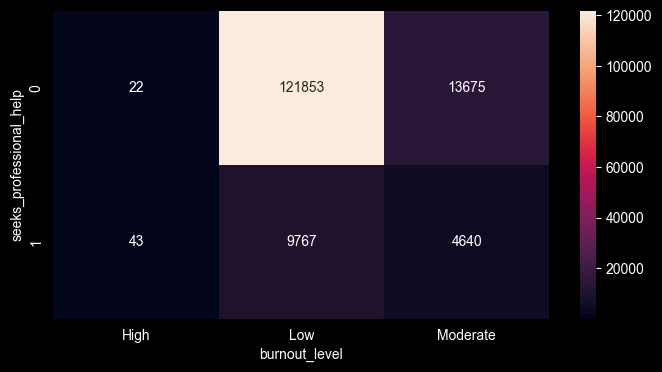

In [9]:
def show_y_data_distribution(data: pd.DataFrame):
    data_for_heatmap = data.groupby(['burnout_level', 'seeks_professional_help']).size().reset_index(name='count')
    data_for_heatmap = data_for_heatmap.pivot(columns='burnout_level', values='count', index='seeks_professional_help')
    plt.figure(figsize = (8,4))
    sns.heatmap(data_for_heatmap, annot=True, fmt='g')


show_y_data_distribution(data.copy())

As we can see, the dataset is very imbalanced, only 65 people are having `burnout_level` that is `High`, People with `Low burnout_level` that do not `seek professional help` dominate.

Let's build a simple model using only few parameters to see the possible obstacles when working with this dataset

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

xtrain, ytrain, xtest, ytest = train_test_split( data[['age', 'experience_years', 'overtime_hours', 'job_satisfaction', 'work_life_balance']],  data['burnout_level'], test_size=0.2, random_state=42)


clf = DecisionTreeClassifier()
clf.fit(xtrain, xtest)

y_pred = clf.predict(ytrain)
print(accuracy_score(ytest, y_pred))

confusion_matrix(ytest, y_pred)

0.804


array([[    0,     5,     4],
       [   15, 23160,  3147],
       [   10,  2699,   960]])

As we can see, the single tree performed well, scoring roughly 80% accuracy. One problem is that the model did not predict correctly not even a single time the class 0, which is the crucial one - it identifies the units with high burnout. In the next step I will perform few actions to remedy this issue.

## STEP 3 : Data transform

Few things are needed to enhance the quality of this dataset and to made it processable by the models:
- Some features are categorical ones, that need to be One-Hot Encoded, for this I will use the `OneHotEncoder` class from `scikit-learn`
- There are two targets, `burnout_level` and `seeks_professional_help`, to simplify this task they will be combined into one class, doing this does not produce a lot of new possible labels, 6 are what we are working with, which is fine
- As what was presented before, this dataset is largely imbalanced, one class dominates over the other, the `Low, does not seek professional help` one, to fight with this problem I will combine undersampling with upsampling to make the training more fair, and help the model capture all classes, this is not the perfect solution still, and later I will provide an additional tool that helps with this problem. Coming back to the under/up sampling process, first I will use RandomDownsample for speed, and the generate more samples using SMOTE.
- Of course, this dataset will be used in training for some of the classical methods, so the data needs to be scaled (NN will also benefit from this as well, but some classical methods rely on the data scaling), for this I will use the `StandardScaler` from scikit-learn

***Functions overview***
- `create_column_transformer`, function that creates small pipeline for transforming the whole dataset, which is required for training, validating and testing, it uses `OneHotEncode` and `StandardScaler`
- `transform_dataset`, this function handles the whole process of the data transformation except for up/down sampling, it uses the function mentioned above and combines the two targets into one
- `resample_dataset`, this function performs RandomDownsampling and right after the SMOTE, the values for these two steps were selected based on the sample numbers for each ***new*** target value
- `recreate_df`, helper function for recreating the x and y into one dataset again

In [5]:
from typing import Any
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from pprint import pprint




def create_column_transformer(*args) -> ColumnTransformer | None:
    transformations = [transform for transform in args]
    try:
        column_transformer = ColumnTransformer(transformations, remainder='passthrough')
        column_transformer.set_output(transform="pandas")
        return column_transformer
    except Exception as e:
        print(e)
    return None

def transform_dataset(data_to_transform: pd.DataFrame) -> tuple[pd.DataFrame, dict[Any, Any]]:
    string_columns = data_to_transform.select_dtypes(['string']).columns.tolist()
    string_columns.remove('burnout_level')

    scaled_columns = data_to_transform.select_dtypes(['float']).columns.tolist()
    scaled_columns.extend(['age', 'caffeine_intake', 'deadlines_missed', 'physical_activity_days'])

    standard_scaler = ("scaler", StandardScaler(), scaled_columns)
    one_hot_encoder = ("ohencoder", OneHotEncoder(sparse_output=False), string_columns)

    column_transformer = create_column_transformer(standard_scaler, one_hot_encoder)

    label_encoder = LabelEncoder()

    x = data_to_transform.drop(columns=['burnout_level', 'seeks_professional_help'])
    y = data_to_transform['burnout_level'].astype('str') + '_' + data_to_transform['seeks_professional_help'].astype('str')

    y_encoded = label_encoder.fit_transform(y)
    class_names = dict(enumerate(label_encoder.classes_))


    data_x: pd.DataFrame = column_transformer.fit_transform(x)

    data_x['target'] = y_encoded
    data_x.columns = data_x.columns.str.replace(r'^.*?__', '', regex=True)


    return data_x, class_names


def resample_dataset(data_to_transform: pd.DataFrame, y = None) -> pd.DataFrame:

    data_to_transform.reset_index(drop=True, inplace=True)

    if y is None:
        y = data_to_transform['target']

    _, num_classes = np.unique_counts(y)

    print(num_classes)

    sampling_dict_undersample = {
        2 : 20_000,
    }

    sampling_dict_oversample = {
        0: 800,
        1: 800,
        5: 4000
    }

    random_under_sampler = RandomUnderSampler(random_state=42, sampling_strategy=sampling_dict_undersample)
    smote_sampler = SMOTE(random_state=42, sampling_strategy=sampling_dict_oversample)


    data_x, data_y = random_under_sampler.fit_resample(data_to_transform, y)
    data_x, data_y = smote_sampler.fit_resample(data_x, data_y)

    data_x['target'] = data_y

    return data_x


def recreate_df(x: pd.DataFrame, y) -> pd.DataFrame:
    x['target'] = y
    return x




Here I am using the above functions to perform the full transform, for splitting data I'm using the `stratify` option which guarantees that each class will be divided individually to match the test_size parameter, then each dataset is saved as different csv file

In [9]:
transformed_data, classes = transform_dataset(data)

x_train, x_test, y_train, y_test = train_test_split(transformed_data.drop('target', axis=1),
                                                    transformed_data['target'], test_size=0.2,
                                                    stratify=transformed_data['target'], random_state=42)


x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


recreate_df(x_train, y_train).to_csv(ROOT_PATH / "data" / "train_data_unedited.csv", index=False, header=True)

train_dataset = resample_dataset(x_train, y_train)



train_dataset.to_csv(ROOT_PATH / "data" / "train_data.csv", index=False, header=True)
recreate_df(x_test, y_test).to_csv(ROOT_PATH / "data" / "test_data.csv", index=False, header=True)
recreate_df(x_val, y_val).to_csv(ROOT_PATH / "data" / "val_data.csv", index=False, header=True)

with open(ROOT_PATH / "data" / "classes_info.json", 'w', newline='') as classes_json:
    classes_json.write(json.dumps(classes, indent=2))


[   14    27 77986  6251  8752  2970]


## STEP 4: Model creation and hyperparams search

So, the first action in this step is to create some Model class, that will enable for smooth hyperparameters search.

Overview of the possibilities of the "model factory" class:
- Accepts the number of starting `neurons` which are later cut to be 2 times smaller than previous layer
- Accepts the dropout rate as a list or scalar, in case of a list it applies i-th `Dropout` after the i-th block
- Accepts different activation functions as a list or scalar, one `_SimpleBlock` block uses the same activation for each `linear block`
- Accepts the list of booleans or one boolean value to decide whether to apply the `Batch Normalization`
- Accepts the list of booleans or one boolean value to decide whether to apply the `skipping connection`, for this purpose the   `_SimpleBlock` has two `linear blocks`, it means that the model will consist of minimum one `_SimpleBlock` that accepts the `neurons_in` as a starting point which is the number of features, in the end the finished model architecture will have odd number od linear blocks, except the final one


In [6]:
from torch import nn


class _SimpleBlock(nn.Module):
    def __init__(self, neurons_in, neurons_out, activation: nn.Module, dropout, is_batch_norm, is_skipping_conn):
        super().__init__()

        self.linear1 = nn.Linear(neurons_in, neurons_out)
        self.linear2 = nn.Linear(neurons_out, neurons_out)

        if isinstance(activation, type):
            self.activation1 = activation()
            self.activation2 = activation()
        elif isinstance(activation, nn.Module):
            self.activation1 = activation
            self.activation2 = activation
        else:
            self.activation1 = nn.ReLU()
            self.activation2 = nn.ReLU()

        if is_batch_norm:
            self.batch_norm1 = nn.BatchNorm1d(neurons_out)
            self.batch_norm2 = nn.BatchNorm1d(neurons_out)

        if dropout > 0:
            self.dropout = nn.Dropout(dropout)

        if neurons_in == neurons_out and is_skipping_conn:
            self.skip_connection = nn.Identity()
        elif neurons_in != neurons_out and is_skipping_conn:
            self.skip_connection = nn.Linear(neurons_in, neurons_out)


    def forward(self, x):

        skip_val = x

        out = self.linear1(x)
        if hasattr(self, 'batch_norm1'):
            out = self.batch_norm1(out)

        out = self.activation1(out)

        if hasattr(self, 'dropout'):
            out = self.dropout(out)

        out = self.linear2(out)
        if hasattr(self, 'batch_norm2'):
            out = self.batch_norm2(out)

        if hasattr(self, 'skip_connection'):
            out = self.activation2(out + self.skip_connection(skip_val))
        else:
            out = self.activation2(out)

        if hasattr(self, 'dropout'):
            out = self.dropout(out)

        return out



class Model(nn.Module):

    def __init__(self, neurons : int, dropouts, is_batchnorm, activations, is_skipping_conn, input_shape, output_shape, name = "model_default_name"):
        super().__init__()

        self.train_info = None
        self.first_layer = _SimpleBlock(input_shape, neurons, activations[0], dropouts[0], is_batchnorm[0], is_skipping_conn[0])
        self.hidden = nn.Sequential(
            *[_SimpleBlock(neurons // i , neurons // (i + 1), activations[i], dropouts[i], is_batchnorm[i], is_skipping_conn[i])
              for i in range(1, len(activations))],
        )
        self.output_layer = nn.Linear(neurons // max(len(activations), 1), output_shape)
        self.name = name
        self.model_info = {"model": {
            "neurons": neurons,
            "dropouts": dropouts,
            "is_batchnorm": is_batchnorm,
            "activations": [act.__name__ if isinstance(act, type) else act.__class__.__name__ for act in activations ],
            "is_skipping_conn": is_skipping_conn,
            "input_shape": input_shape,
            "output_shape": output_shape,
            "name": self.name
        }}

    def forward(self, x):

        out = self.first_layer(x)
        out = self.hidden(out)
        out = self.output_layer(out)
        return out

    def add_training_info(self, train_info):
        self.model_info["train"] = train_info





Basic implementation of the `Dataset` class required by torch <br>
The `ModelHistory` class exists for a purpose of gathering data  during training and validation, it accepts metric that are functions which takes `y_true` and `y_pred` as an arguments

In [7]:
import pandas as pd
from torch.utils.data import Dataset
from utils import ROOT_PATH

class BurnoutDataset(Dataset):
    def __init__(self, data_type):
        if data_type == "train":
            df = pd.read_csv(ROOT_PATH / "data" / "train_data.csv")
        elif data_type == "test":
            df = pd.read_csv(ROOT_PATH / "data" / "test_data.csv")
        elif data_type == "val":
            df = pd.read_csv(ROOT_PATH / "data" / "val_data.csv")
        elif data_type == "unedited":
            df = pd.read_csv(ROOT_PATH / "data" / "train_data_unedited.csv")
        else:
            raise NotImplementedError

        self.x = df.drop('target', axis=1).values
        self.y = df['target'].values

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class ModelHistory:
    """
    Simple class for tracking model's metrics, for each different evaluation add new step
    """

    # TODO switch steps to 3 static names: training, val, test
    def __init__(self, steps, name , **kwargs):
        self.history = dict()
        self.metrics = dict()
        self.name = name

        for step in steps:
            self.history[step] = {
                'loss': [],
            }

        for k, v in kwargs.items():
            self.metrics[k] = v
            for step in steps:
                self.history[step][k] = []


    def calculate_metrics(self, step_name, y_true, y_pred):
        for k, metric in self.metrics.items():
            self.history[step_name][k].append(metric(y_true, y_pred))


    def get_metrics(self):
        return ['loss'].extend(list(self.metrics.keys()))

    def add_loss(self, step_name, loss):
        self.history[step_name]['loss'].append(loss)


Basic implementation of the training process:
- Accepts the `model` which is going to be trained
- Accepts the `batch_size` argument which decides on the batch size
- Accepts `epochs` number for which the model will be trained
- Accepts the `learning rate` which will be used during training
- Accepts the `weight decay` used by the optimizer which acts as L2 regularization
- Accepts the `optimizer` used during the training process
- Accepts the `criterion` which calculates the loss
- Accepts the `device_type` which is simply for deciding on which device to make the training
- Accepts the metrics used to calculate additional data

In [32]:
import torch
from torch.utils.data import DataLoader

from tqdm import tqdm

def _train_one_epoch(model, train_data, device, criterion, optimizer, history = None):

        model.train()

        current_epoch_preds = []
        current_epoch_targets = []
        epoch_loss = 0
        pbar = tqdm(train_data)

        for batch in pbar:
            x, y = batch
            x, y = x.to(device).float(), y.to(device)

            out = model(x)

            loss = criterion(out, y)

            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_loss += loss.item()

            predicted = torch.argmax(out, dim=1)

            current_epoch_preds.extend(predicted.detach().cpu().tolist())
            current_epoch_targets.extend(y.detach().cpu().tolist())

        if history is None:
            return


        epoch_loss = epoch_loss / len(train_data)
        history.add_loss("train", epoch_loss)
        history.calculate_metrics("train", current_epoch_targets, current_epoch_preds)


def _val_one_epoch(model, val_data, device, criterion, history = None):
    current_val_preds = []
    current_val_targets = []
    val_loss = 0

    pbar = tqdm(val_data)

    model.eval()

    with torch.no_grad():
        for batch in pbar:
            x, y = batch
            x, y = x.to(device).float(), y.to(device)

            out = model(x)

            loss = criterion(out, y)

            val_loss += loss.item()

            predicted = torch.argmax(out, dim=1)

            current_val_preds.extend(predicted.detach().cpu().tolist())
            current_val_targets.extend(y.detach().cpu().tolist())


    if history is None:
        return

    val_loss = val_loss / len(val_data)
    history.add_loss("val", val_loss)
    history.calculate_metrics("val", current_val_targets, current_val_preds)



def train_model(model, batch_size, epochs, learning_rate, weight_decay, optimizer, criterion, device, metrics: dict = None):

    optimizer = optimizer(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    train_data = DataLoader(BurnoutDataset("train"), batch_size=batch_size, shuffle=True)
    val_data = DataLoader(BurnoutDataset("val"), batch_size=batch_size, shuffle=True)

    if metrics is not None:
        history = ModelHistory(["train", "val"], model.name,  **metrics)
    else:
        history = ModelHistory(["train", "val"], model.name)

    for epoch in range(epochs):

        _train_one_epoch(model, train_data, device, criterion, optimizer, history)
        _val_one_epoch(model, val_data, device, criterion, history)


    train_info = {
        "epochs": epochs,
        "optimizer" : optimizer.__class__.__name__,
        "criterion" : criterion.__class__.__name__,
        "batch_size" : batch_size,
        "learning_rate" : learning_rate,
        "lr_decay" : weight_decay,
    }

    model.add_training_info(train_info)


    return model, history


Function created for model testing to gather the predicted target class values for the test set

In [9]:
from tqdm import tqdm
import torch

def test_model(model, test_data, criterion, device):
    current_val_preds = []
    current_val_targets = []
    val_loss = 0

    pbar = tqdm(test_data, leave=False)

    model.eval()

    with torch.no_grad():
        for batch in pbar:
            x, y = batch
            x, y = x.to(device).float(), y.to(device)

            out = model(x)

            loss = criterion(out, y)

            val_loss += loss.item()

            predicted = torch.argmax(out, dim=1)

            current_val_preds.extend(predicted.detach().cpu().tolist())
            current_val_targets.extend(y.detach().cpu().tolist())

    return val_loss, current_val_preds, current_val_targets


In [10]:
import json
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_fscore_support
from torch.optim import Adam
from functools import partial
from sklearn.model_selection import ParameterGrid
import seaborn as sns
import numpy as np


Here I'm using `partial` to create metrics suitable for the `ModelHistory`, they calculate the global metrics for the whole dataset, keeping in mind the class distribution.

#### Important
These metrics use `average=weighted`, which means that they take into account that some classes have fewer samples, the `f1_score_metric` is later used to pick top models when searching for hyperparameters, that means it will pick models that should be more sensitive to the outcomes of classes with fewer samples

In [11]:
f1_score_metric = partial(f1_score, average="weighted")
recall_metric = partial(recall_score, average="weighted")
precision_metric = partial(precision_score, average="weighted", zero_division = 0)

Initializing the required datasets

In [12]:
train_dataset = BurnoutDataset("train")
train_dataset_unedited = BurnoutDataset("unedited")
test_dataset = BurnoutDataset("test")
val_dataset = BurnoutDataset("val")

Function that plots the metrics gathered during training, parameter `setp_name` decides which stage should be plotted (training or validating)

In [13]:
def plot_history(step_name: str, model_history: ModelHistory, max_img_per_width = 3):
    import math
    try:
        metrics_used = model_history.history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        curr_ax.plot(metrics_used[metric])
        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()




Function `plot_histories` accepts the list of `ModelHistory` to plot metrics for all the models

In [14]:
def _plot_step_for_models(names: list[str], data, ax: plt.Axes):
    import seaborn as sns
    for name, data in zip(names, data):
        sns.lineplot(x=range(len(data)), y=data, ax=ax, label=name)


def plot_histories(step_name: str, histories: list[ModelHistory], max_img_per_width = 3):
    import math
    try:
        metrics_used = histories[0].history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    models_names = [history.name for history in histories]

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        _plot_step_for_models(models_names, [history.history[step_name][metric] for history in histories], curr_ax)

        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()

The `train_many_models` function acts as `RandomSearch` for finding the best hyperparameters for a model, it uses the dictionary to keep track of the best models which is based on the model loss during validation <br>
 `_find_worst_model` function returns the worst_model from the dictionary of the stored models <br>
 `_get_weights_for_classes_x` functions are here to better help with the discrepancy in the data, it tells the criterion to penalize the model for the mistakes done on the classes with fewer samples in the dataset
 - **`_get_weights_for_classes`** uses the formula $ \frac{n}{n_i * unique(n)} $ for calculating the weight where $n$ is the number of datapoints, $n_i$ is the number of datapoints for the i-th class and the $unique(n)$ is the number of classes
  - **`_get_weights_for_classes_sqrt`** uses similar formula to calculate the weights which is $ \sqrt{\frac{n}{n_i * unique(n)}}$, which do not penalize the model that much
The effects of these techniques will be presented later <br>

`train_many_models` function is the core of the hyperparameters search, where it performs the `RandomSearch`. The parameters that can be optimized are:
- Neurons number
- Layers number
- Activations used for each layer
- Dropouts used after each layer
- Learning rate used during training
- Weight decays used during training
- Optimizer used during training
- Whether to use skipping connection in each layer
- Whether to use Batch Normalization on each layer
- Batch size

**Additional parameter used here is whether to add weights to classes for the criterion, but it will be tested manually**


There is also deterministic version of this function which will be used for checking single parameters of the model

In [15]:
import random
import pandas as pd
import itertools

def _find_worst_model(models: dict, on: str = 'loss'):
    worst_model_name = None
    worst_model_score = -float('inf')

    for k, v in models.items():
        curr_model_loss = v[1].history['val'][on][-1]
        if curr_model_loss > worst_model_score:
            worst_model_score = curr_model_loss
            worst_model_name = k

    return worst_model_name, models[worst_model_name]

def _get_weights_for_classes_sqrt():
    df = pd.read_csv(ROOT_PATH / "data" / "train_data.csv")
    values = df.value_counts(['target']).sort_index().to_numpy()

    weights = np.sqrt(np.sum(values) / (values * len(values)))
    print(weights, values)
    return torch.Tensor(weights)

def _get_weights_for_classes():
    df = pd.read_csv(ROOT_PATH / "data" / "train_data.csv")
    values = df.value_counts(['target']).sort_index().to_numpy()

    weights = np.sum(values) / (values * len(values))
    print(weights, values)
    return torch.Tensor(weights)

def train_many_models(n_models, layers_num, neurons_num, activations, dropouts, learning_rates, weight_decays, optimizers, is_skipping_conn, is_batch_norm, epochs, batch_sizes, top_models,
                      metrics=None, add_weights_to_classes: str = "None"):
    if metrics is None:
        metrics = {'f1_score' : f1_score_metric}

    models = dict()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if add_weights_to_classes == "normal":
        criterion = nn.CrossEntropyLoss(weight=_get_weights_for_classes())
    elif add_weights_to_classes == "sqrt":
        criterion = nn.CrossEntropyLoss(weight=_get_weights_for_classes_sqrt())
    else:
        criterion = nn.CrossEntropyLoss()

    def _ensure_list(val):
        return val if isinstance(val, list) else [val]

    layers_list = _ensure_list(layers_num)
    neurons_list = _ensure_list(neurons_num)
    activations_list = _ensure_list(activations)
    dropouts_list = _ensure_list(dropouts)
    lr_list = _ensure_list(learning_rates)
    wd_list = _ensure_list(weight_decays)
    opt_list = _ensure_list(optimizers)
    skip_list = _ensure_list(is_skipping_conn)
    bn_list = _ensure_list(is_batch_norm)
    batch_list = _ensure_list(batch_sizes)

    for model_iter in range(n_models):
        curr_layers = random.choice(layers_list)
        curr_neurons = random.choice(neurons_list)
        curr_lr = random.choice(lr_list)
        curr_wd = random.choice(wd_list)
        curr_opt = random.choice(opt_list)
        curr_batch = random.choice(batch_list)

        curr_dropouts = [random.choice(dropouts_list) for _ in range(curr_layers + 1)]
        curr_activations = [random.choice(activations_list) for _ in range(curr_layers + 1)]
        curr_skips = [random.choice(skip_list) for _ in range(curr_layers + 1)]
        curr_bns = [random.choice(bn_list) for _ in range(curr_layers + 1)]

        model = Model(
            neurons=curr_neurons,
            dropouts=curr_dropouts,
            is_batchnorm=curr_bns,
            activations=curr_activations,
            is_skipping_conn=curr_skips,
            input_shape=37,
            output_shape=6,
            name=f"model_{model_iter}"
        ).to(device)

        model, history = train_model(
            model,
            batch_size=curr_batch,
            epochs=epochs,
            learning_rate=curr_lr,
            weight_decay=curr_wd,
            optimizer=curr_opt,
            criterion=criterion,
            device=device,
            metrics=metrics
        )

        model_val_loss = history.history['val']['f1_score'][-1]

        if len(models) < top_models:
            models[model.name] = (model, history)
        else:
            worst_name, worst_model_data = _find_worst_model(models, 'f1_score')
            worst_loss = worst_model_data[1].history['val']['f1_score'][-1]

            if model_val_loss < worst_loss:
                models.pop(worst_name)
                models[model.name] = (model, history)

    return models



def train_many_models_deterministic(layers_num, neurons_num, activations, dropouts, learning_rates, weight_decays, optimizers, is_skipping_conn, is_batch_norm, epochs, batch_sizes, top_models, metrics=None, add_weights_to_classes="None"):
    if metrics is None:
        metrics = {'f1_score': f1_score_metric}

    models = dict()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if add_weights_to_classes == "normal":
        criterion = nn.CrossEntropyLoss(weight=_get_weights_for_classes())
    elif add_weights_to_classes == "sqrt":
        criterion = nn.CrossEntropyLoss(weight=_get_weights_for_classes_sqrt())
    else:
        criterion = nn.CrossEntropyLoss()

    def _ensure_list(val):
        return val if isinstance(val, list) else [val]

    layers_list = _ensure_list(layers_num)
    neurons_list = _ensure_list(neurons_num)
    activations_list = _ensure_list(activations)
    dropouts_list = _ensure_list(dropouts)
    lr_list = _ensure_list(learning_rates)
    wd_list = _ensure_list(weight_decays)
    opt_list = _ensure_list(optimizers)
    skip_list = _ensure_list(is_skipping_conn)
    bn_list = _ensure_list(is_batch_norm)
    batch_list = _ensure_list(batch_sizes)

    hyperparameter_grid = itertools.product(
        layers_list, neurons_list, lr_list, wd_list, opt_list, batch_list,
        activations_list, dropouts_list, skip_list, bn_list
    )

    for model_iter, (curr_layers, curr_neurons, curr_lr, curr_wd, curr_opt, curr_batch, curr_act, curr_drop, curr_skip, curr_bn) in enumerate(hyperparameter_grid):

        curr_dropouts = [curr_drop for _ in range(curr_layers + 1)]
        curr_activations = [curr_act for _ in range(curr_layers + 1)]
        curr_skips = [curr_skip for _ in range(curr_layers + 1)]
        curr_bns = [curr_bn for _ in range(curr_layers + 1)]

        model = Model(
            neurons=curr_neurons,
            dropouts=curr_dropouts,
            is_batchnorm=curr_bns,
            activations=curr_activations,
            is_skipping_conn=curr_skips,
            input_shape=37,
            output_shape=6,
            name=f"model_{model_iter}"
        ).to(device)

        model, history = train_model(
            model,
            batch_size=curr_batch,
            epochs=epochs,
            learning_rate=curr_lr,
            weight_decay=curr_wd,
            optimizer=curr_opt,
            criterion=criterion,
            device=device,
            metrics=metrics
        )

        model_val_precision = history.history['val']['f1_score'][-1]

        if len(models) < top_models:
            models[model.name] = (model, history)
        else:
            worst_name, worst_model_data = _find_worst_model(models, 'f1_score')
            worst_precision = worst_model_data[1].history['val']['f1_score'][-1]

            if model_val_precision < worst_precision:
                models.pop(worst_name)
                models[model.name] = (model, history)

    return models

This function save the best models architecture and other parameters used during training in the json format

In [16]:
def save_best_models_info(models: dict[str, tuple[Model, ModelHistory]]):
    infos_to_dump = []

    for model, history in models.values():
        infos_to_dump.append(model.model_info)

    with open("best_models_info.json", 'w') as f:
        json.dump(infos_to_dump, f, indent=4)

This function return `ModelHistory` from the dict obtained by the `train_many_models` function

In [17]:
def gather_histories(models: dict[str, tuple[Model, ModelHistory]]):
    histories = []
    for values in models.values():
        histories.append(values[1])
    return histories



Let's test the model size first, I am combining both testing layers and neurons size together, because they are related to the model's size 

In [71]:
best_models_norm = train_many_models_deterministic([0, 1, 2], [32, 64, 128], [nn.ReLU], [-1], [1e-3], [1e-4], [torch.optim.Adam], is_skipping_conn=[False], is_batch_norm=[False], epochs=5, batch_sizes=[32], top_models=4, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

In [72]:
histories = gather_histories(best_models_norm)

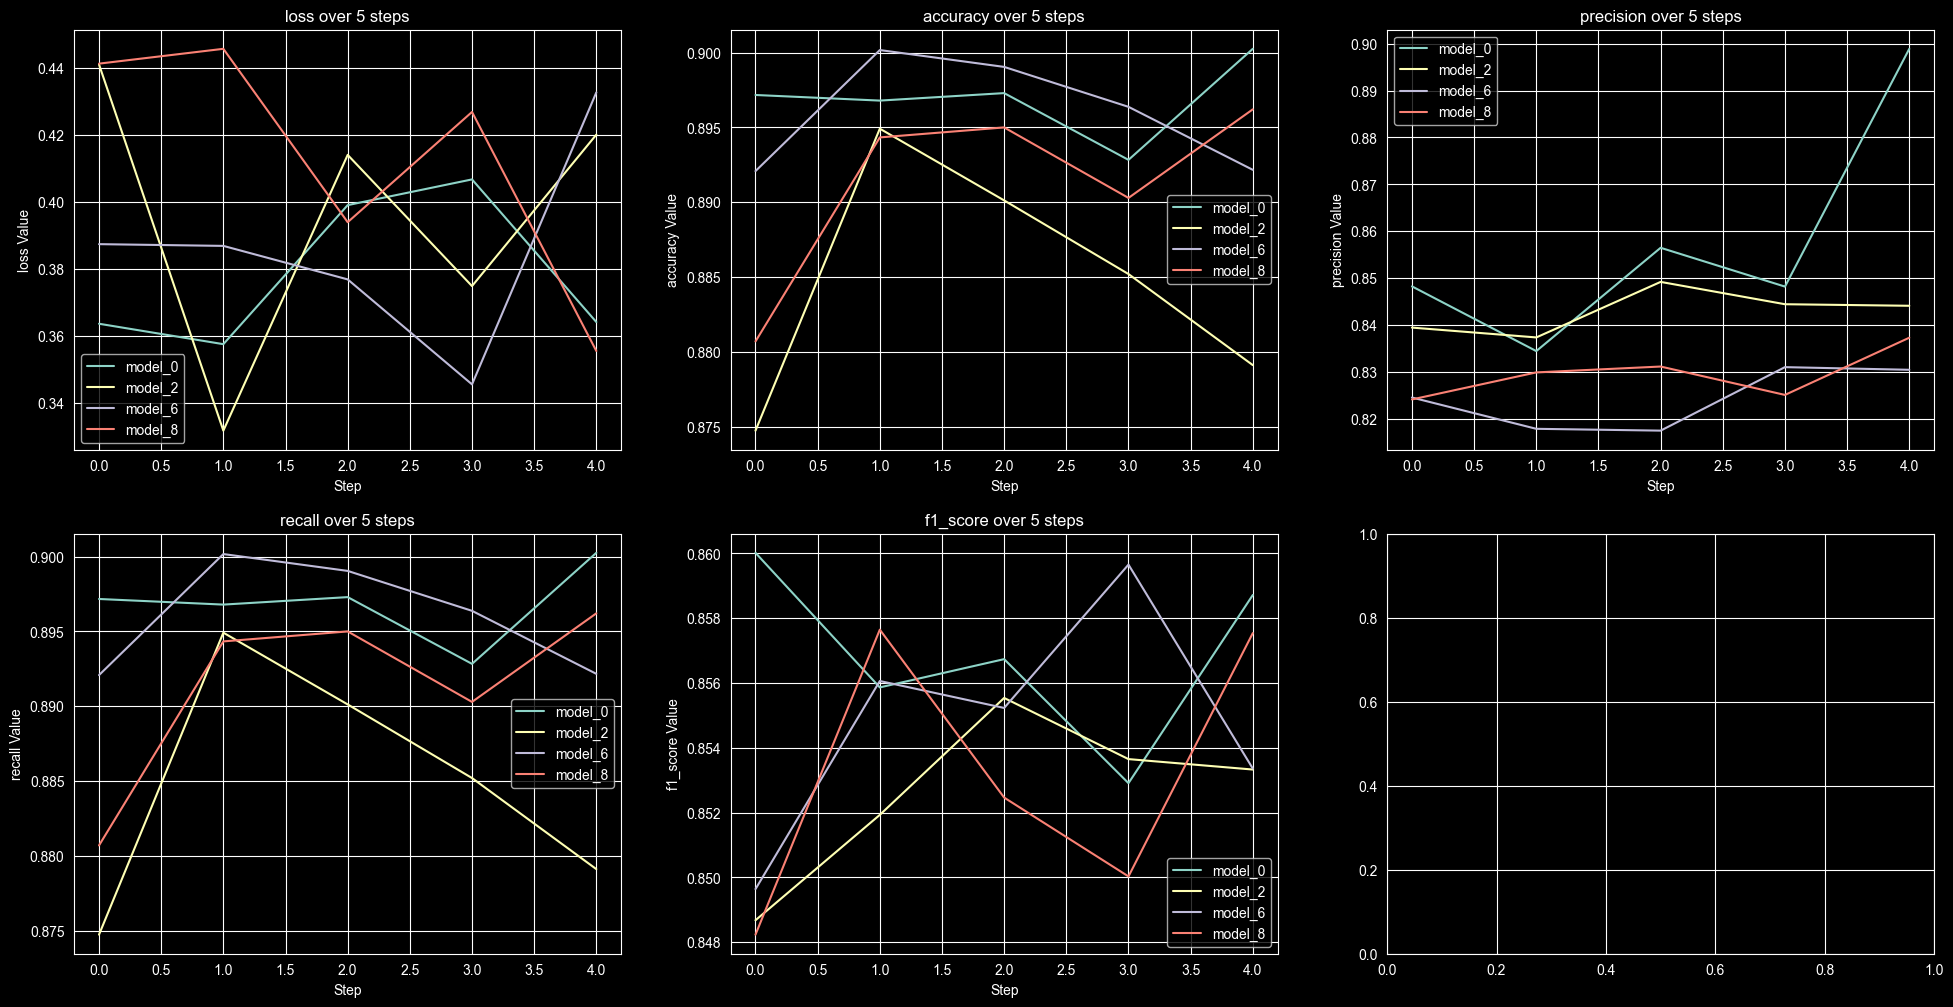

In [73]:
plot_histories("val", histories)

**Results**

Clearly without any form of model generalization techniques, the smaller models slightly outperform the bigger models, now let's see what happens when Batch normalization is introduced. Also let's see what happens when we extend the training period to 10 epochs.

In [74]:
print(best_models_norm)

{'model_0': (Model(
  (first_layer): _SimpleBlock(
    (linear1): Linear(in_features=37, out_features=32, bias=True)
    (linear2): Linear(in_features=32, out_features=32, bias=True)
    (activation1): ReLU()
    (activation2): ReLU()
  )
  (hidden): Sequential()
  (output_layer): Linear(in_features=32, out_features=6, bias=True)
), <__main__.ModelHistory object at 0x00000239BC1D7050>), 'model_2': (Model(
  (first_layer): _SimpleBlock(
    (linear1): Linear(in_features=37, out_features=128, bias=True)
    (linear2): Linear(in_features=128, out_features=128, bias=True)
    (activation1): ReLU()
    (activation2): ReLU()
  )
  (hidden): Sequential()
  (output_layer): Linear(in_features=128, out_features=6, bias=True)
), <__main__.ModelHistory object at 0x00000239BE7E3800>), 'model_6': (Model(
  (first_layer): _SimpleBlock(
    (linear1): Linear(in_features=37, out_features=32, bias=True)
    (linear2): Linear(in_features=32, out_features=32, bias=True)
    (activation1): ReLU()
    (acti

In [75]:
best_models_norm = train_many_models_deterministic([0, 1, 2], [32, 64, 128], [nn.ReLU], [-1], [1e-3], [1e-4], [torch.optim.Adam], is_skipping_conn=[False], is_batch_norm=[True], epochs=10, batch_sizes=[64], top_models=4, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

In [76]:
histories = gather_histories(best_models_norm)

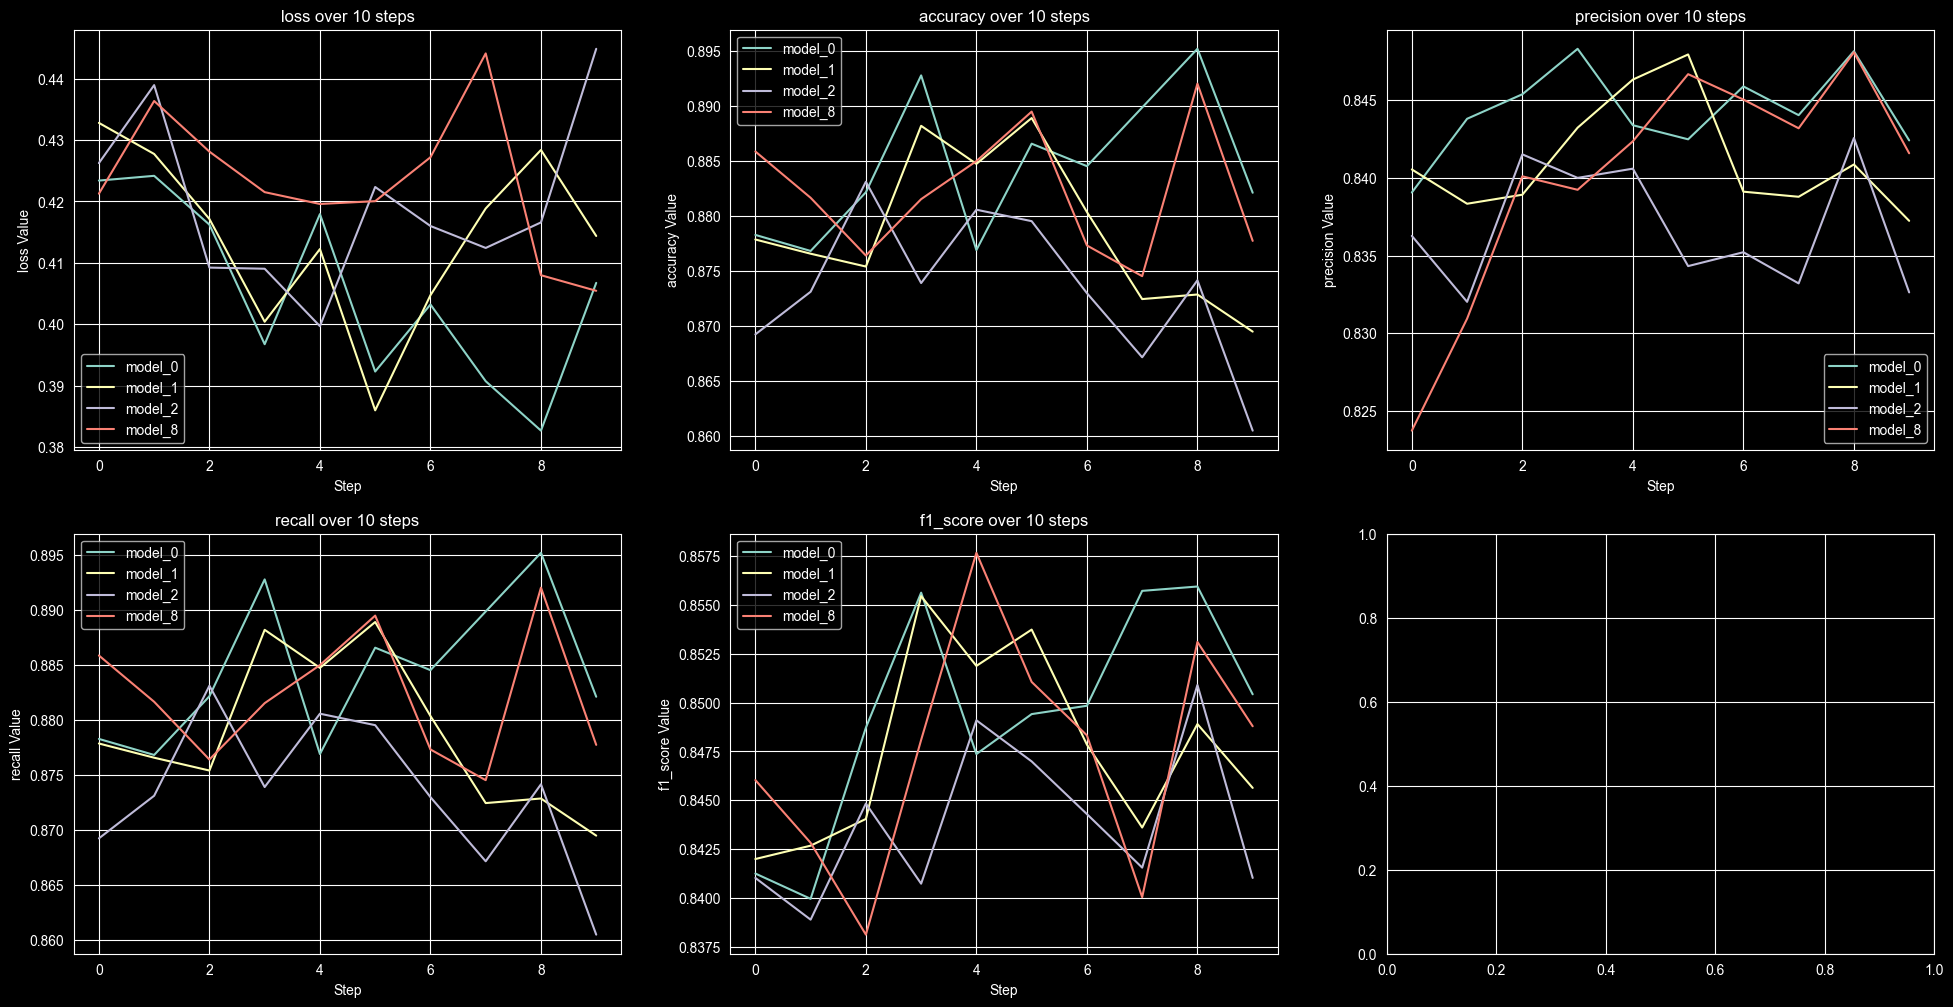

In [77]:
plot_histories("val", histories)

In [78]:
print(best_models_norm)


{'model_0': (Model(
  (first_layer): _SimpleBlock(
    (linear1): Linear(in_features=37, out_features=32, bias=True)
    (linear2): Linear(in_features=32, out_features=32, bias=True)
    (activation1): ReLU()
    (activation2): ReLU()
    (batch_norm1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (batch_norm2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (hidden): Sequential()
  (output_layer): Linear(in_features=32, out_features=6, bias=True)
), <__main__.ModelHistory object at 0x00000239BE82C920>), 'model_1': (Model(
  (first_layer): _SimpleBlock(
    (linear1): Linear(in_features=37, out_features=64, bias=True)
    (linear2): Linear(in_features=64, out_features=64, bias=True)
    (activation1): ReLU()
    (activation2): ReLU()
    (batch_norm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (batch_norm2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_

Extending the training time and adding batch normalization positively affected the models effectivness. It also introduced larger models being at the top - specifically the ones with 1 hidden layer.

Let's inspect how learning rate and weight decay affects the outcomes 

In [97]:
best_models = train_many_models_deterministic([2], [128], [nn.ReLU], [-1], [1e-3, 1e-4, 1e-2], [1e-4], [torch.optim.Adam], is_skipping_conn=[False], is_batch_norm=[True], epochs=10, batch_sizes=[64], top_models=4, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

In [98]:
histories = gather_histories(best_models)

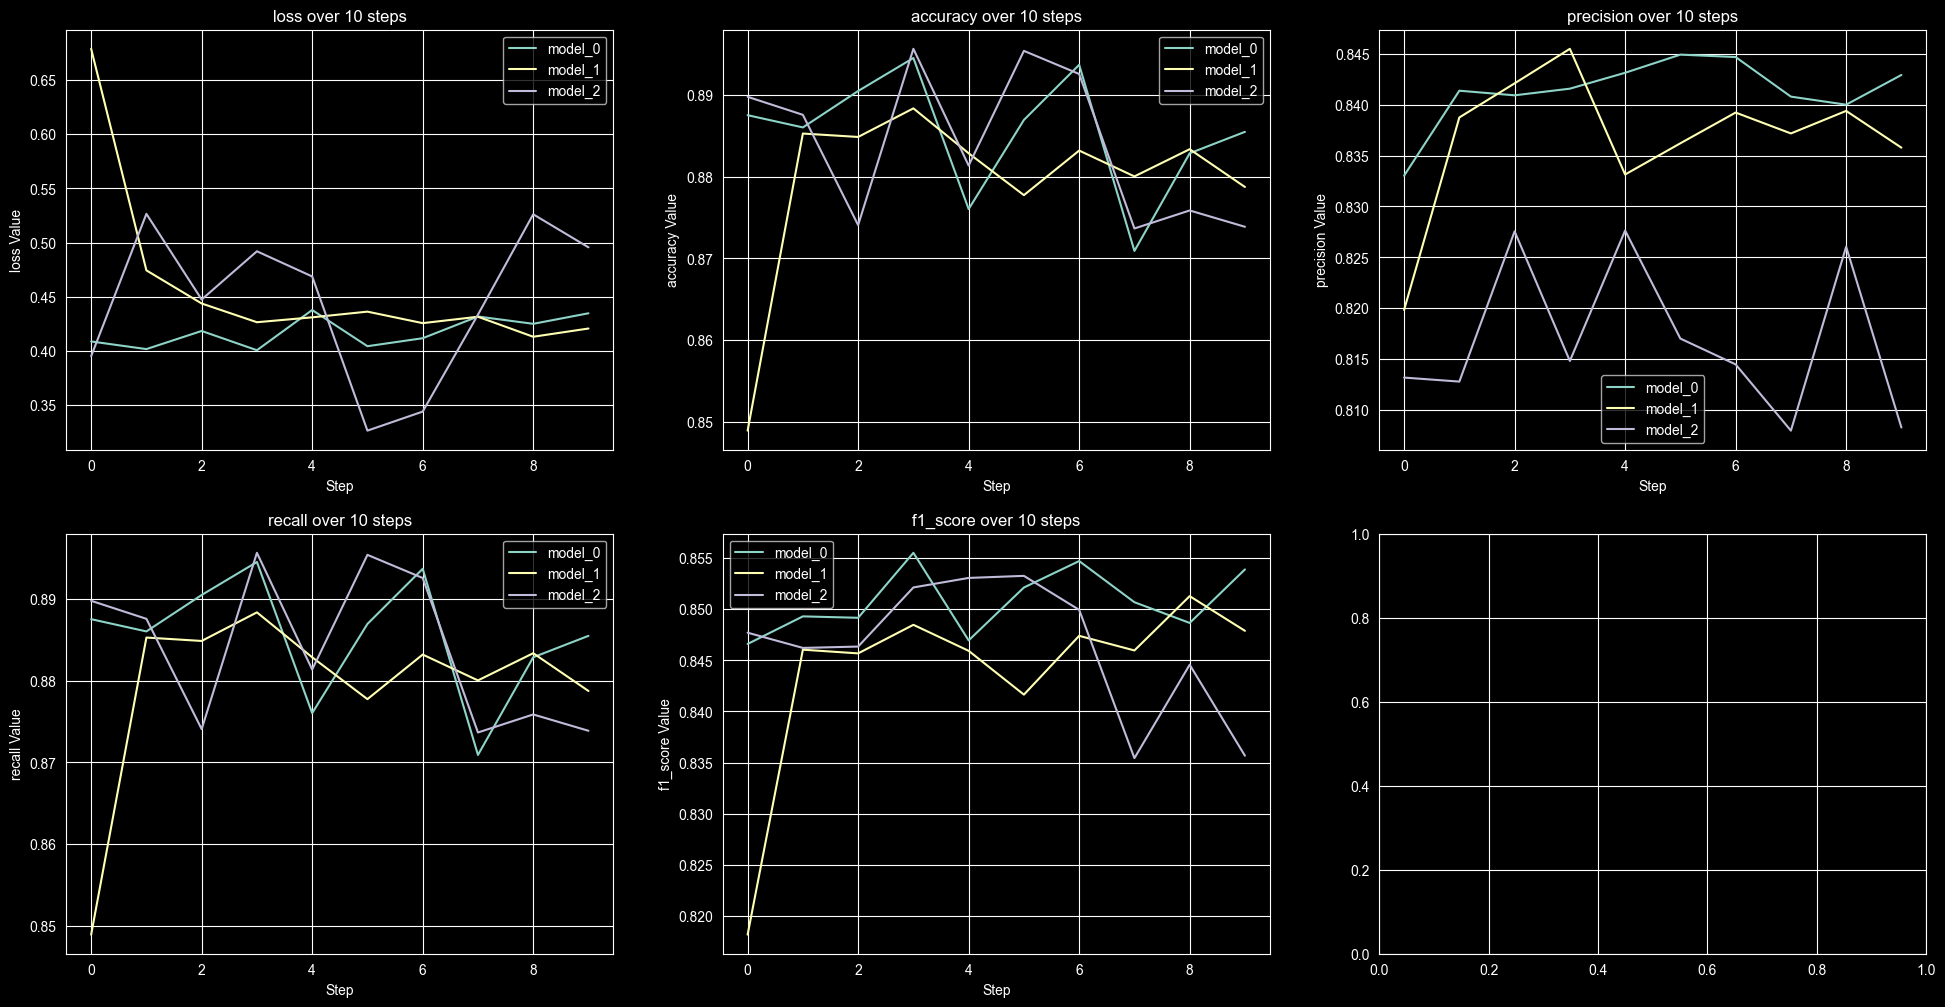

In [99]:
plot_histories("val", histories)

In [108]:
print([model[0].model_info for model in best_models.values()])

[{'model': {'neurons': 128, 'dropouts': [-1, -1, -1], 'is_batchnorm': [True, True, True], 'activations': ['ReLU', 'ReLU', 'ReLU'], 'is_skipping_conn': [False, False, False], 'input_shape': 37, 'output_shape': 6, 'name': 'model_0'}, 'train': {'epochs': 10, 'optimizer': 'Adam', 'criterion': 'CrossEntropyLoss', 'batch_size': 64, 'learning_rate': 0.001, 'lr_decay': 0.0001}}, {'model': {'neurons': 128, 'dropouts': [-1, -1, -1], 'is_batchnorm': [True, True, True], 'activations': ['ReLU', 'ReLU', 'ReLU'], 'is_skipping_conn': [False, False, False], 'input_shape': 37, 'output_shape': 6, 'name': 'model_1'}, 'train': {'epochs': 10, 'optimizer': 'Adam', 'criterion': 'CrossEntropyLoss', 'batch_size': 64, 'learning_rate': 0.0001, 'lr_decay': 0.0001}}, {'model': {'neurons': 128, 'dropouts': [-1, -1, -1], 'is_batchnorm': [True, True, True], 'activations': ['ReLU', 'ReLU', 'ReLU'], 'is_skipping_conn': [False, False, False], 'input_shape': 37, 'output_shape': 6, 'name': 'model_2'}, 'train': {'epochs': 1

We can see here that the learning rate set to $1e-2$ produces worse model, while $1e-3$ and $1e-4$ seems to be just right, now it is time for testing the weight decay


In [109]:
best_models = train_many_models_deterministic([2], [128], [nn.ReLU], [-1], [1e-4], [1e-4, 1e-5, 1e-6, 1e-3], [torch.optim.Adam], is_skipping_conn=[False], is_batch_norm=[True], epochs=10, batch_sizes=[64], top_models=4, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

In [111]:
histories = gather_histories(best_models)

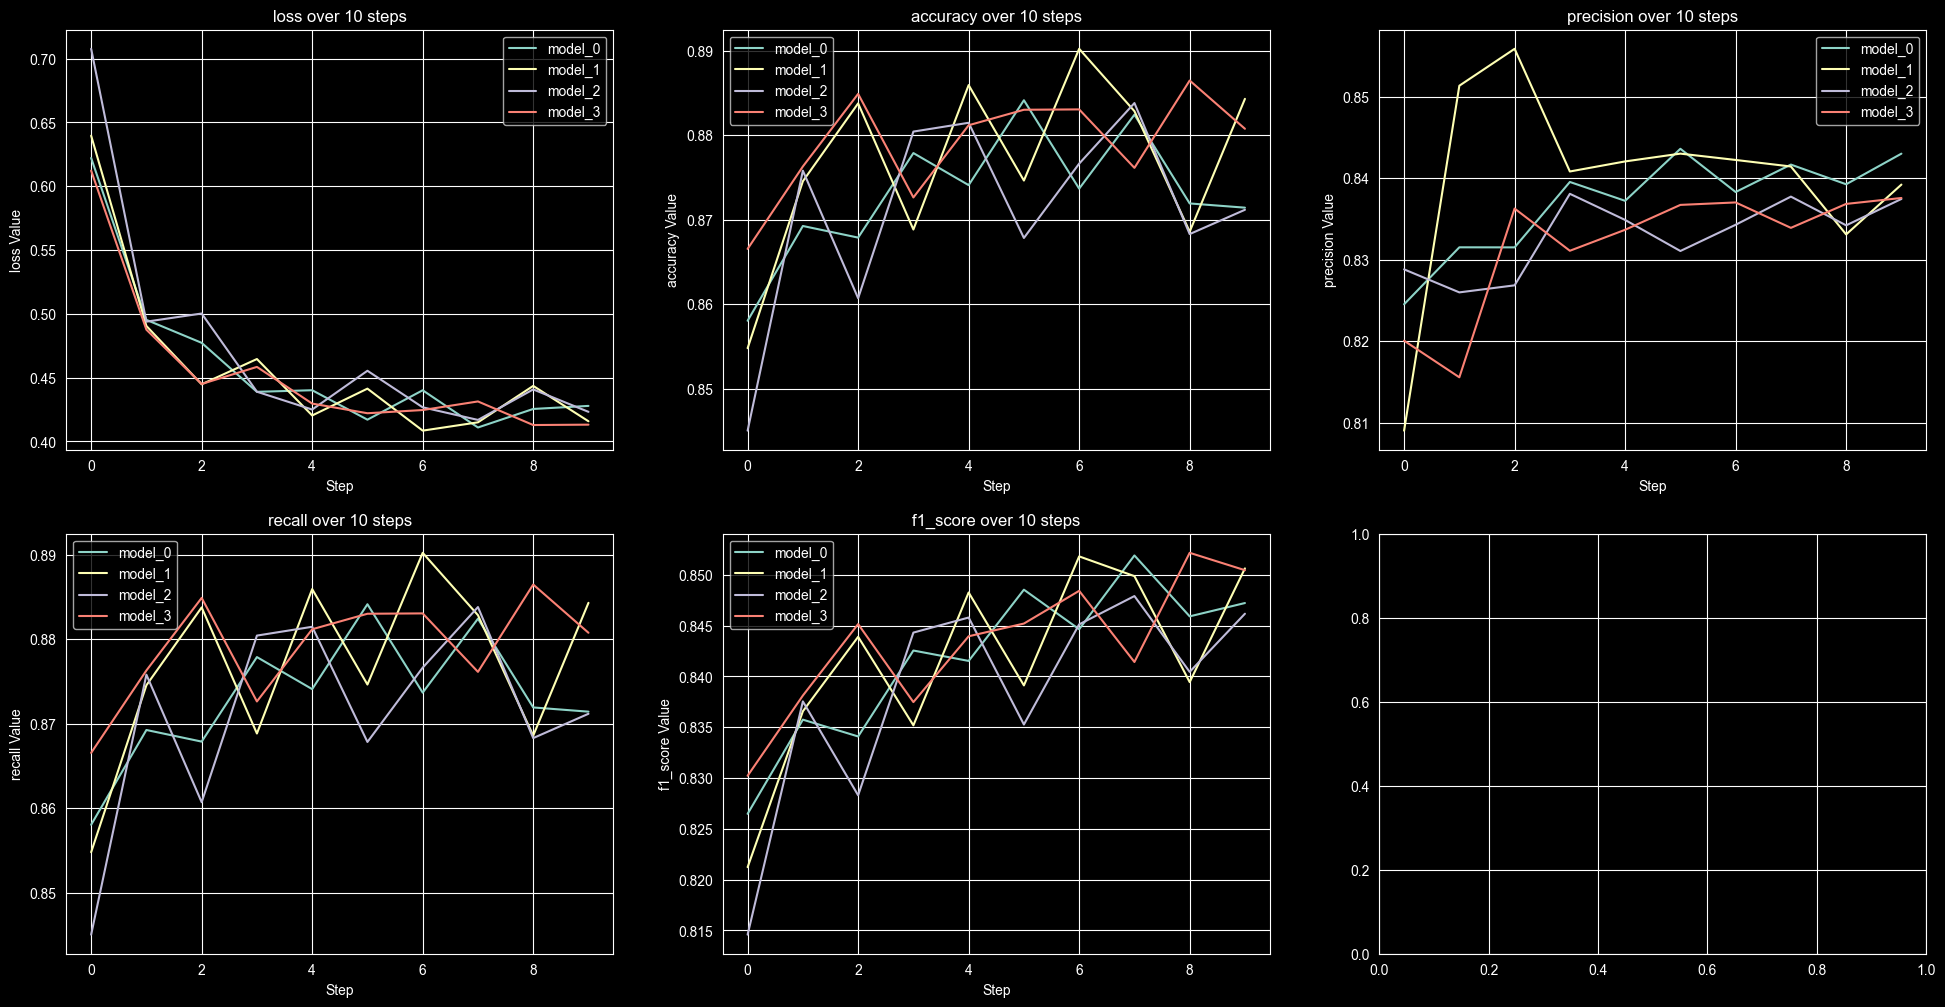

In [112]:
plot_histories("val", histories)


In [113]:
models_info = [model[0].model_info for model in best_models.values()]
pprint(models_info, indent=4, sort_dicts=False)

[   {   'model': {   'neurons': 128,
                     'dropouts': [-1, -1, -1],
                     'is_batchnorm': [True, True, True],
                     'activations': ['ReLU', 'ReLU', 'ReLU'],
                     'is_skipping_conn': [False, False, False],
                     'input_shape': 37,
                     'output_shape': 6,
                     'name': 'model_0'},
        'train': {   'epochs': 10,
                     'optimizer': 'Adam',
                     'criterion': 'CrossEntropyLoss',
                     'batch_size': 64,
                     'learning_rate': 0.0001,
                     'lr_decay': 0.0001}},
    {   'model': {   'neurons': 128,
                     'dropouts': [-1, -1, -1],
                     'is_batchnorm': [True, True, True],
                     'activations': ['ReLU', 'ReLU', 'ReLU'],
                     'is_skipping_conn': [False, False, False],
                     'input_shape': 37,
                     'output_shape': 6,
      

The weight_decay seems to have little to no effect on the models

Now onto the **exciting** part. <br>
Let's perform testing the classes weights and how they affect the models predictions, I'm testing this on the previous models with different layers and neurons, but without batch norm.

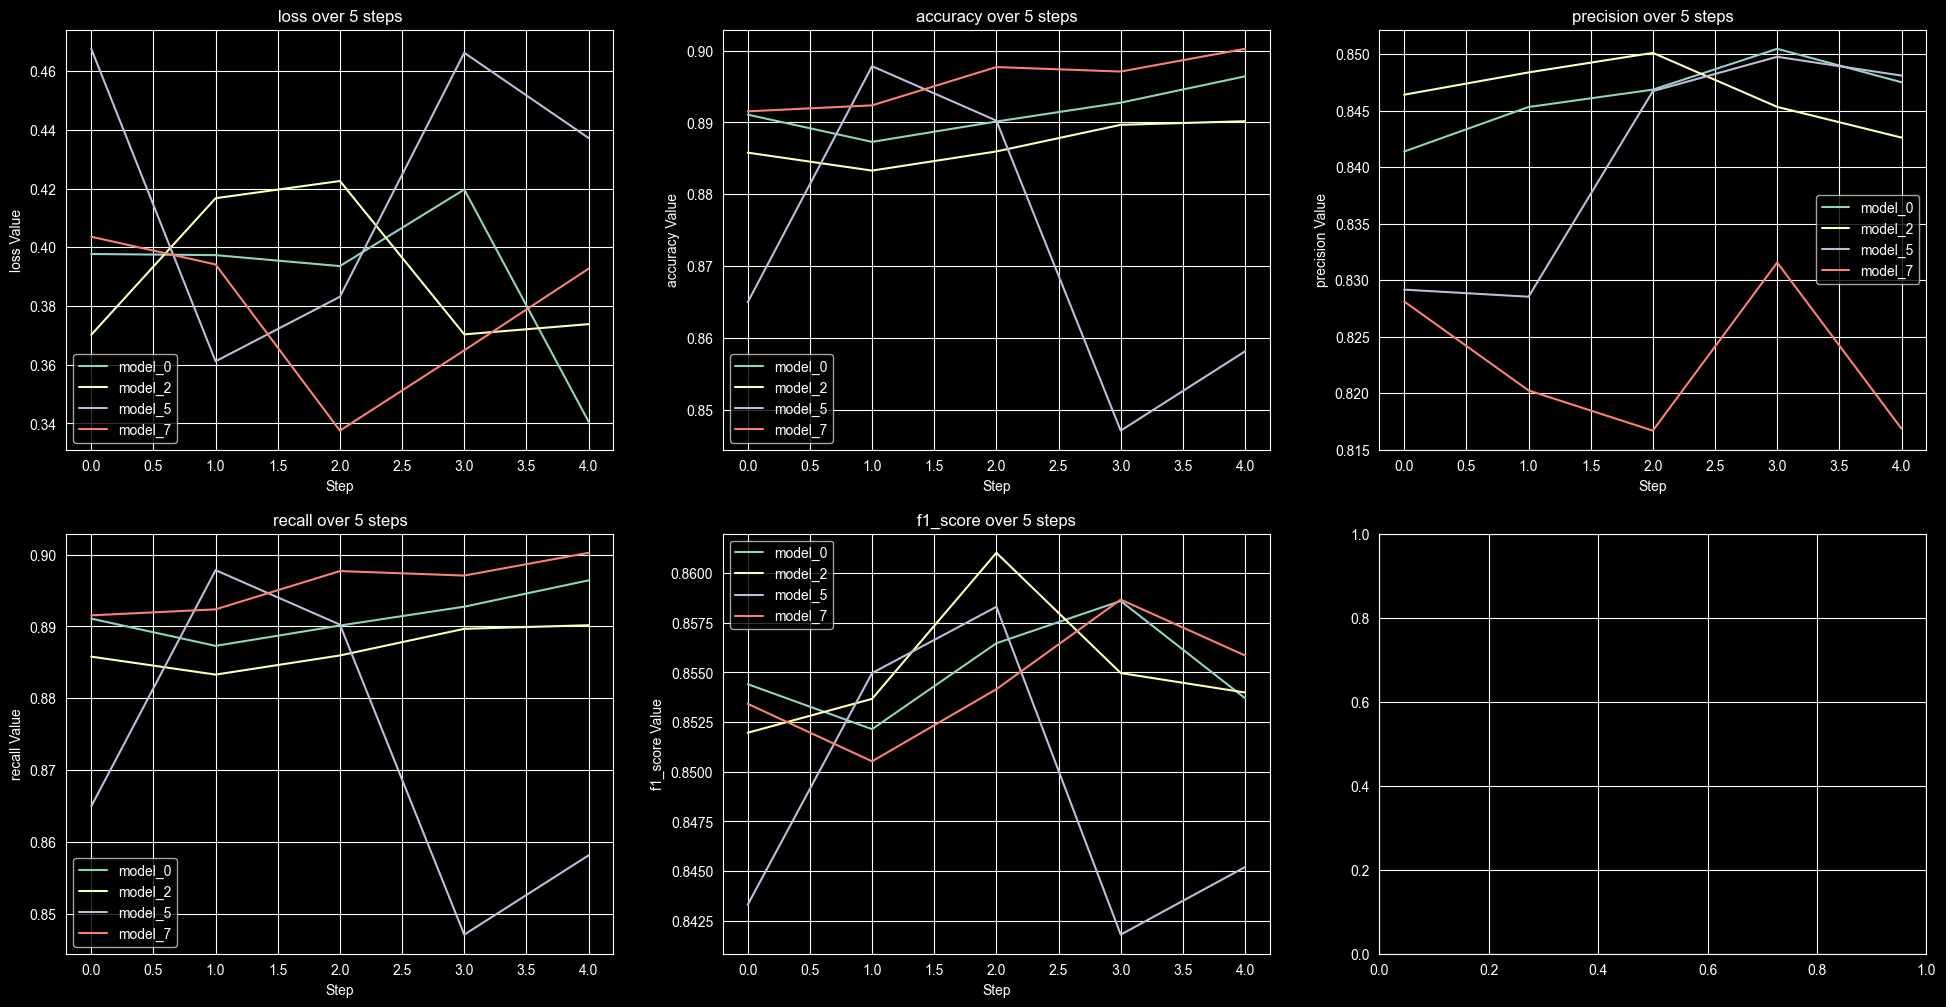

In [79]:
best_models_norm = train_many_models_deterministic([0, 1, 2], [32, 64, 128], [nn.ReLU], [-1], [1e-3], [1e-4], [torch.optim.Adam], is_skipping_conn=[False], is_batch_norm=[False], epochs=5, batch_sizes=[64], top_models=4, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

plot_histories("val", gather_histories(best_models_norm))

# save_best_models_info(best_models_norm)


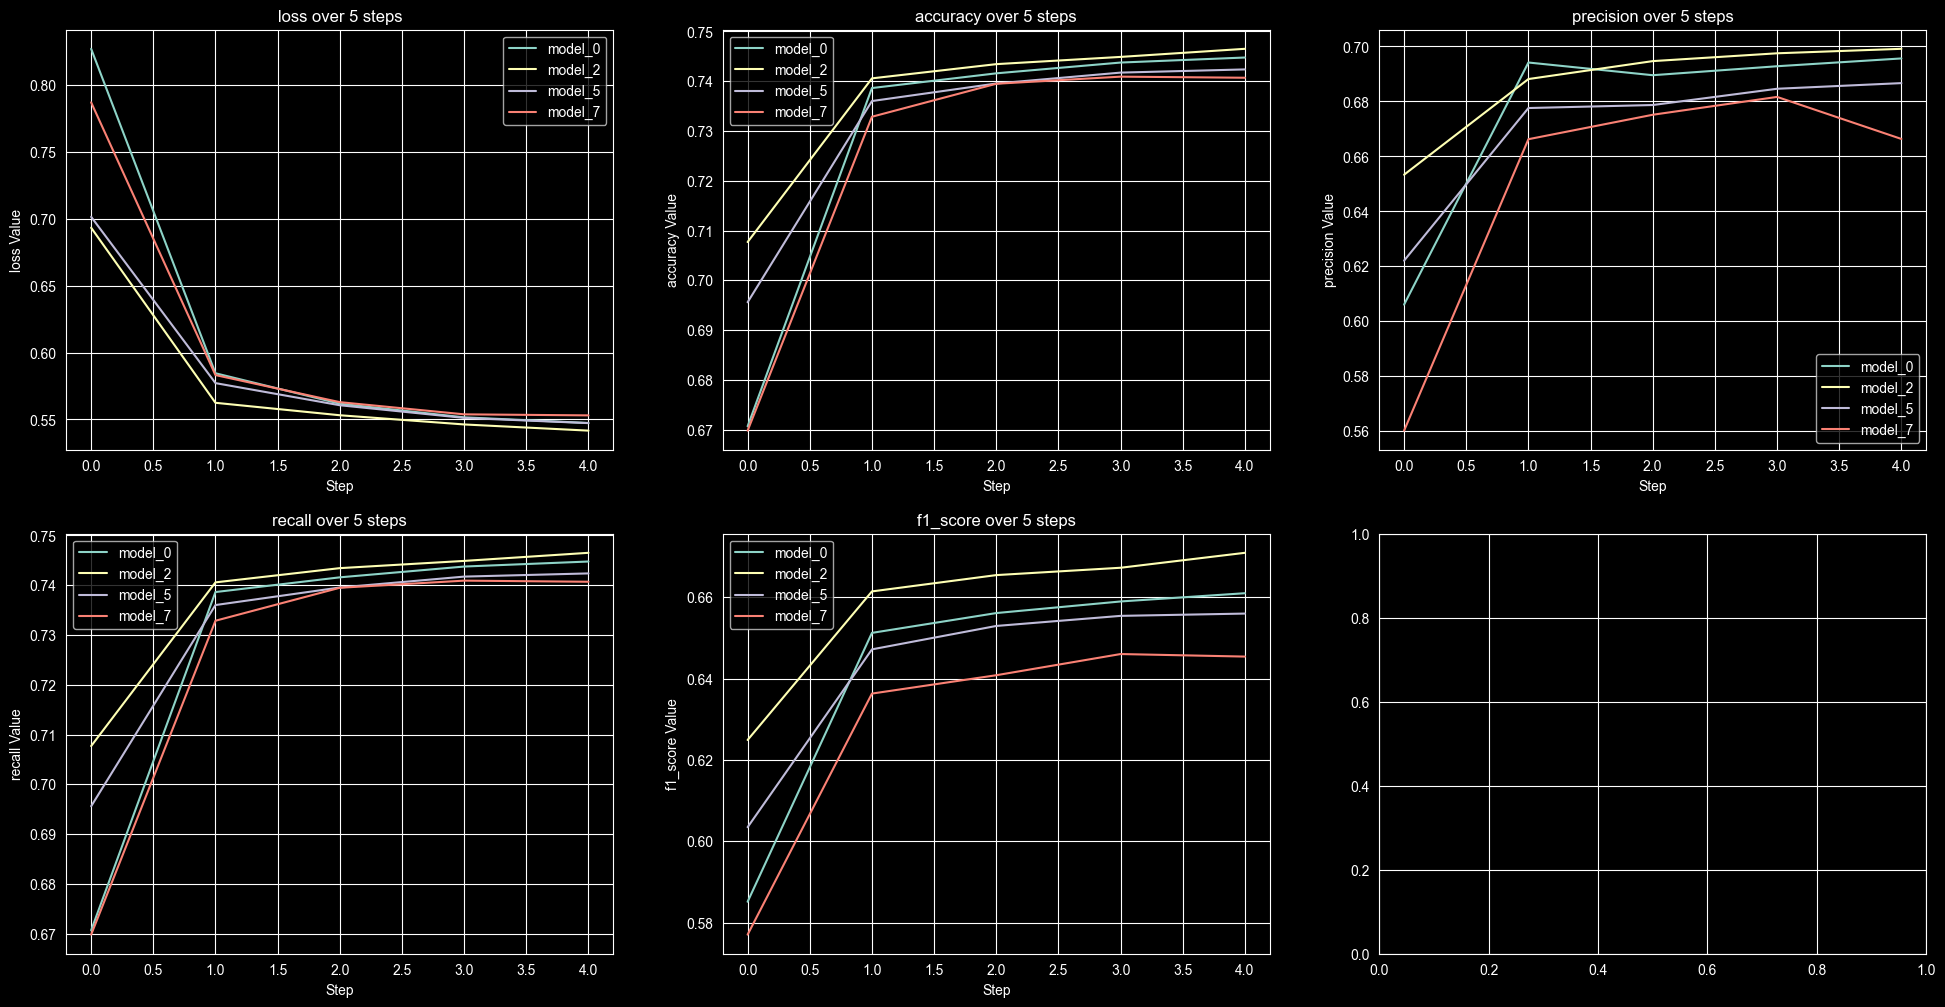

In [80]:
plot_histories("train", gather_histories(best_models_norm))


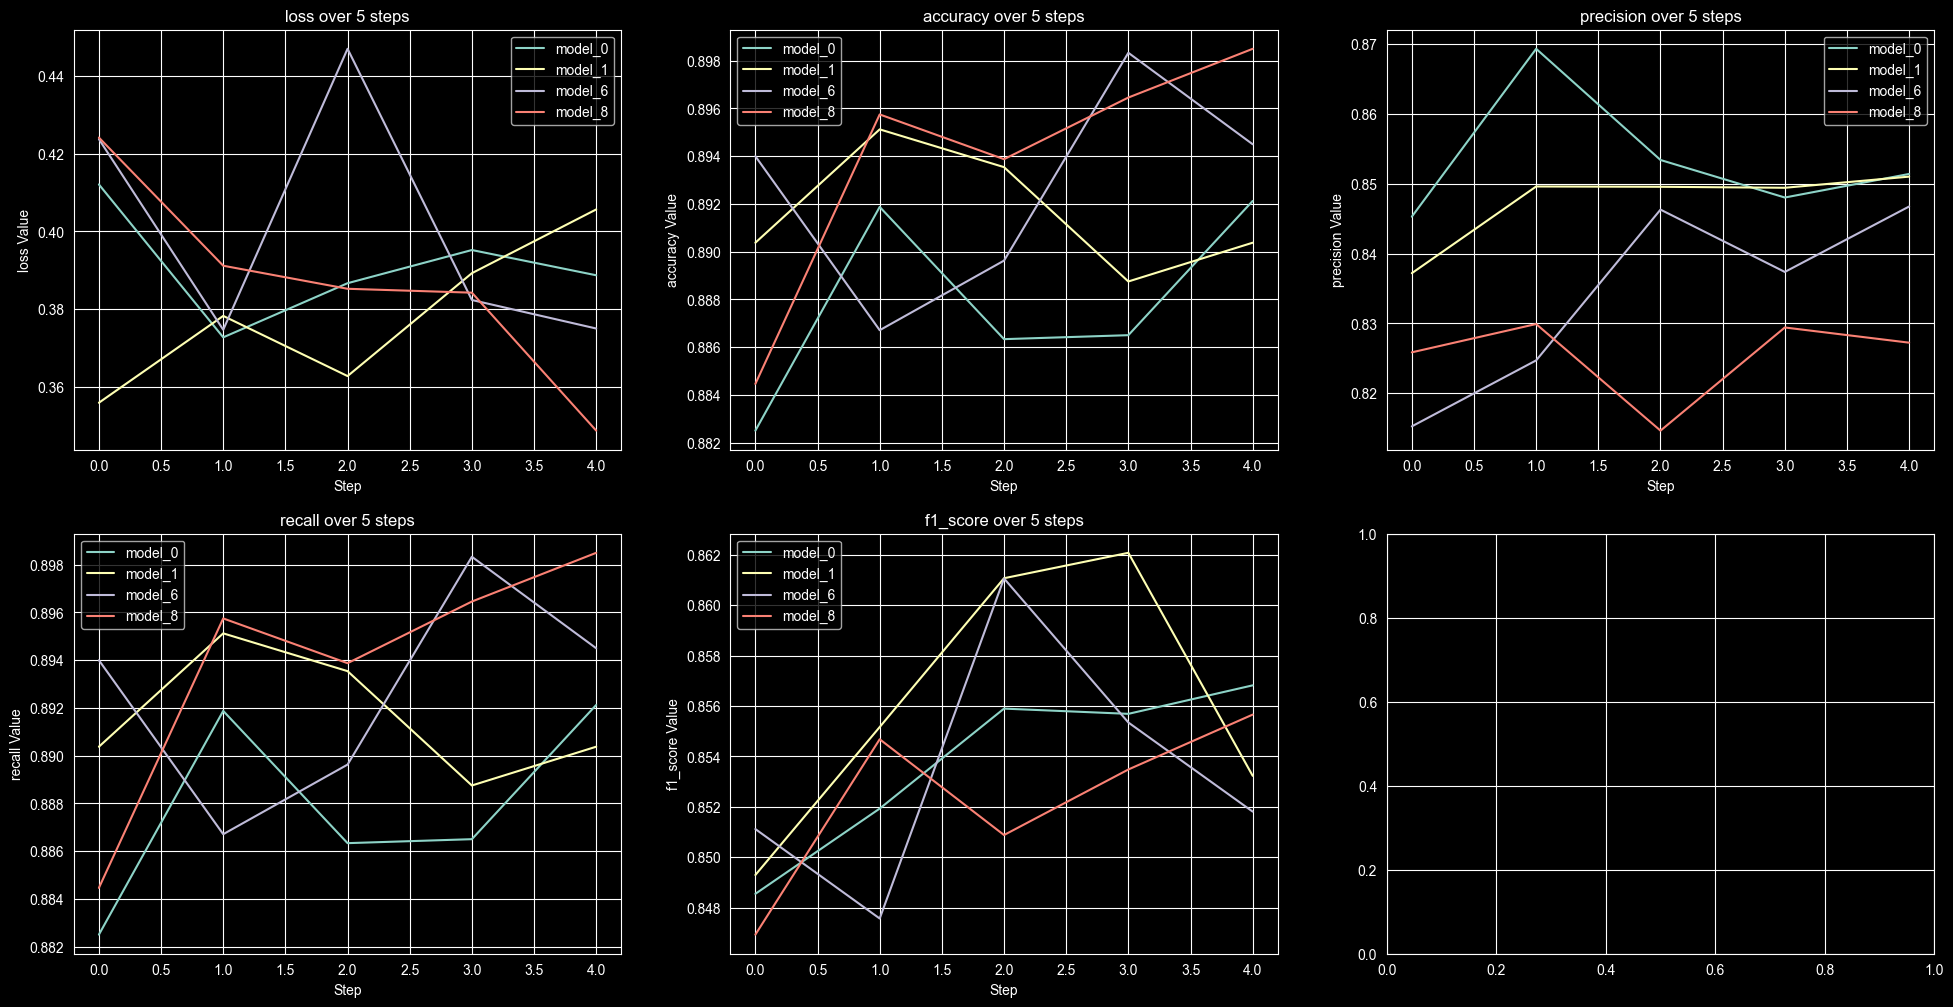

In [81]:
best_models_normal_weights = train_many_models_deterministic([0, 1, 2], [32, 64, 128], [nn.ReLU], [-1], [1e-3], [1e-4], [torch.optim.Adam], is_skipping_conn=[False], is_batch_norm=[False], epochs=5, batch_sizes=[64], top_models=4, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
}, add_weights_to_classes="norm")

plot_histories("val", gather_histories(best_models_normal_weights))

# save_best_models_info(best_models_norm)

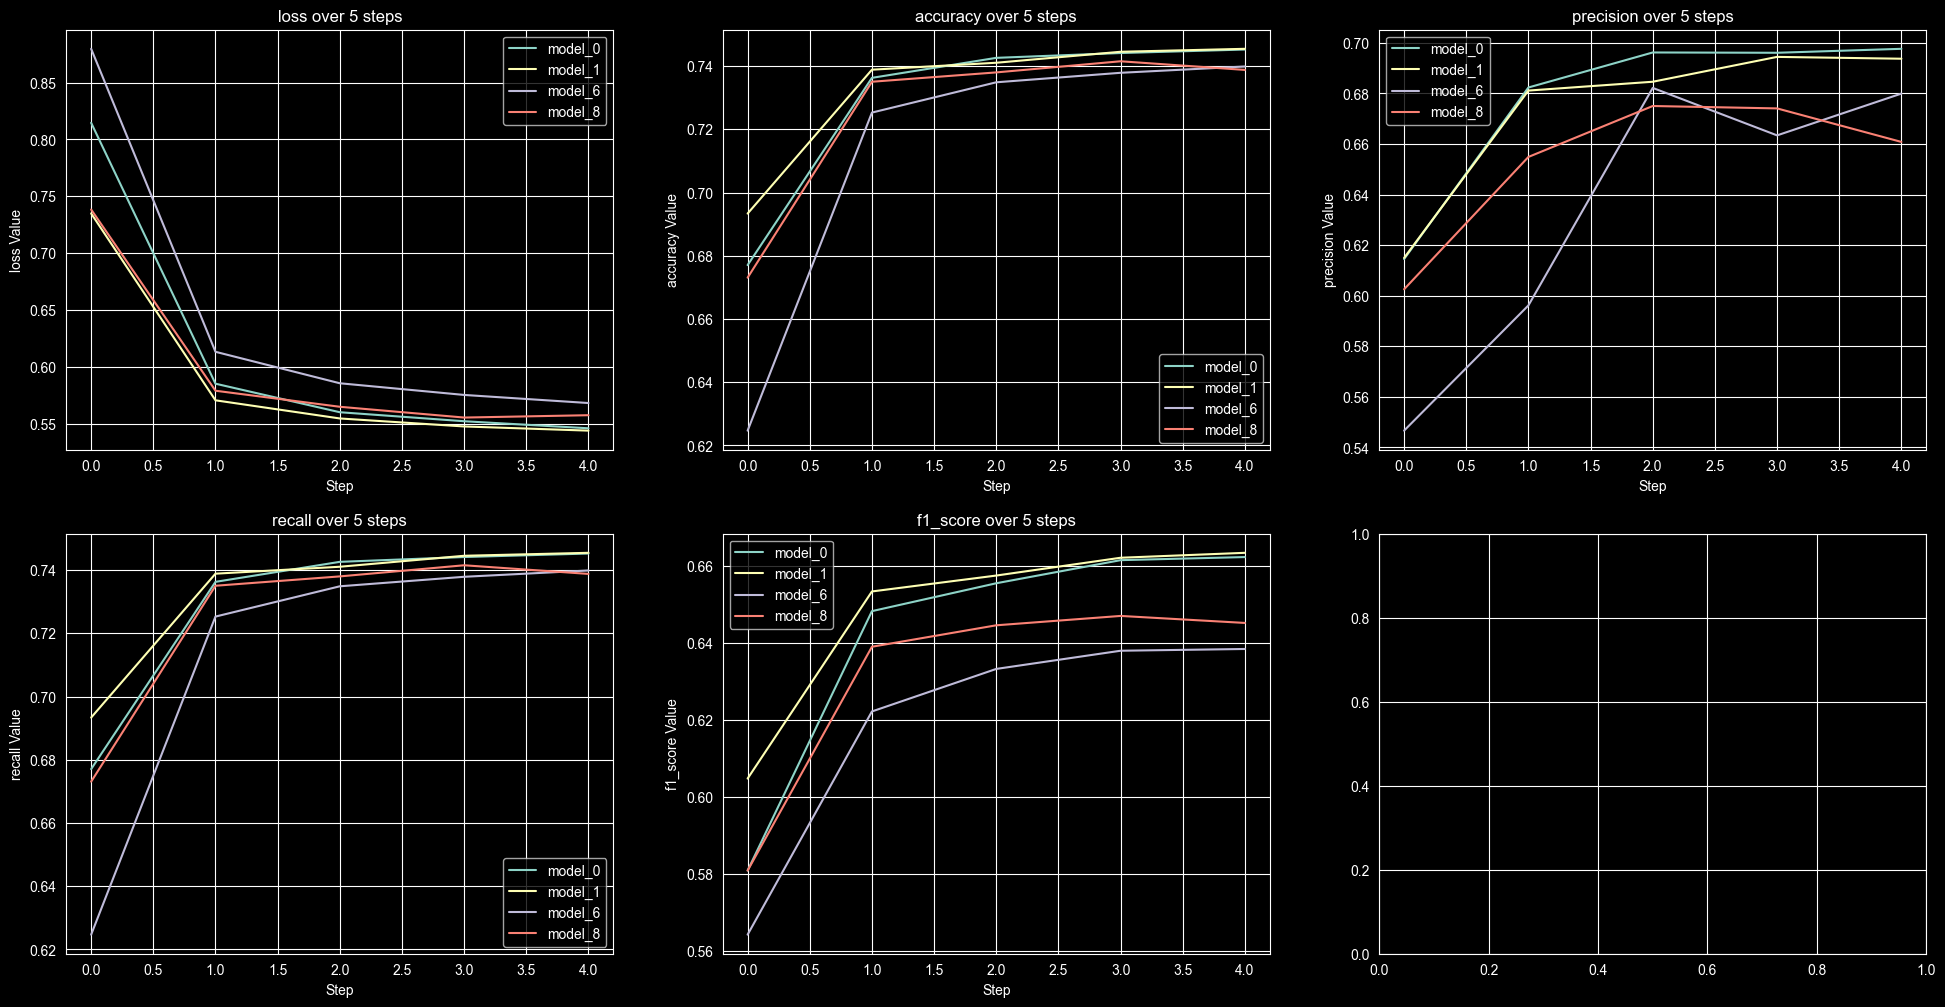

In [82]:
plot_histories("train", gather_histories(best_models_normal_weights))


[2.90842884 2.90842884 0.58168577 1.0404679  0.87932573 1.30068892] [  800   800 20000  6251  8752  4000]


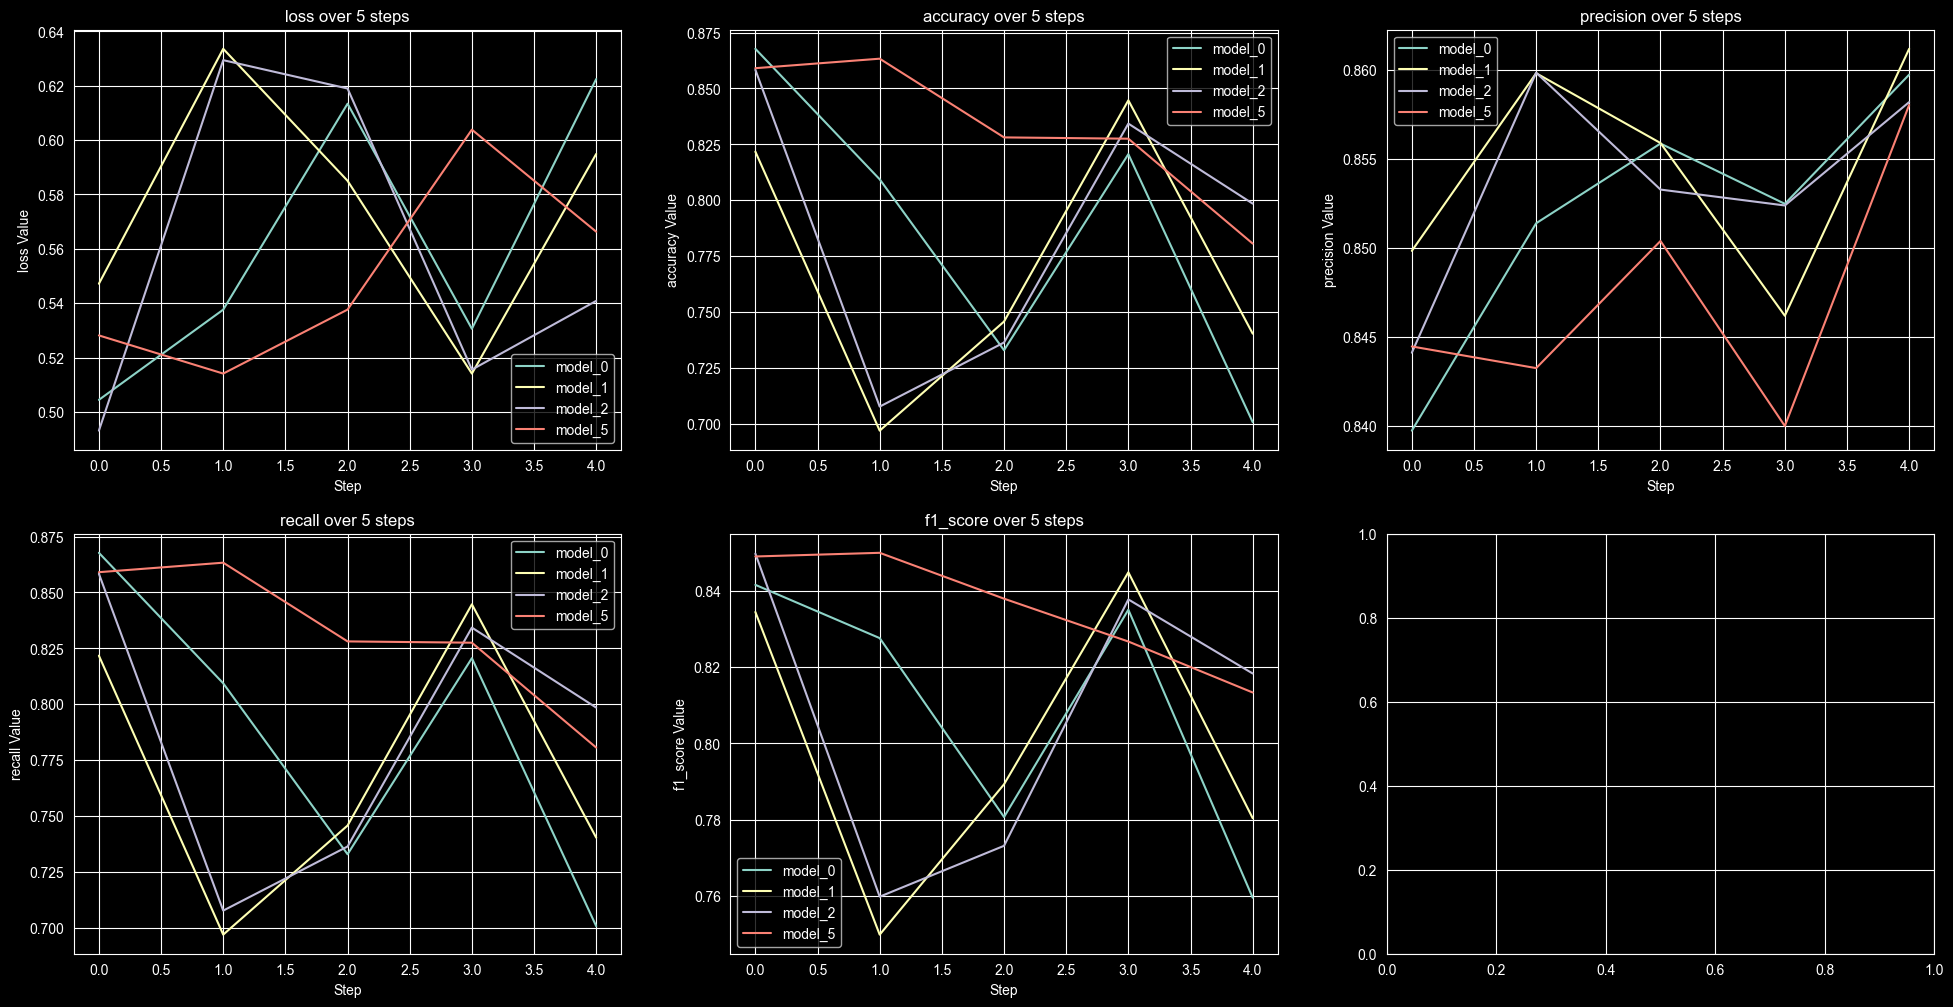

In [83]:
best_models_sqrt_weights = train_many_models_deterministic([0, 1, 2], [32, 64, 128], [nn.ReLU], [-1], [1e-3], [1e-4], [torch.optim.Adam], is_skipping_conn=[False], is_batch_norm=[False], epochs=5, batch_sizes=[64], top_models=4, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
}, add_weights_to_classes="sqrt")

plot_histories("val", gather_histories(best_models_sqrt_weights))

# save_best_models_info(best_models_norm)

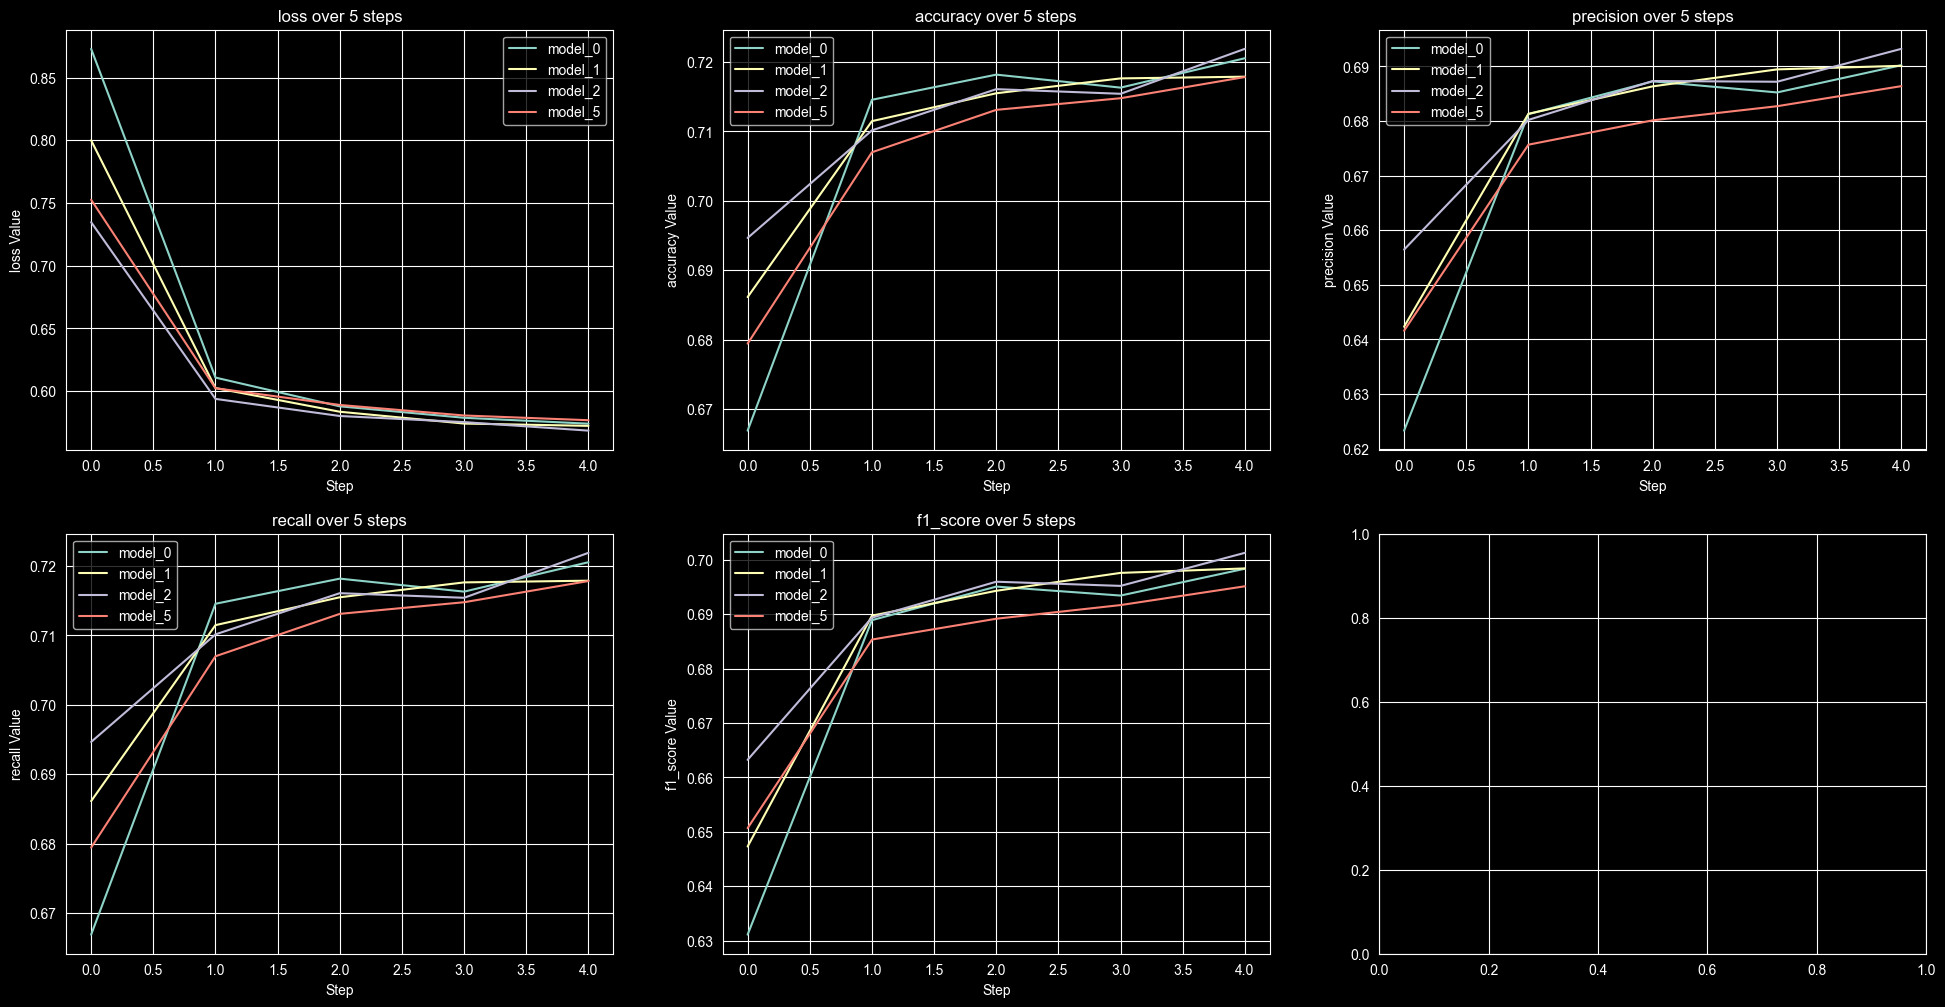

In [84]:
plot_histories("train", gather_histories(best_models_sqrt_weights))


Here I'm taking the class names to use them as labels in the next plot functions

In [18]:
class_names = dict()
with open(ROOT_PATH / "data" / "classes_info.json", 'r') as f:
     class_names = json.load(f)

class_names = [v for k, v in class_names.items()]

The `generate_heatmap` function takes the `y_true` and `y_pred` to generate the confusion matrix on the test set by a model

In [19]:
def generate_heatmap(y_true, y_pred, ax: plt.Axes | None = None, title: str = "default title", class_names: list[str]| None = None):
    conf_matrix = confusion_matrix(y_true, y_pred, normalize="true")

    if class_names is None:
        class_names = np.arange(len(conf_matrix))

    if ax is None:
        plt.figure()
        ax = plt.gca()

    sns.heatmap(conf_matrix, ax=ax, cmap="Blues", annot=True, fmt=".2f")
    ax.set_title(title)
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


The `plot_best_heatmaps` uses the above function to create confusion matrices for each of the model in the given list

In [20]:
def plot_best_heatmaps(models: list[Model], data, criterion, device, max_img_per_width: int = 3, class_names: list[str] | None = None):
    import math
    h = math.ceil(len(models) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for i, model in enumerate(models):
        x, y = i//max_img_per_width, i%max_img_per_width
        _, y_pred, y_true = test_model(model, data, criterion, device)
        generate_heatmap(y_true, y_pred, ax=axs[x, y], title=f"Confusion matrix for model {model.name}", class_names = class_names)

    plt.tight_layout()


The `plot_test_metrics` takes the `y_true` and `y_pred` to generate the bar plots for a model with `precision`, `recall` and `f1_score` for each class. On top of that this plot also shows the `global accuracy` of the model.<br>
The most important classes are these that have a few samples in the original dataset.

In [21]:
def plot_test_metrics(y_true, y_pred, ax: plt.Axes, title:str, class_names=None):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    title += f" Global accuracy: {acc:.2%}"
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(p))]

    x = np.arange(len(class_names))
    width = 0.25

    ax.bar(x - width, p, width, label='Precision')
    ax.bar(x, r, width, label='Recall')
    ax.bar(x + width, f, width, label='F1-Score')

    ax.set_ylabel('Score (0.0 - 1.0)')
    ax.set_title(title, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right')


The `plot_best_basic_scores` uses the above function to creat plot for every model

In [22]:
def plot_best_basic_scores(models: list[Model], data, criterion, device, max_img_per_width: int = 3, class_names: list[str] = None):
    import math
    h = math.ceil(len(models) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for i, model in enumerate(models):
        x, y = i//max_img_per_width, i%max_img_per_width
        _, y_pred, y_true = test_model(model, data, criterion, device)
        plot_test_metrics(y_true, y_pred, ax=axs[x, y], title=f"Basic metrics for the model: {model.name}", class_names=class_names)
    plt.tight_layout()

In [23]:
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=False)

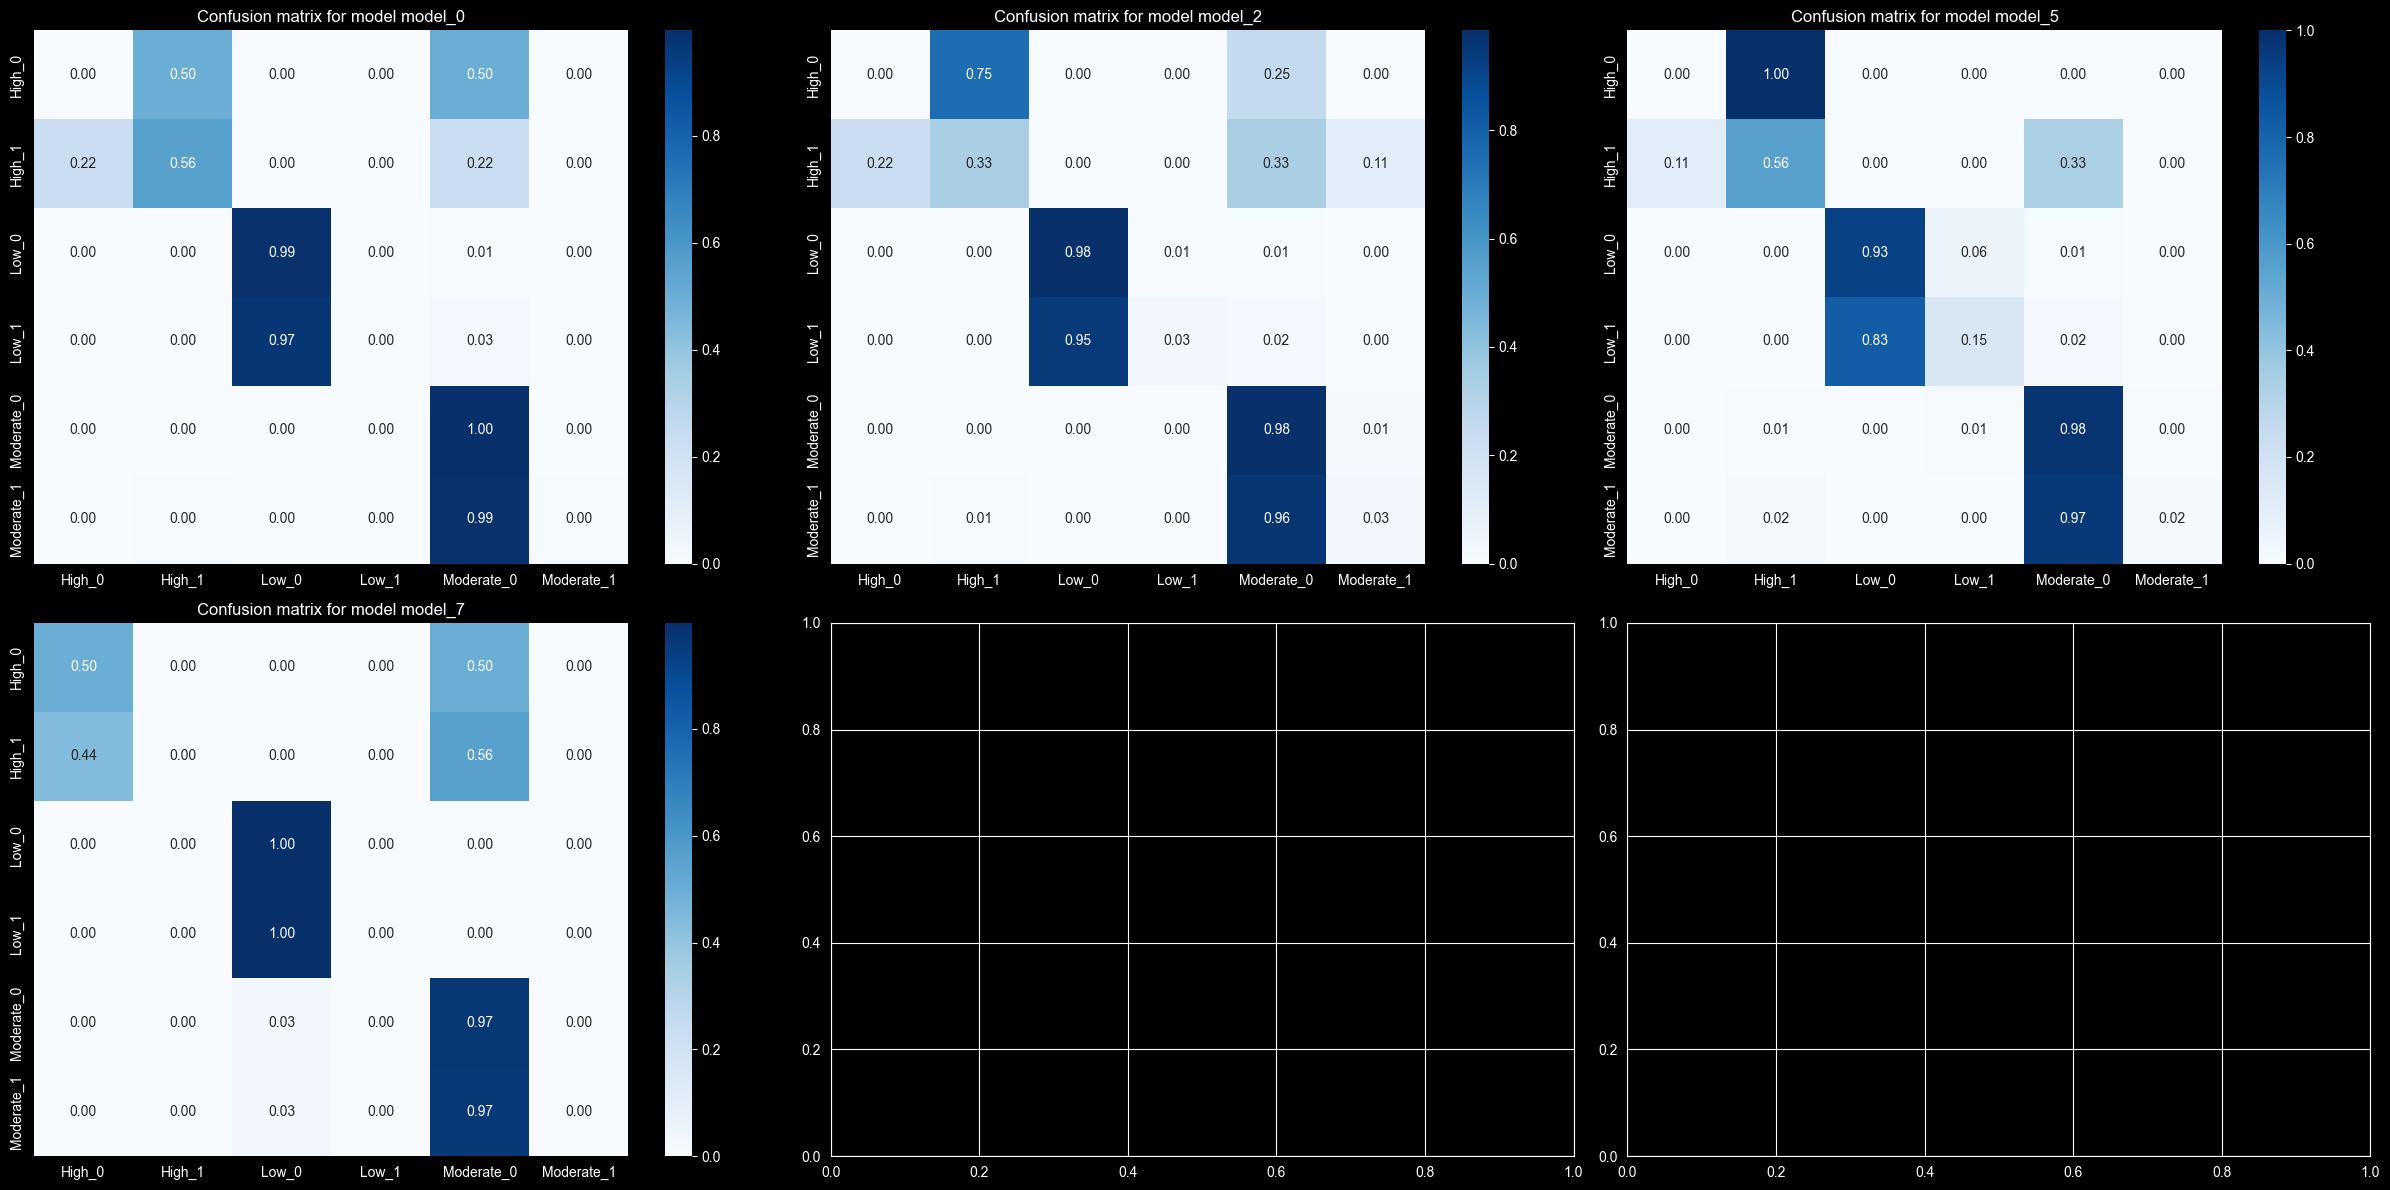

In [91]:
models_list = [model for model, _ in best_models_norm.values()]
plot_best_heatmaps(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

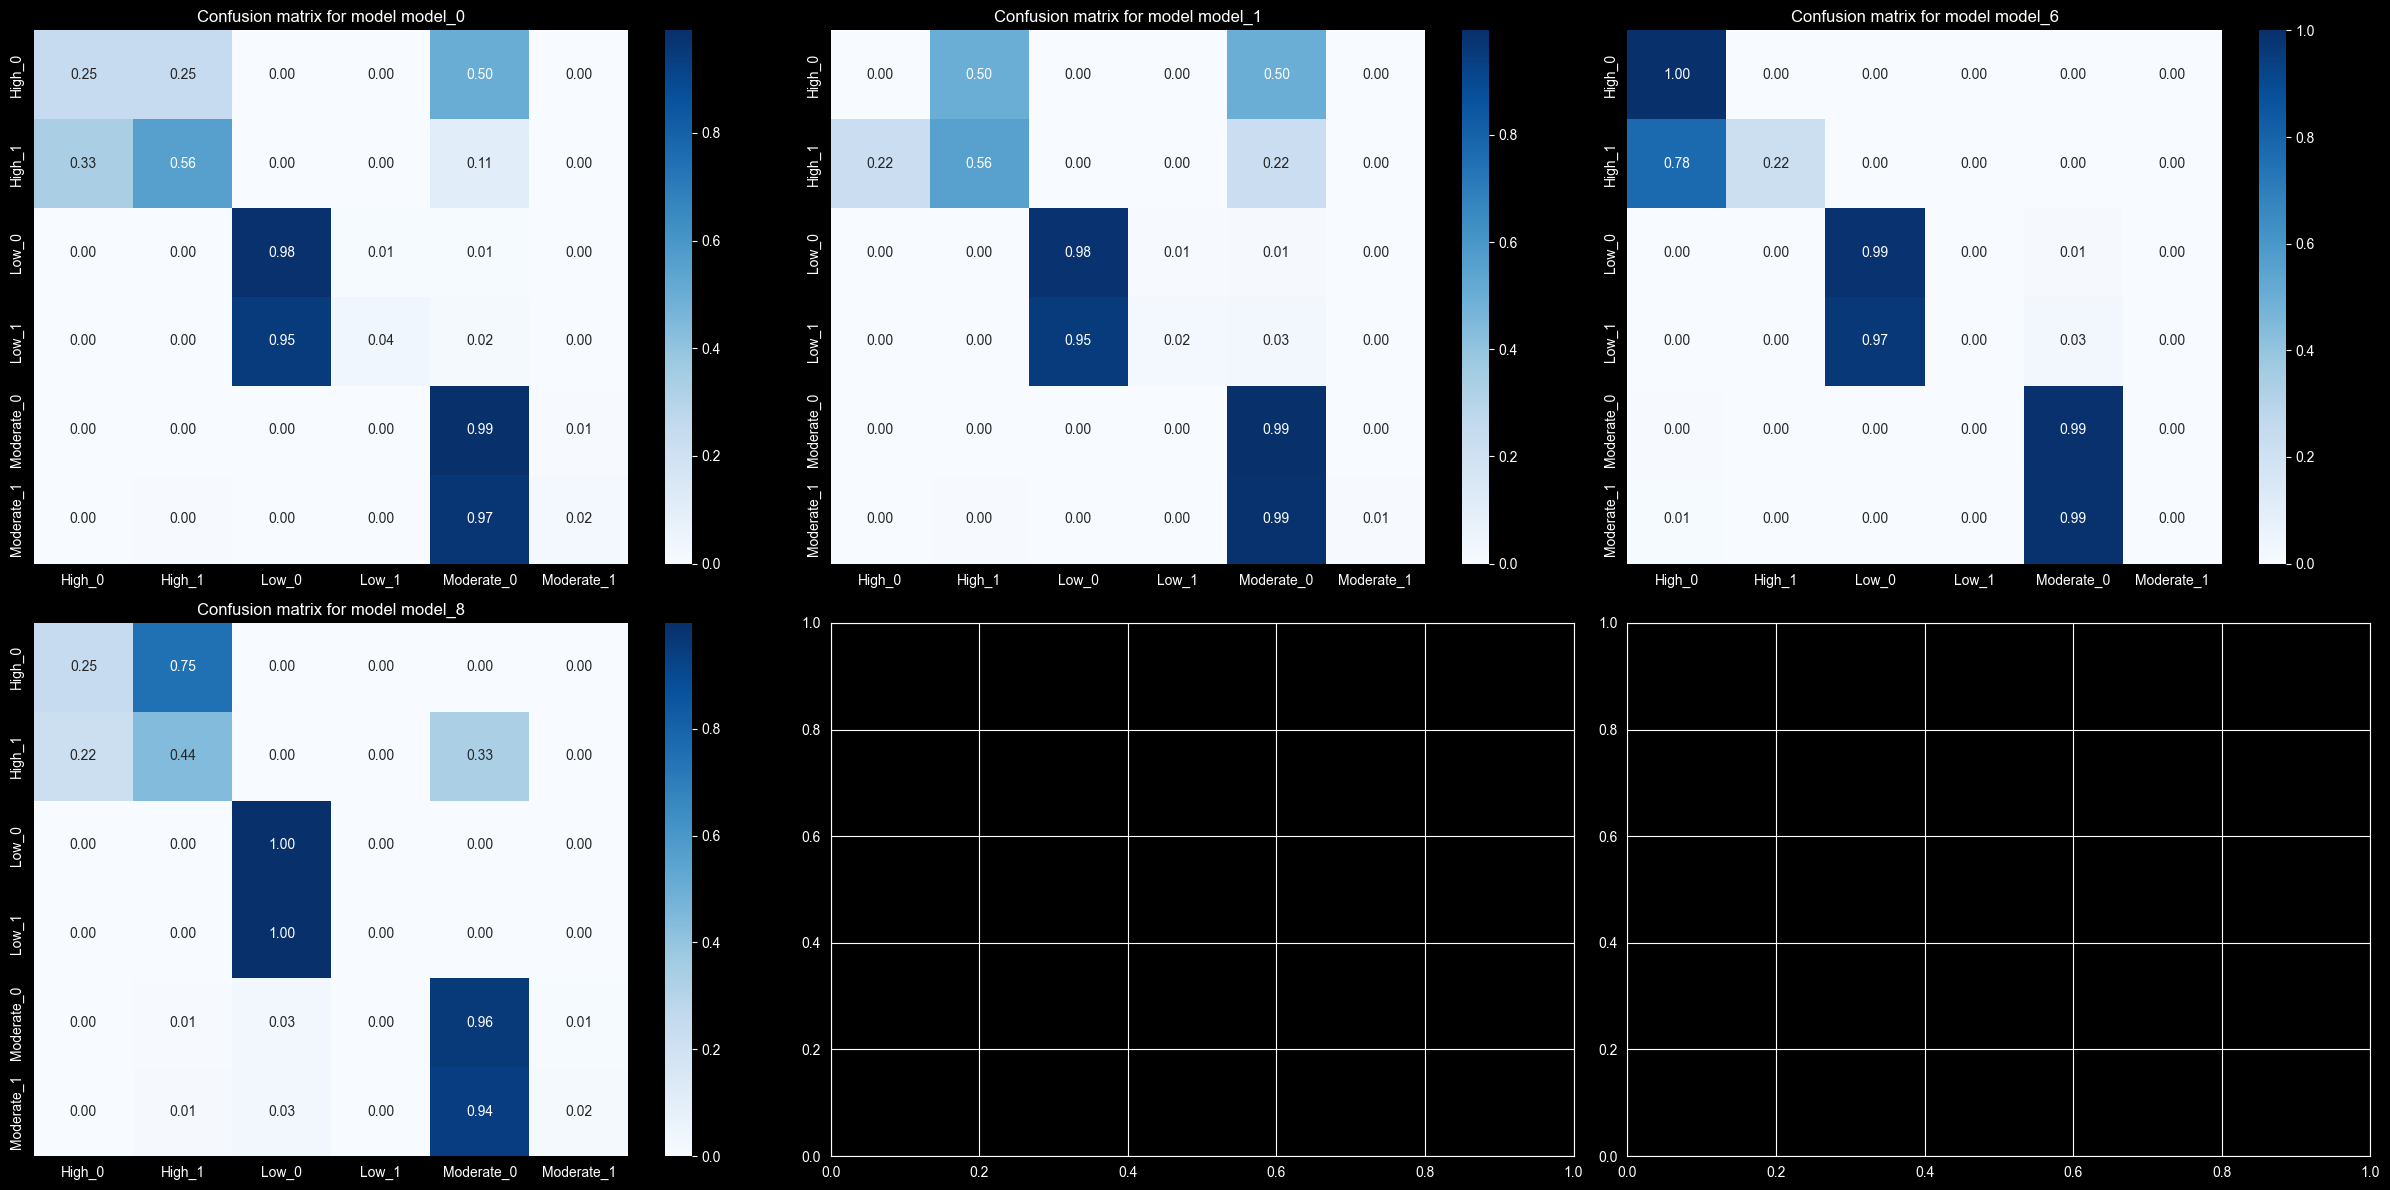

In [92]:
models_list_normal = [model for model, _ in best_models_normal_weights.values()]
plot_best_heatmaps(models_list_normal, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

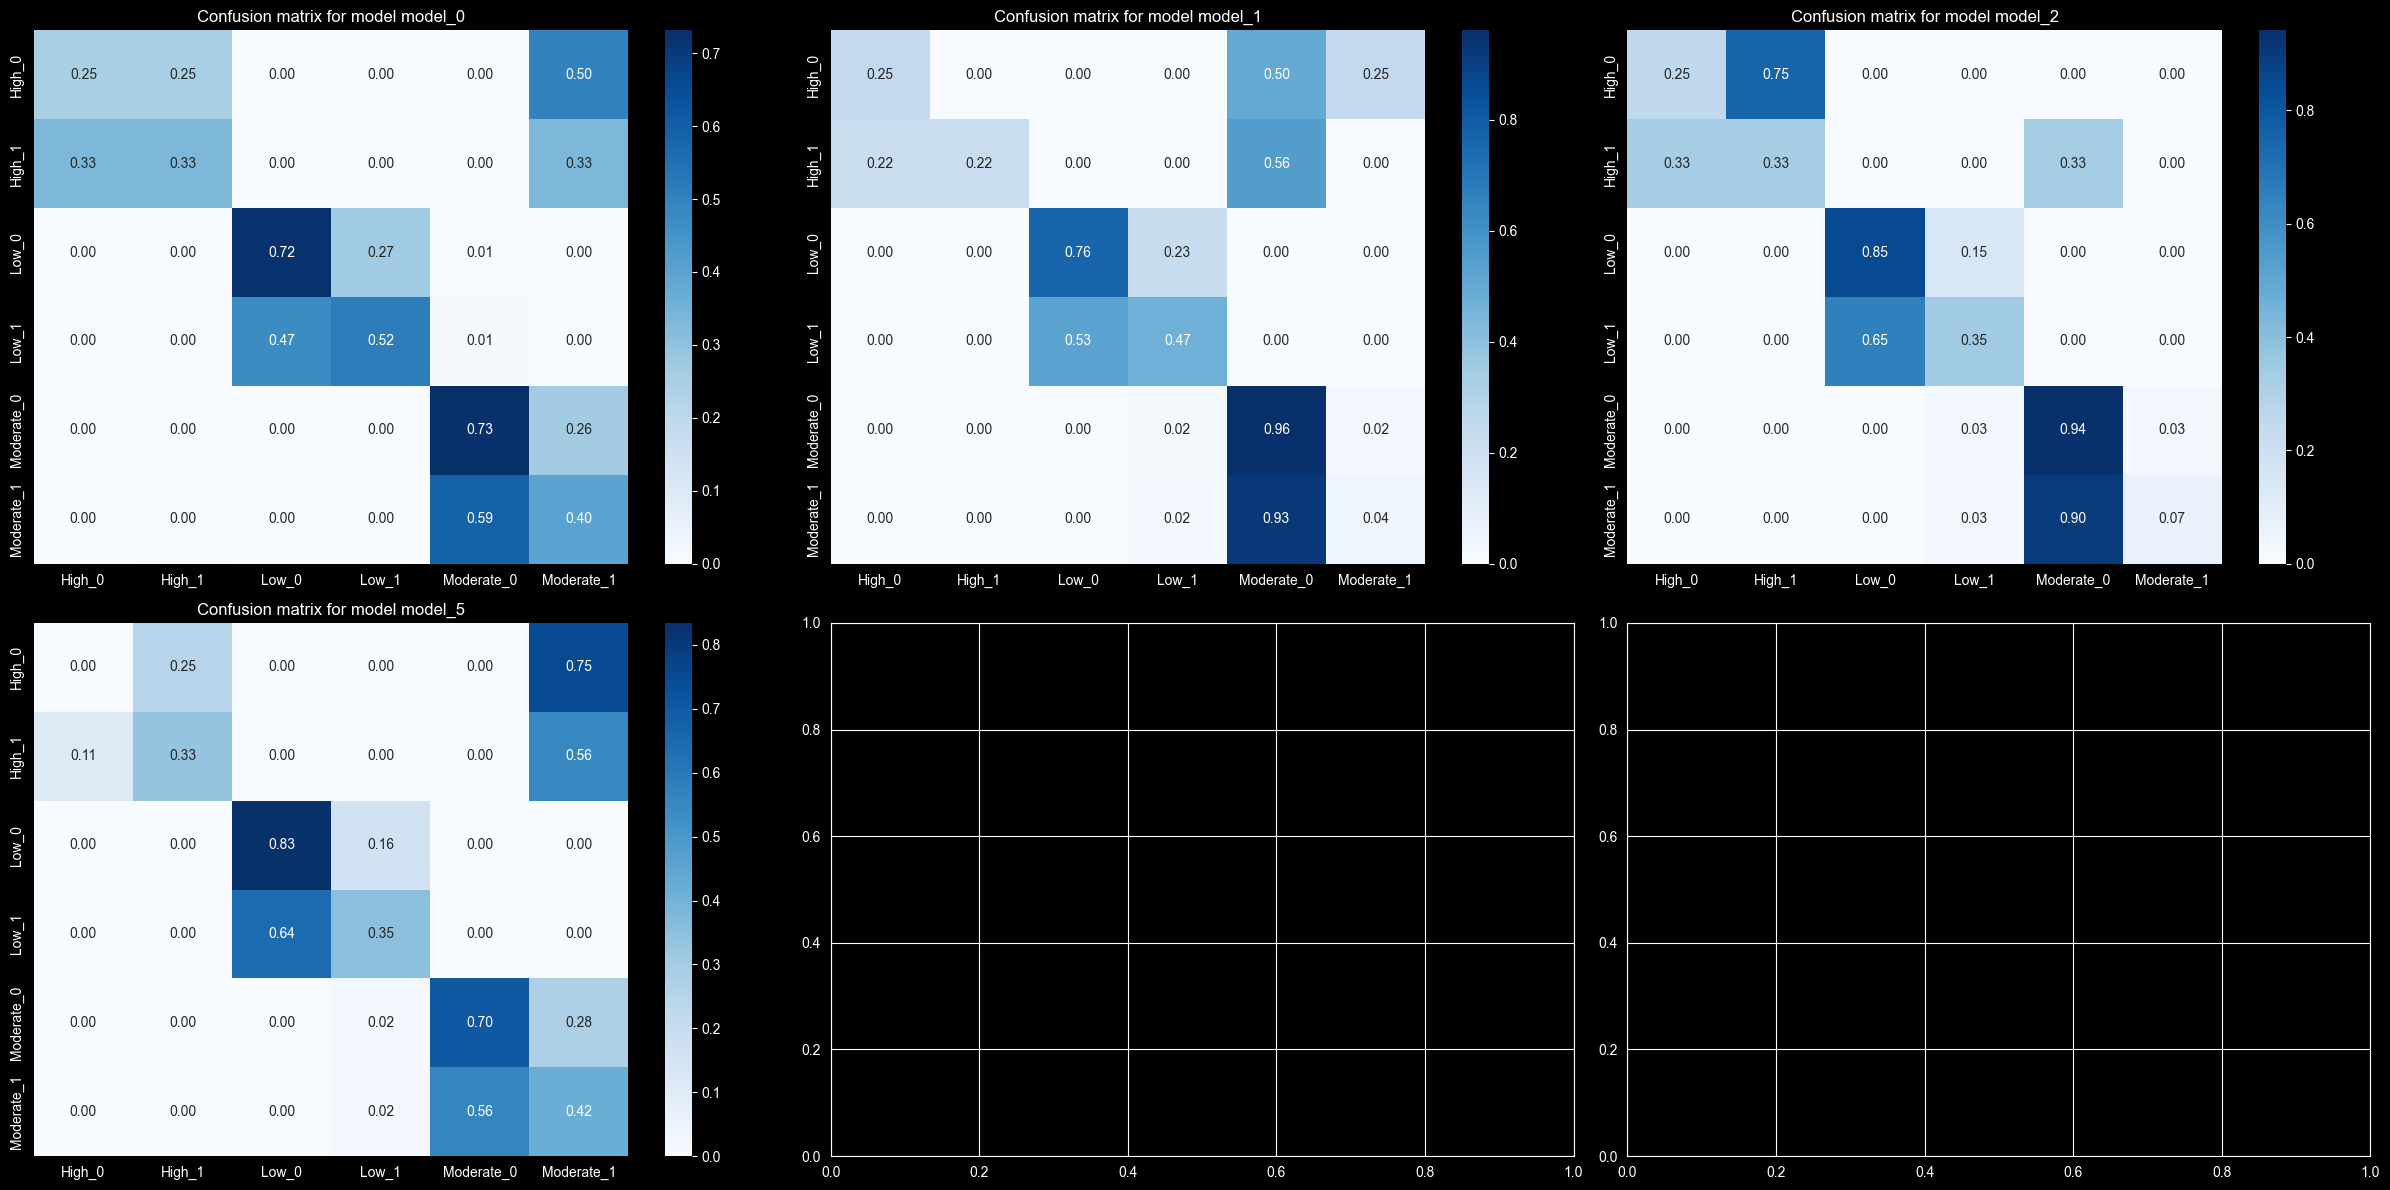

In [93]:
models_list_sqrt = [model for model, _ in best_models_sqrt_weights.values()]
plot_best_heatmaps(models_list_sqrt, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

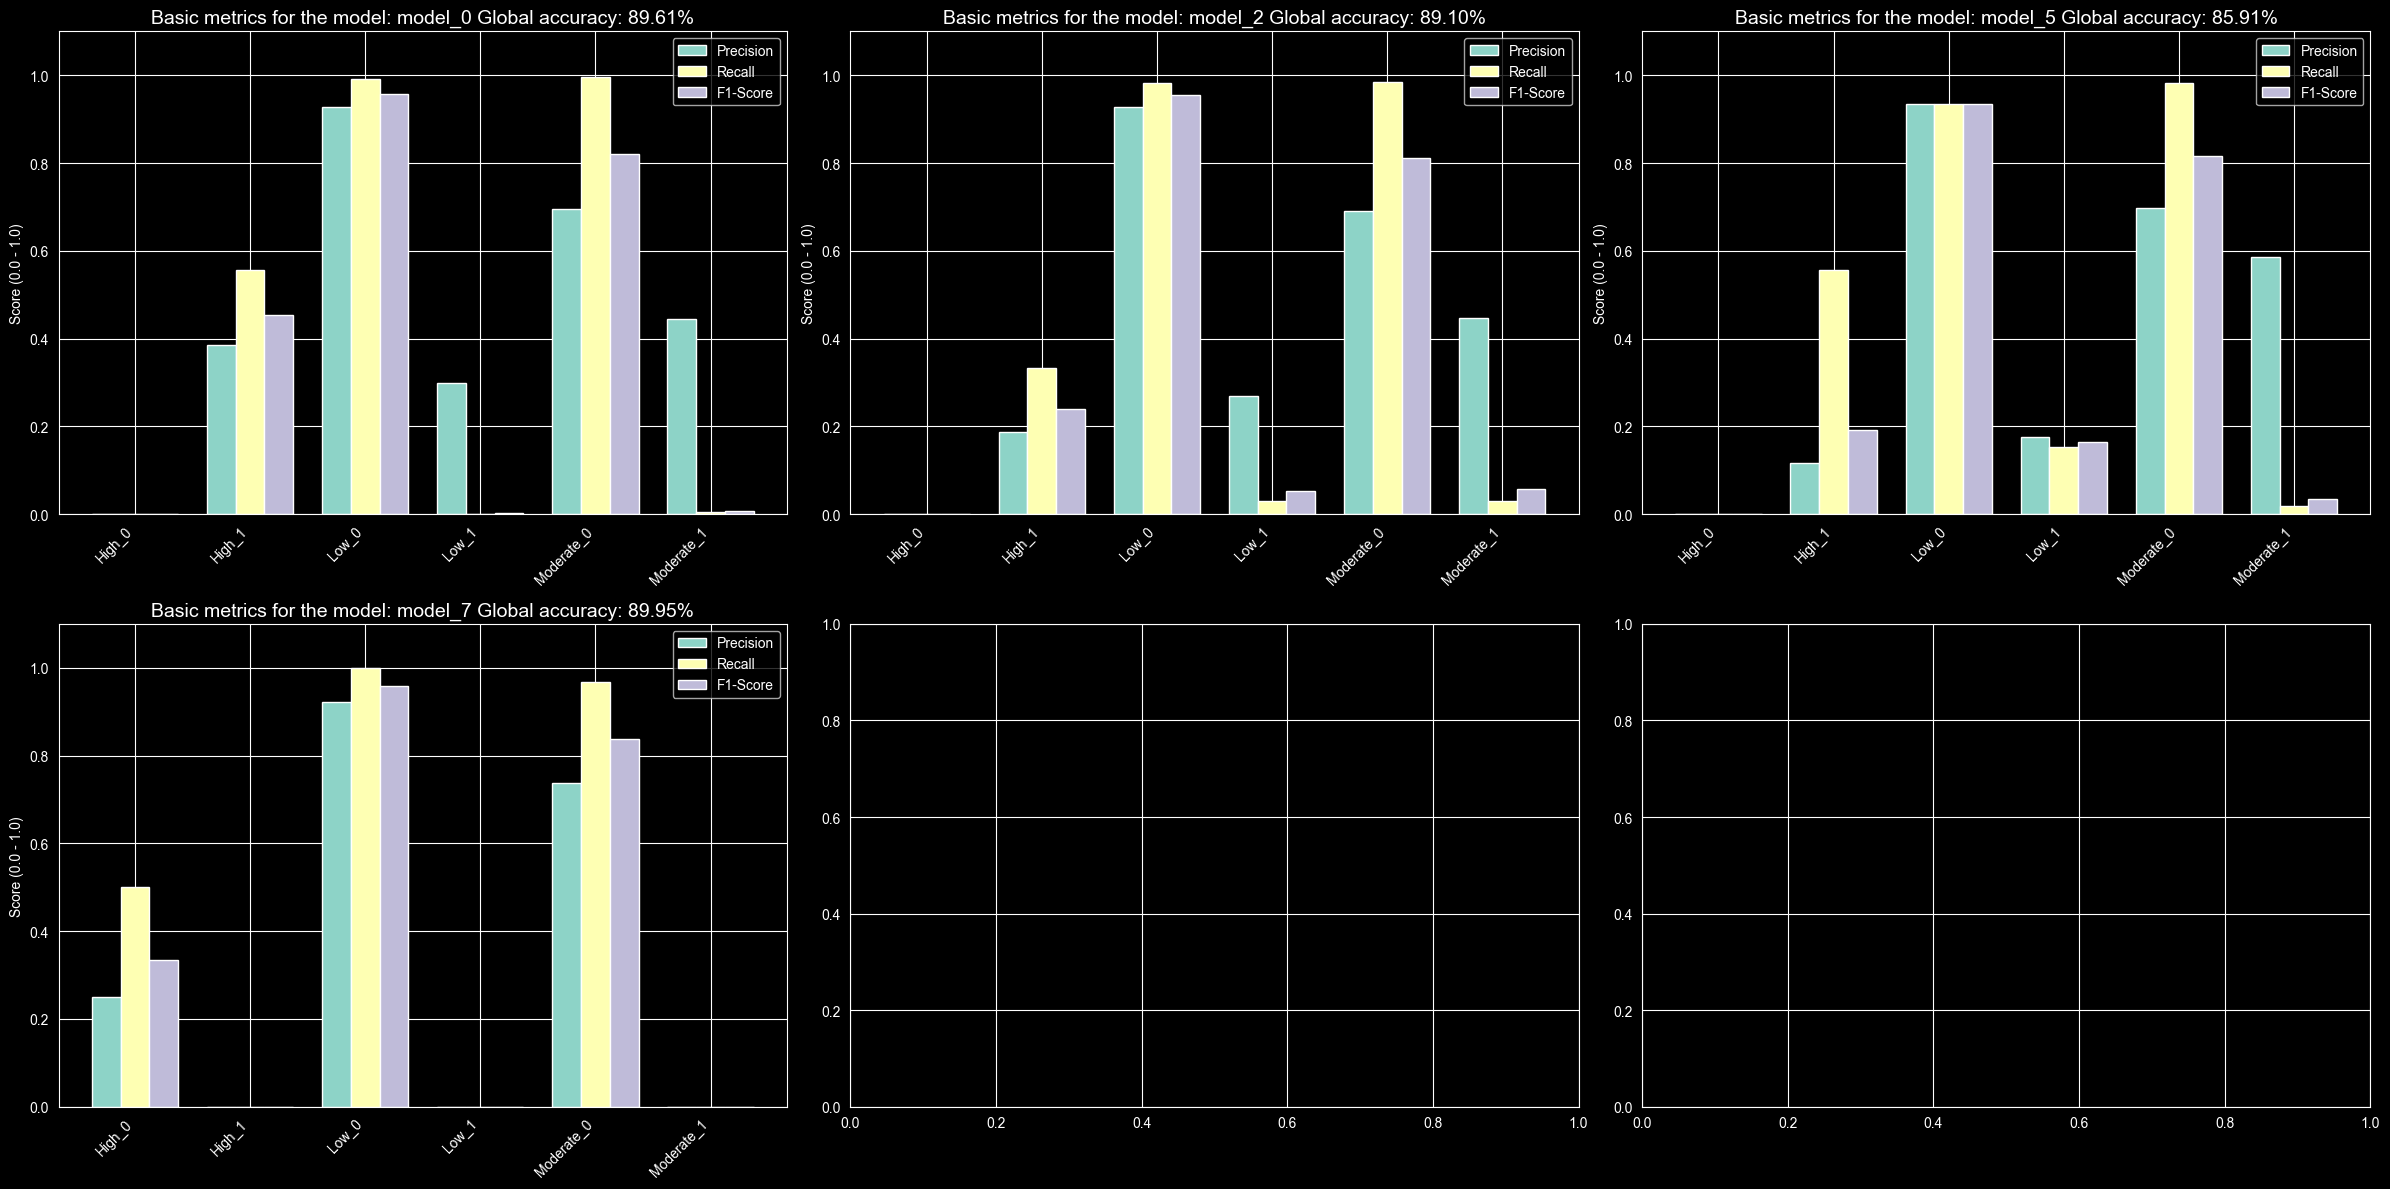

In [94]:
plot_best_basic_scores(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

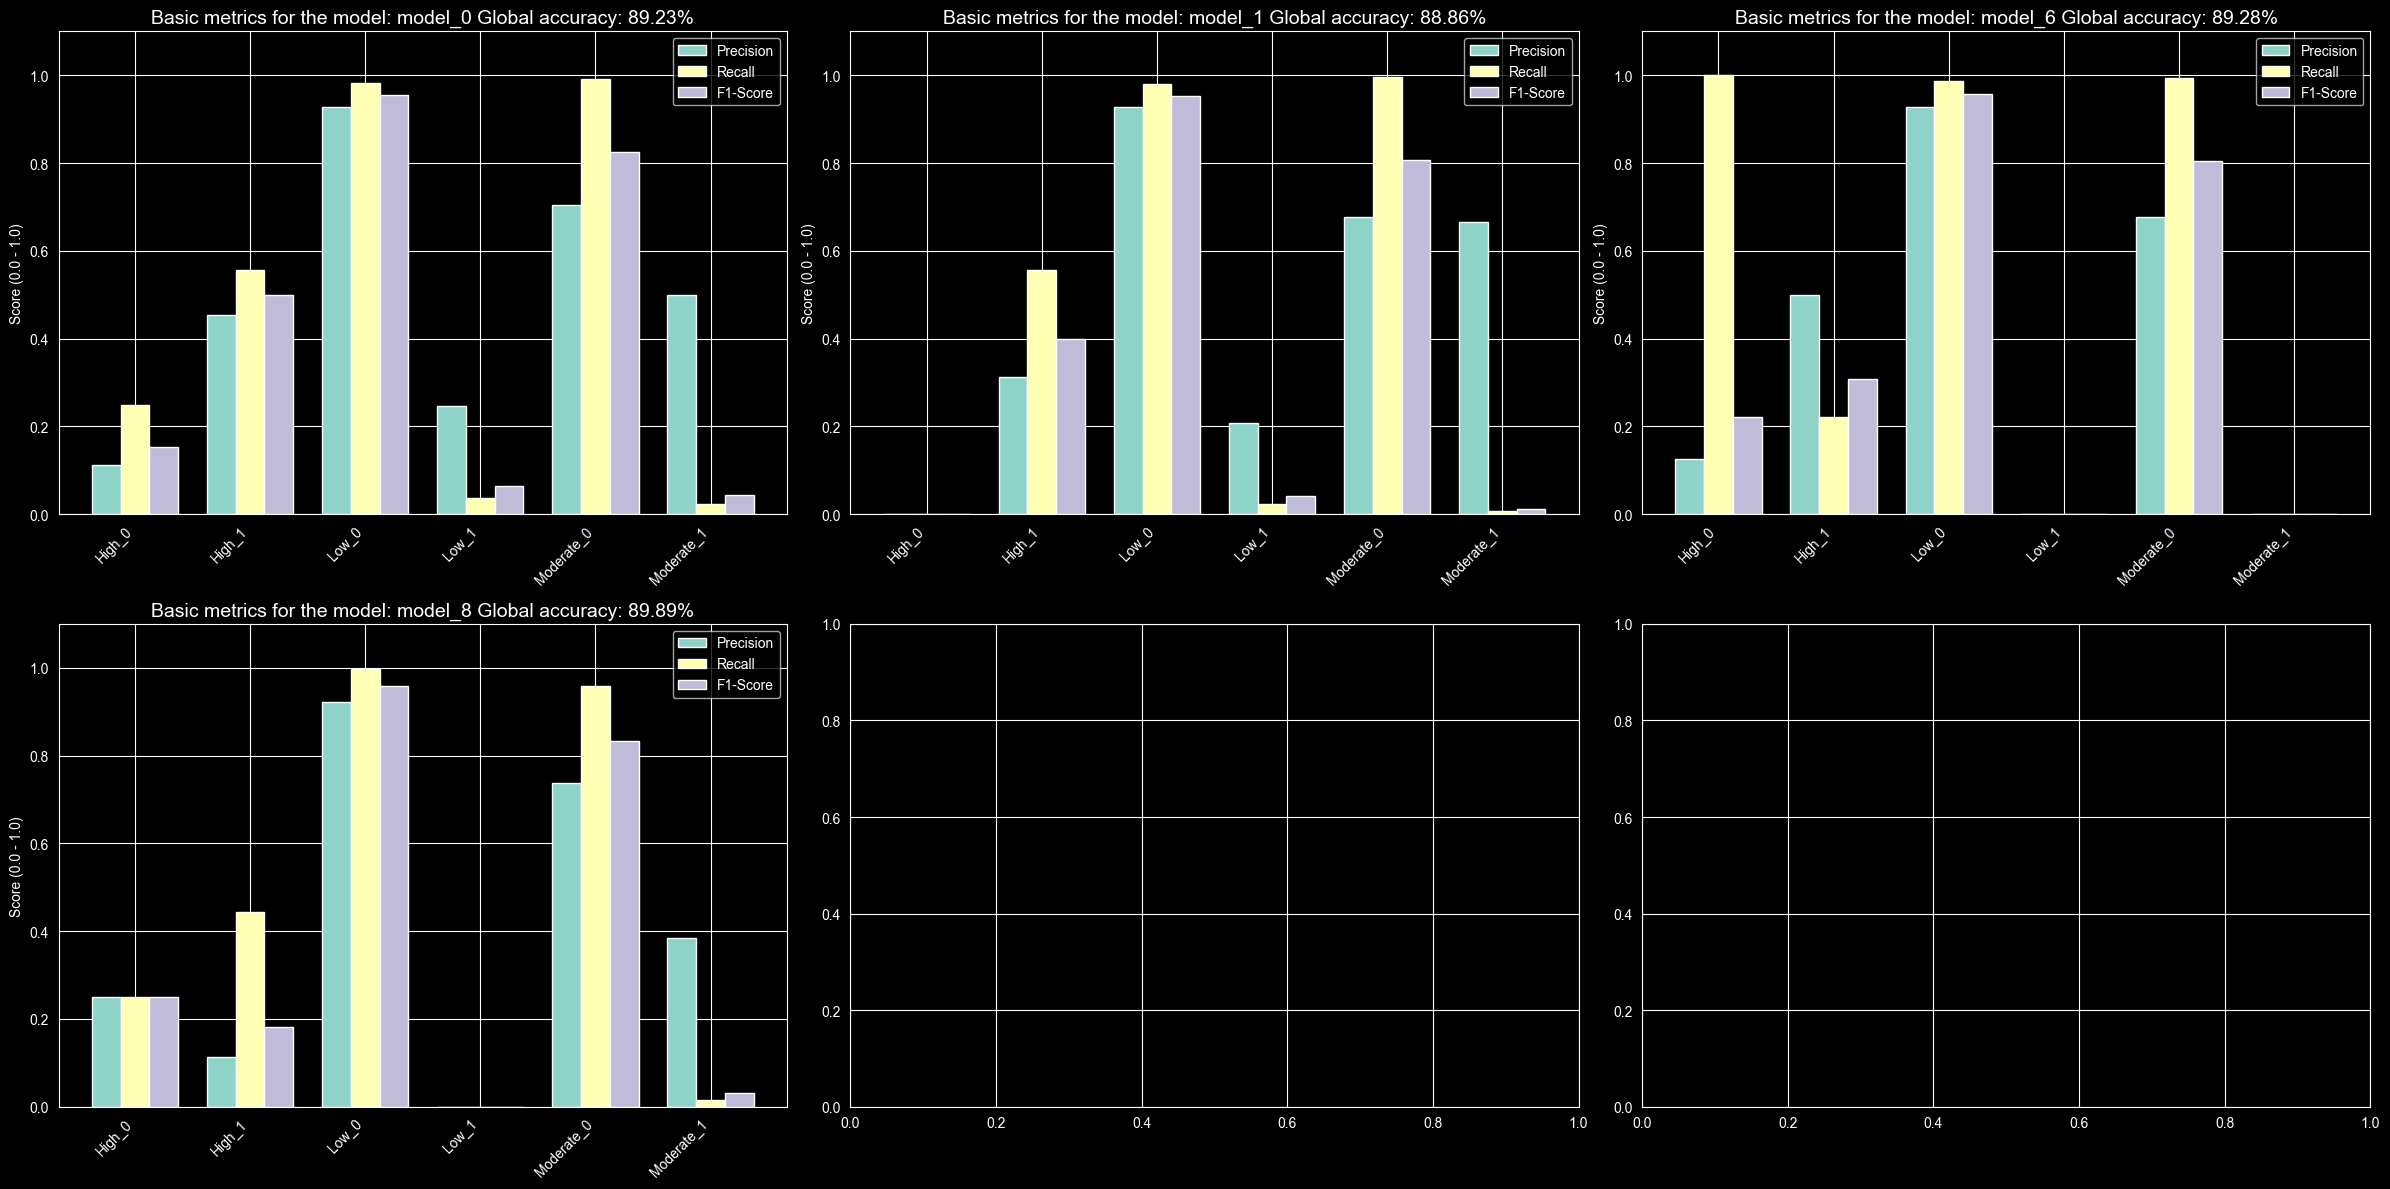

In [95]:
plot_best_basic_scores(models_list_normal, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)


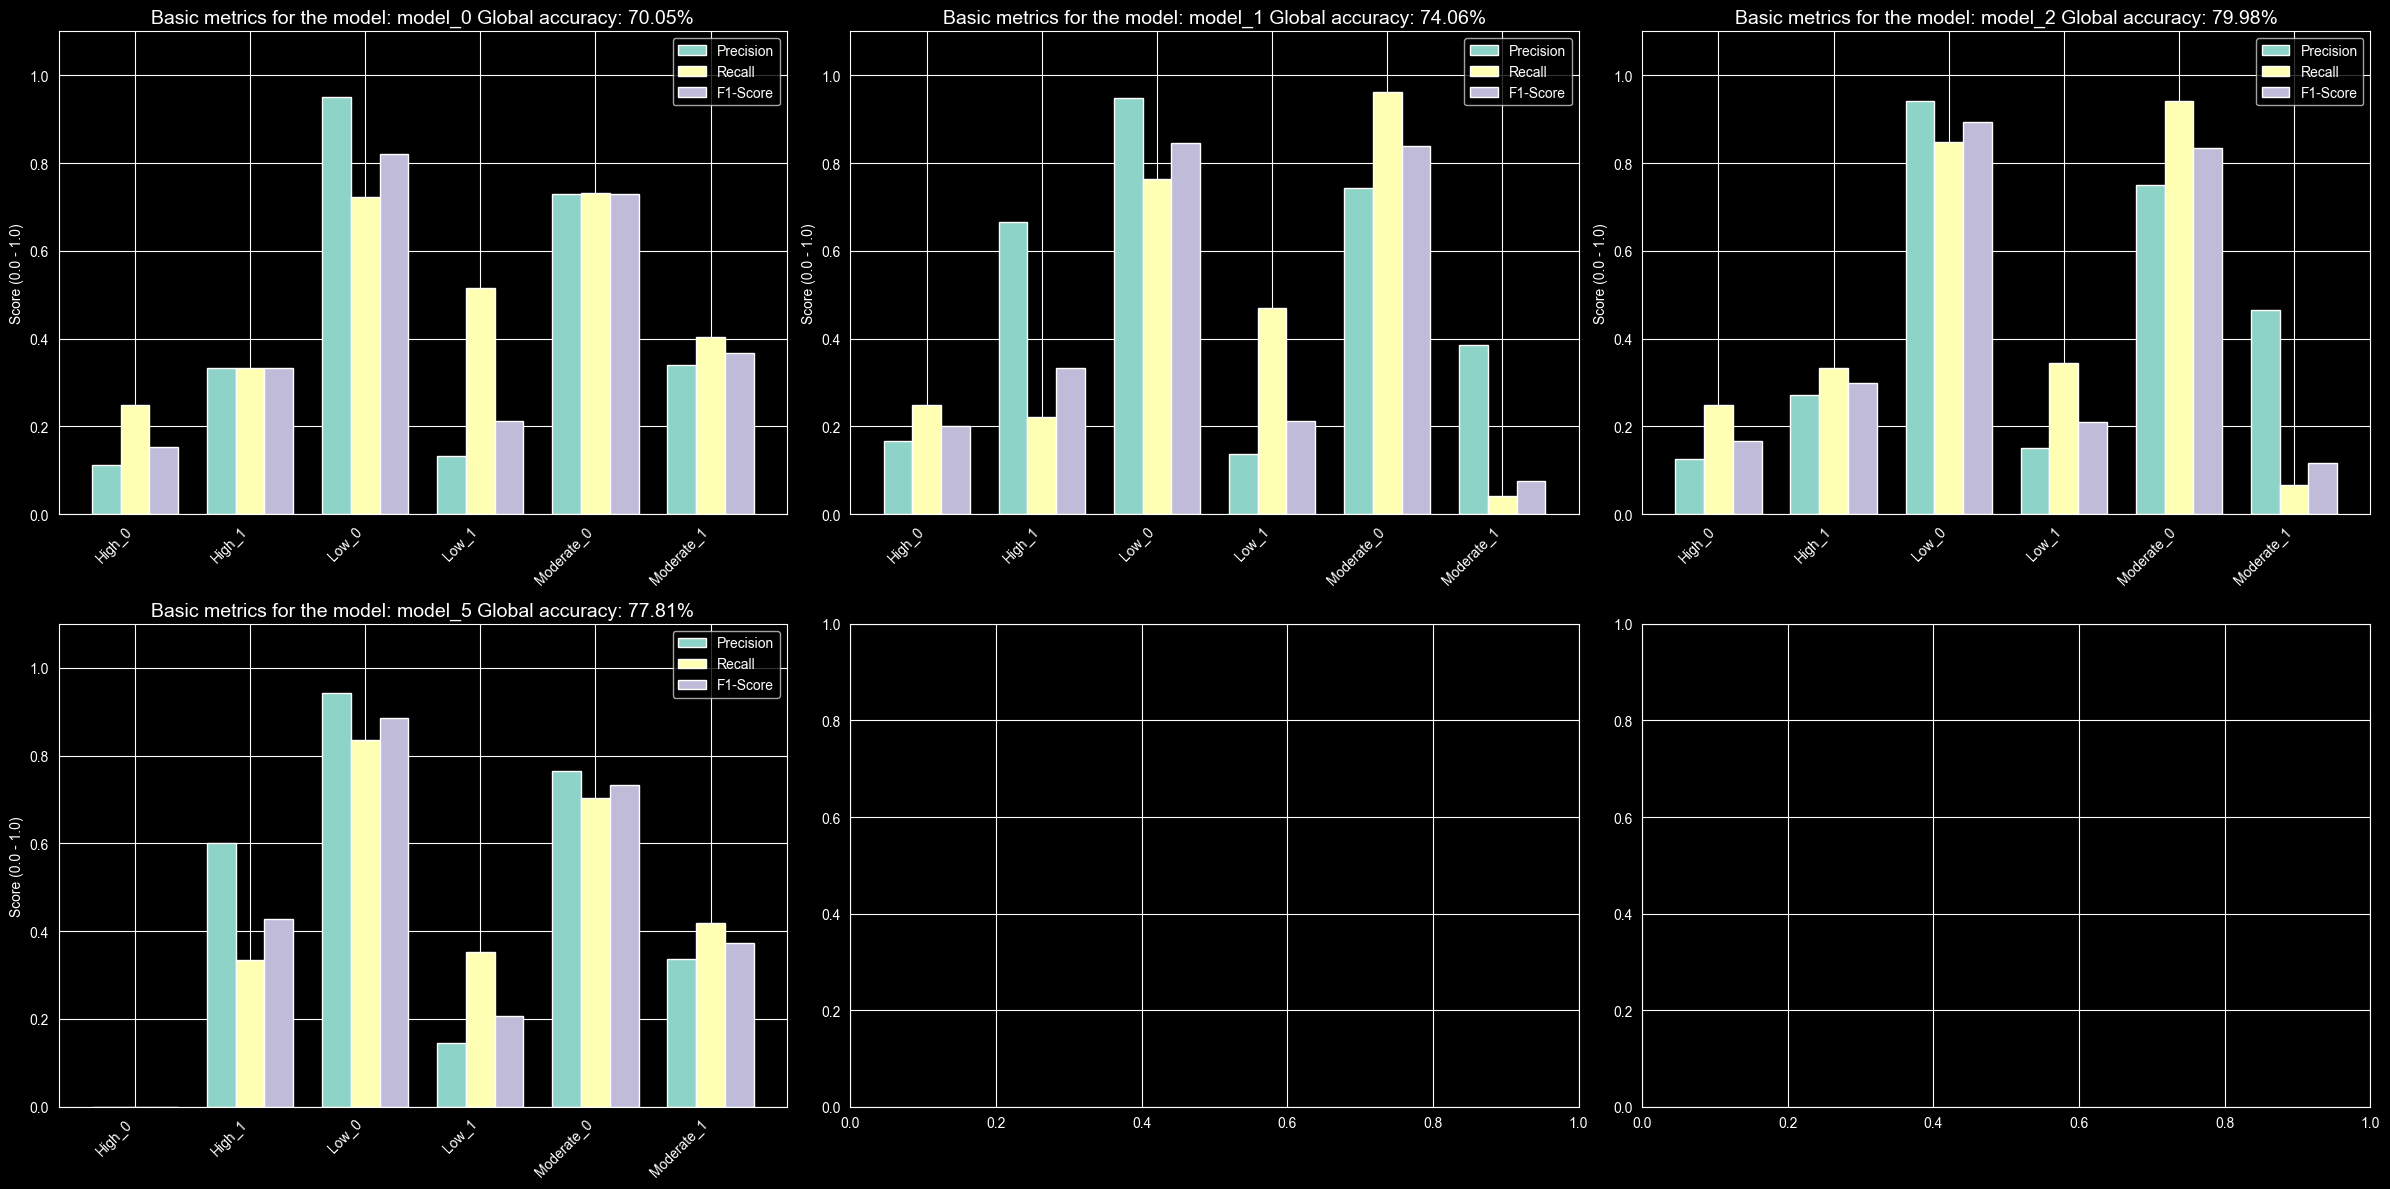

In [96]:
plot_best_basic_scores(models_list_sqrt, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)


Looking at the heatmaps and the bar plots of the test results it is shown that despite the lower overall accuracy, models using the sqrt function to create class weights fared the best when it came to the classes with fewer samples, it is my main goal, so I will be using these function later when searching through more models.

Now I will run Random Search, using the **sqrt** weight to classes, and using the parmeters that shown the biggest promise of success, 100 models will be trained, and from that 100 only best 5 will be inspected more throughly  

In [23]:
best_models = train_many_models(100, [1, 2], [64, 96, 128], [nn.ReLU, nn.SELU, nn.Tanh, nn.GELU], [-1, 0.2, 0.4], [1e-4, 1e-3, 0.0005], [1e-5, 1e-4, 1e-3], [torch.optim.RMSprop, torch.optim.Adam], is_skipping_conn=[True, False], is_batch_norm=[False, True], epochs=15, batch_sizes=[32, 64, 128], top_models=5, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
}, add_weights_to_classes="sqrt")

[2.90842884 2.90842884 0.58168577 1.0404679  0.87932573 1.30068892] [  800   800 20000  6251  8752  4000]


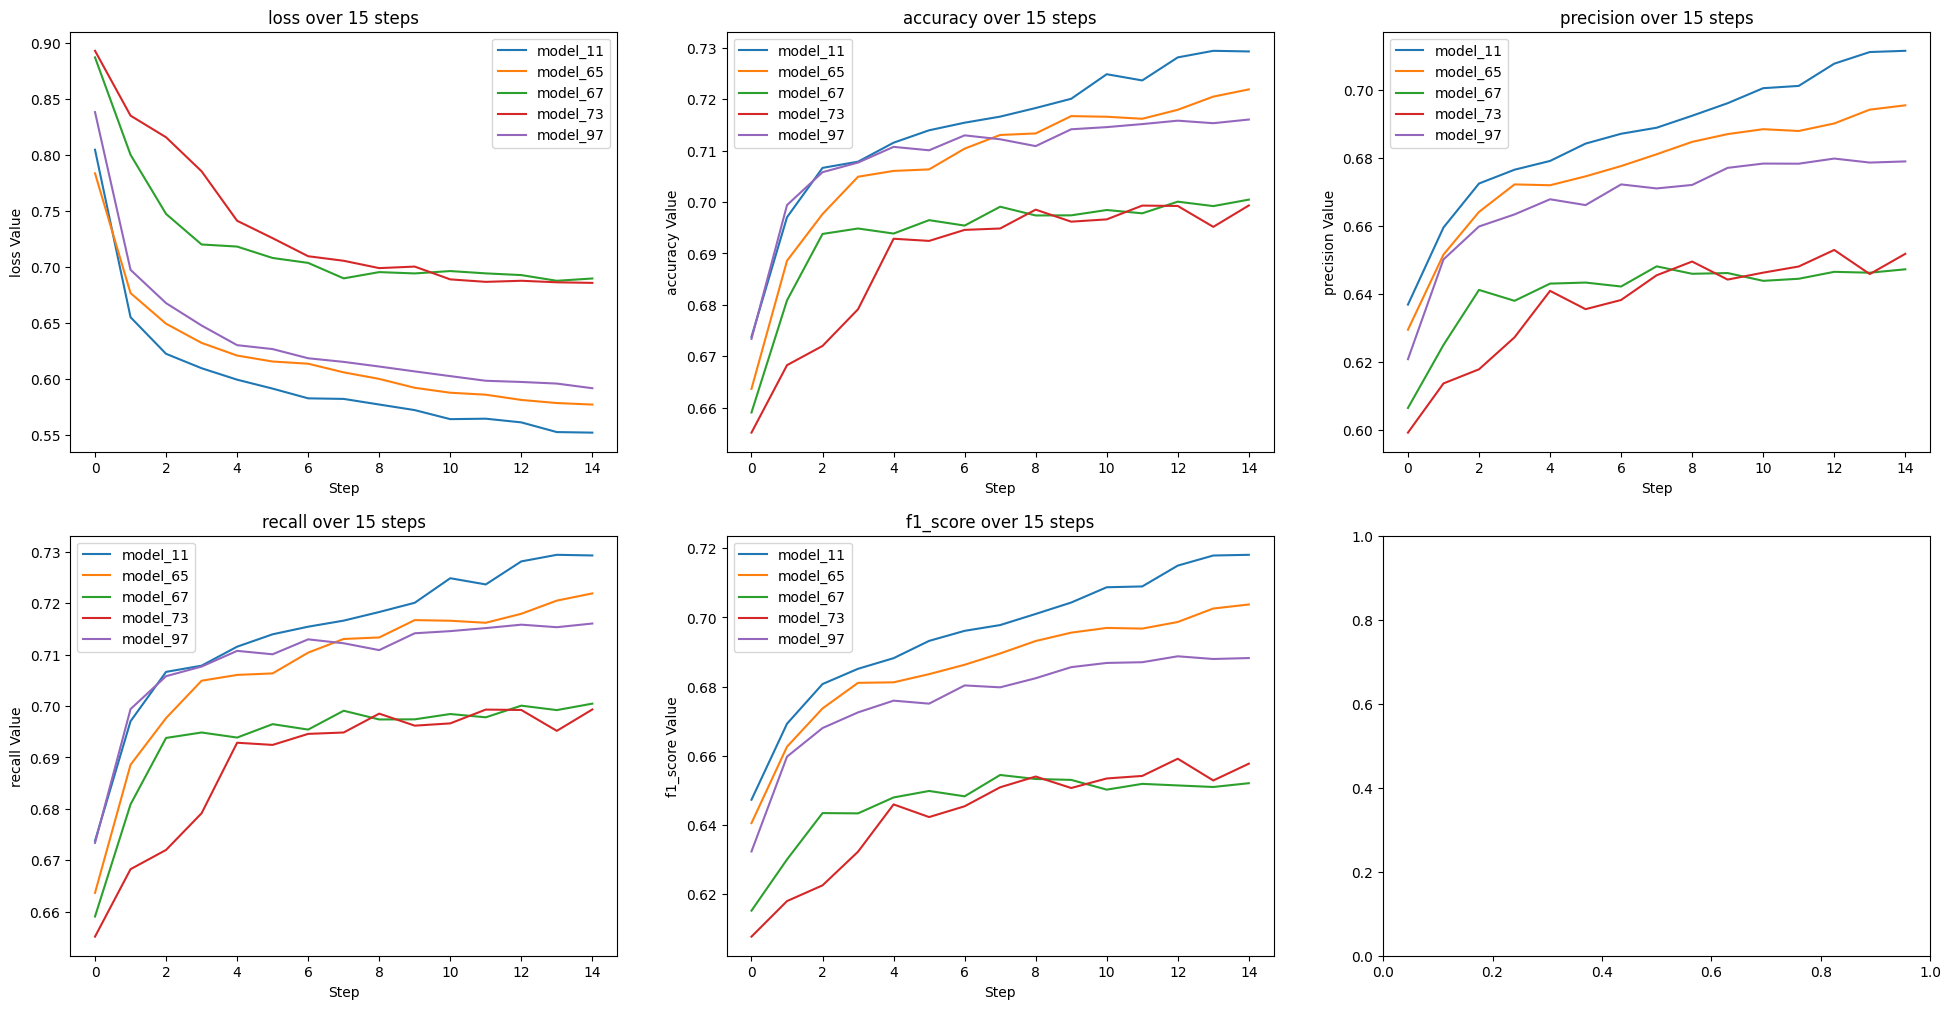

In [24]:
plot_histories("train", gather_histories(best_models))

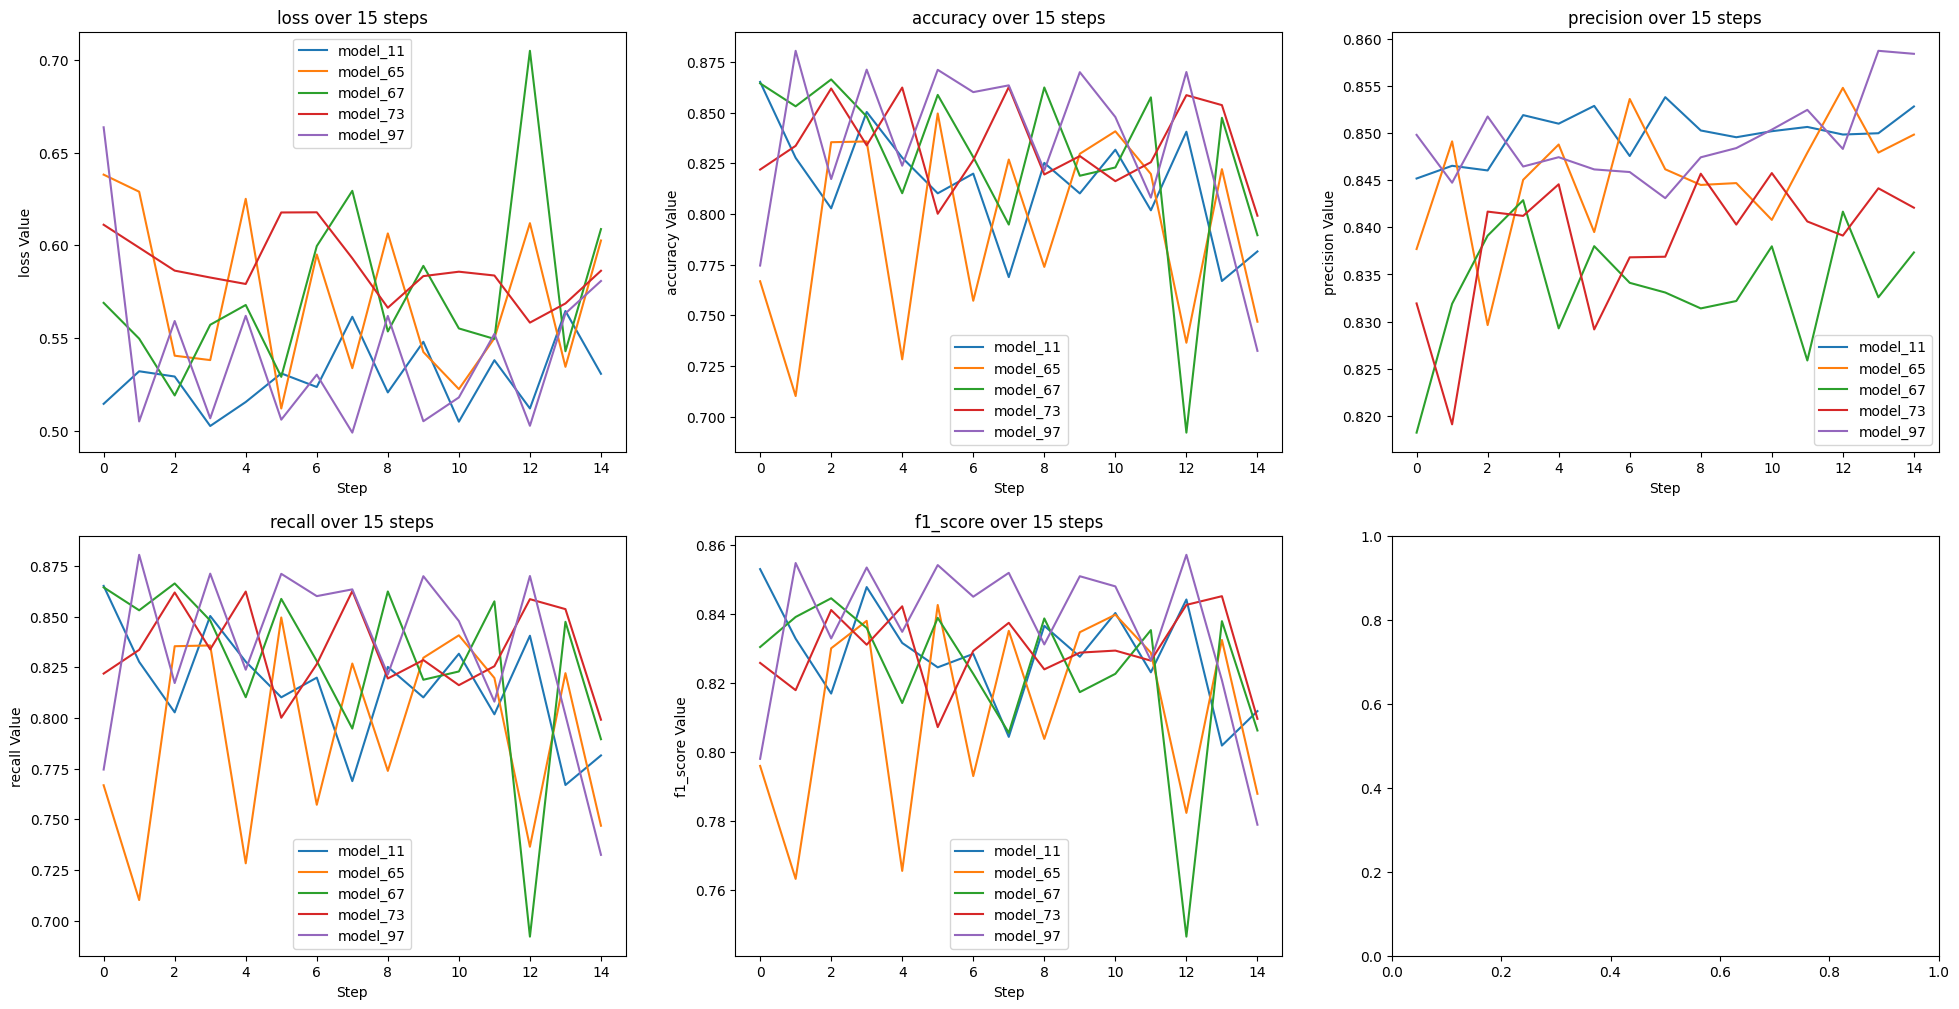

In [25]:
plot_histories("val", gather_histories(best_models))

In [26]:
models_list = [model for model, _ in best_models.values()]


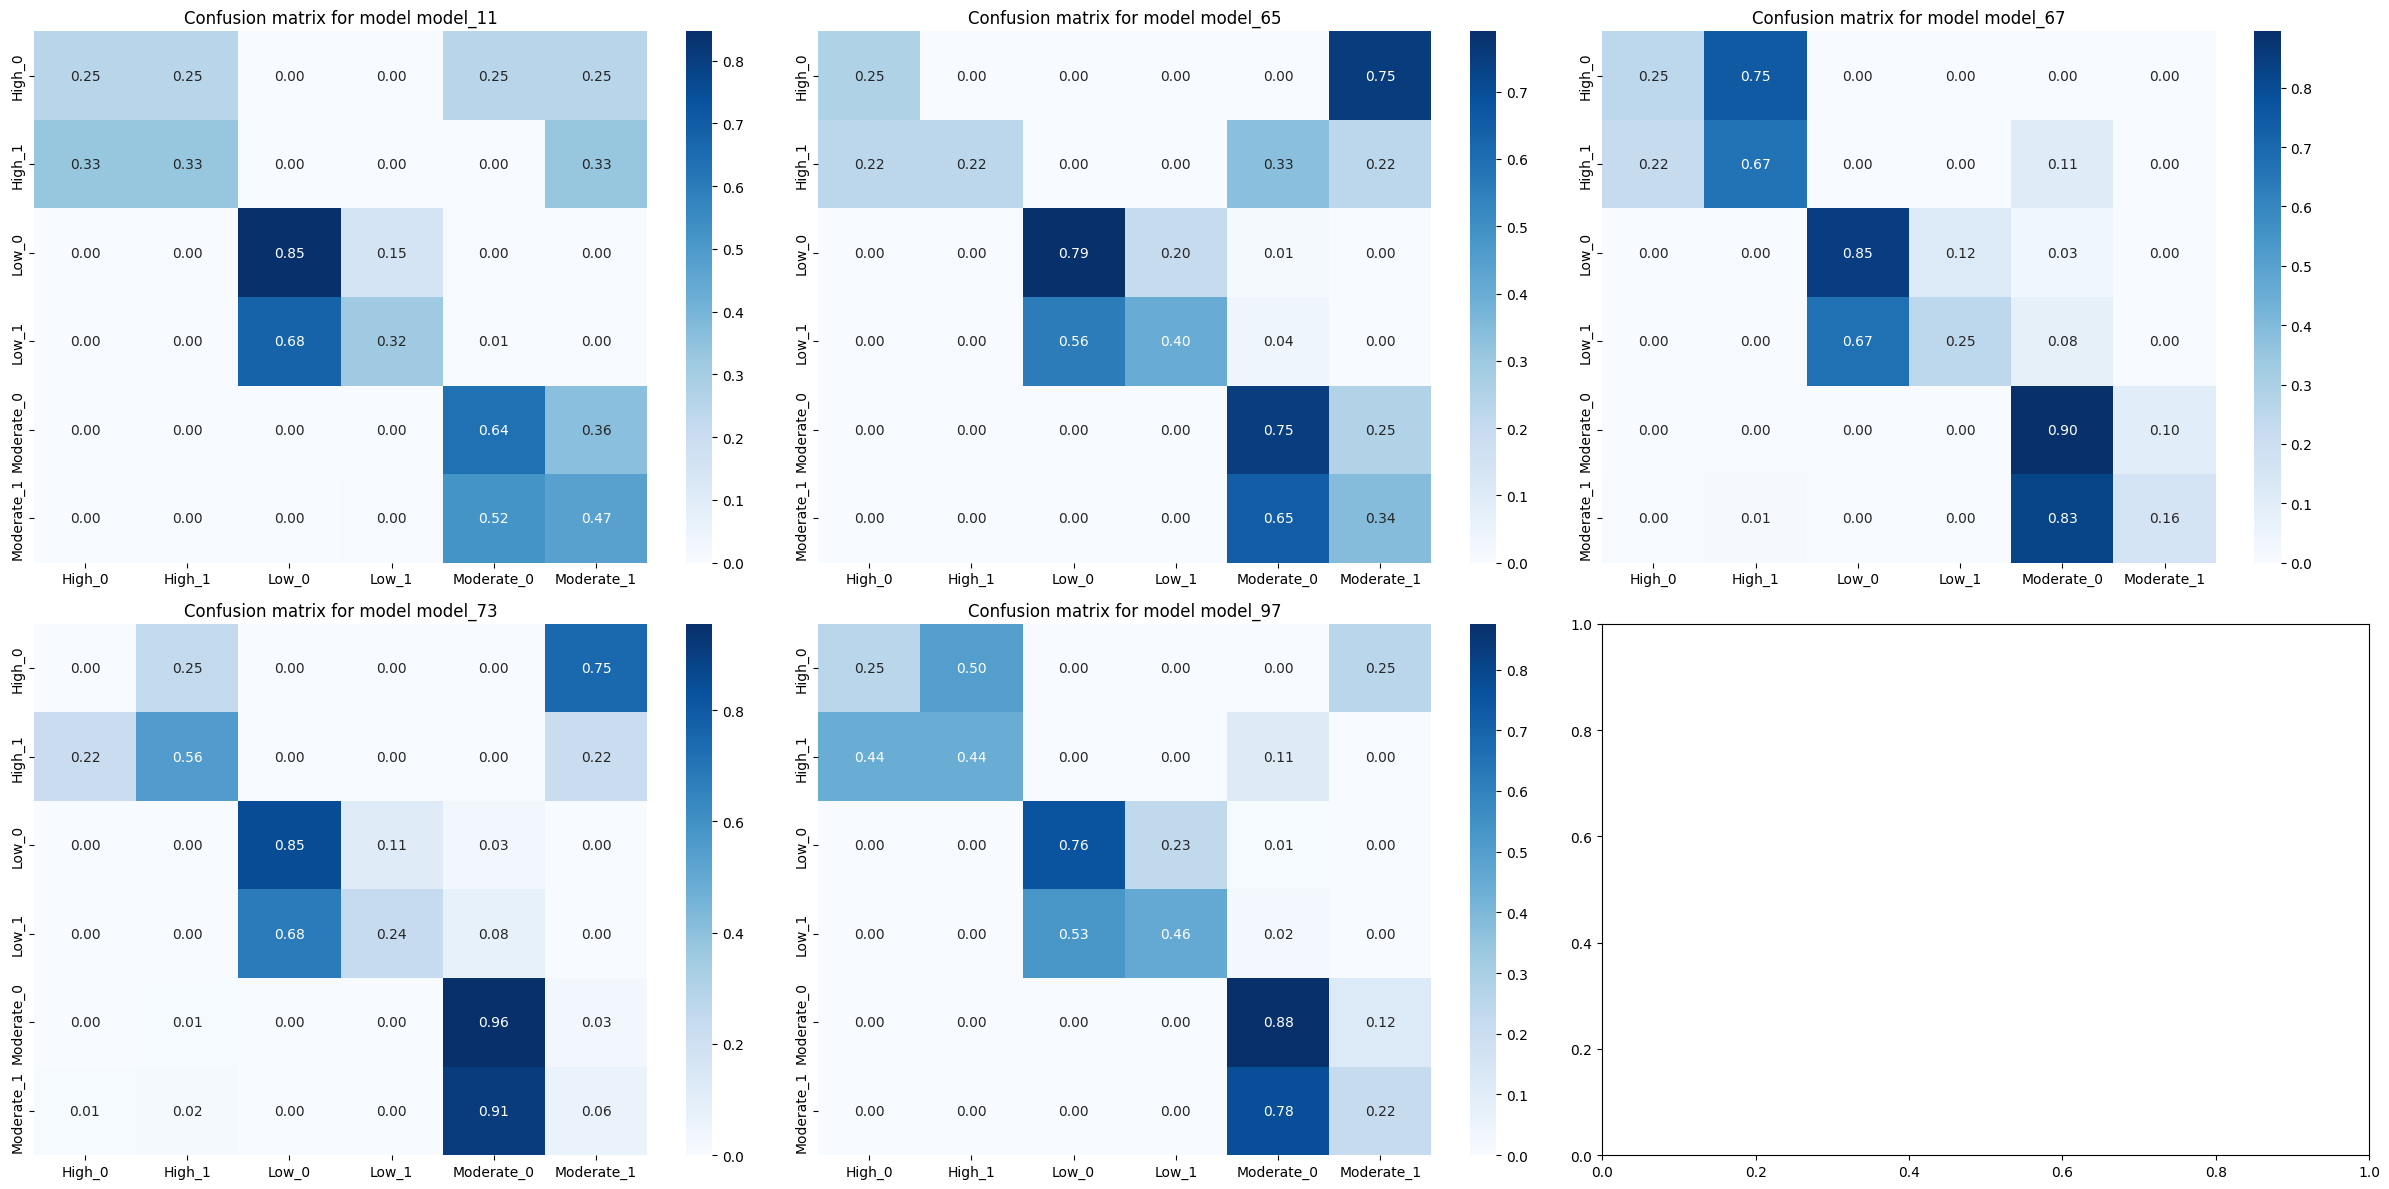

In [29]:
models_list = [model for model, _ in best_models.values()]
plot_best_heatmaps(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

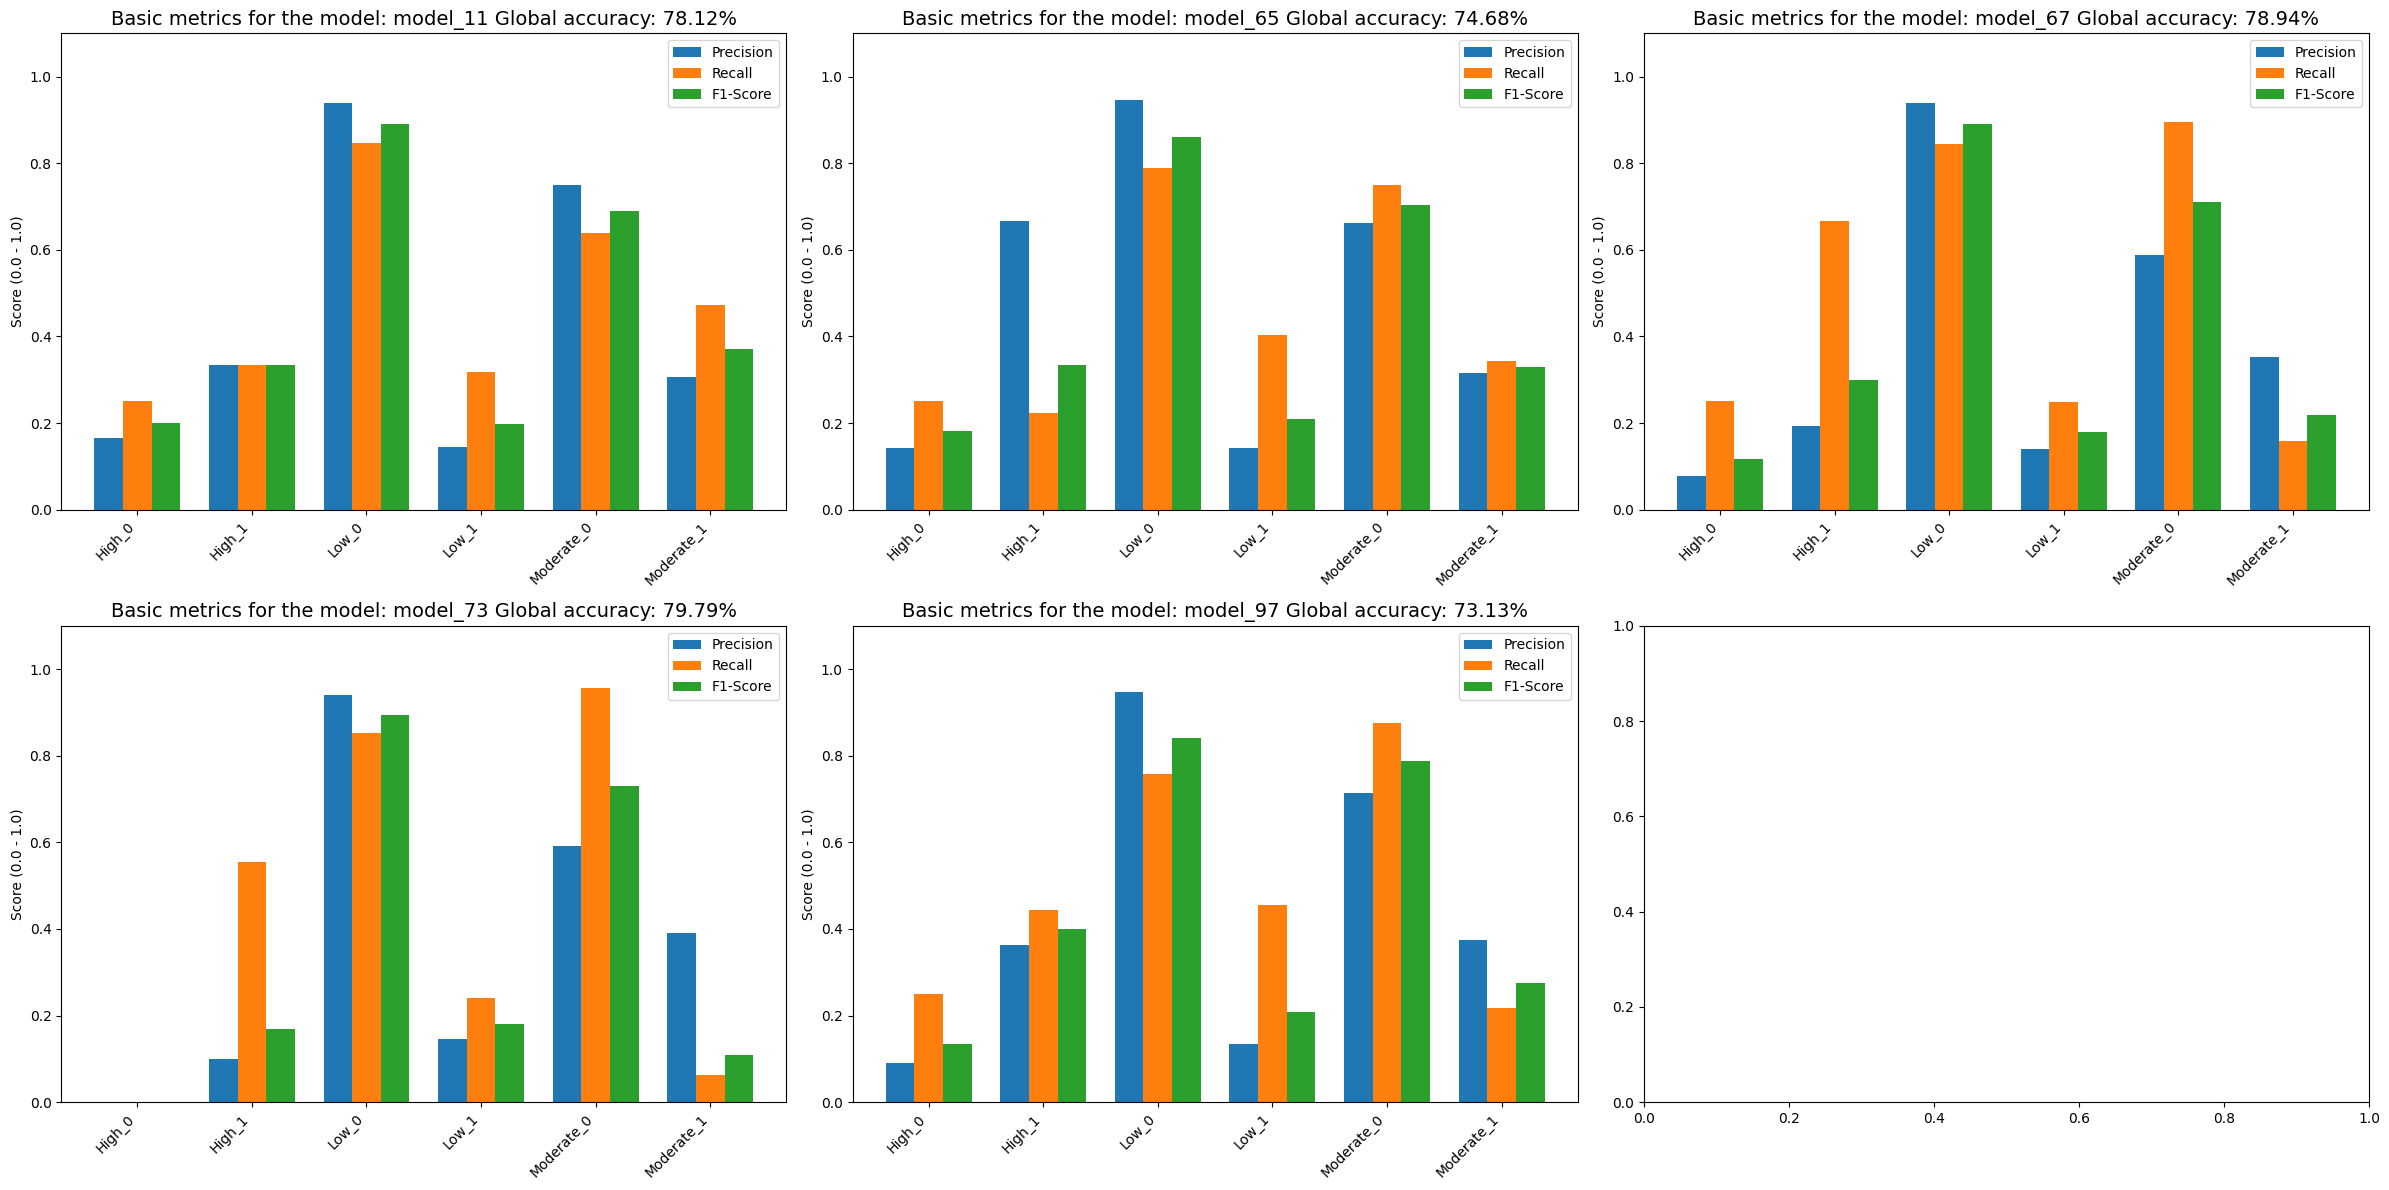

In [30]:
plot_best_basic_scores(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

In [31]:
models_info = [model[0].model_info for model in best_models.values()]
pprint(models_info, indent=4, sort_dicts=False)

[   {   'model': {   'neurons': 128,
                     'dropouts': [-1, 0.2],
                     'is_batchnorm': [False, True],
                     'activations': ['GELU', 'Tanh'],
                     'is_skipping_conn': [False, False],
                     'input_shape': 37,
                     'output_shape': 6,
                     'name': 'model_11'},
        'train': {   'epochs': 15,
                     'optimizer': 'Adam',
                     'criterion': 'CrossEntropyLoss',
                     'batch_size': 32,
                     'learning_rate': 0.001,
                     'lr_decay': 1e-05}},
    {   'model': {   'neurons': 128,
                     'dropouts': [0.2, 0.2],
                     'is_batchnorm': [True, False],
                     'activations': ['GELU', 'SELU'],
                     'is_skipping_conn': [True, True],
                     'input_shape': 37,
                     'output_shape': 6,
                     'name': 'model_65'},
        'tra

We can see that even Random Search results in models with not that ideal accuracy, but where they can better spot the classes with low samples amount, info I've gathered:
- RMSprop dominated
- BatchNorm, Dropout and Skipping Connections were widely used by every top model
- Preffered learning rate was $1e-3$
- ReLu was the  least used activation function, is was expected because SELU and GELU are newer and better
- Models do not need that many epochs to train, validation metrics fluctuate from the get go
- Bigger models were less effective there - with 2 hidden layers

<br>Now let's control check the Random Search without the class weights, also let's adjust the params space - changed the epochs num and learning rates avaiable


In [38]:
best_models = train_many_models(75, [0, 1, 2], [64, 96, 128], [nn.ReLU, nn.SELU, nn.Tanh, nn.GELU], [-1, 0.2, 0.4], [1e-3, 0.0005], [1e-5, 1e-4, 1e-3], [torch.optim.RMSprop, torch.optim.Adam], is_skipping_conn=[True, False], is_batch_norm=[False, True], epochs=5, batch_sizes=[32, 64, 128], top_models=5, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

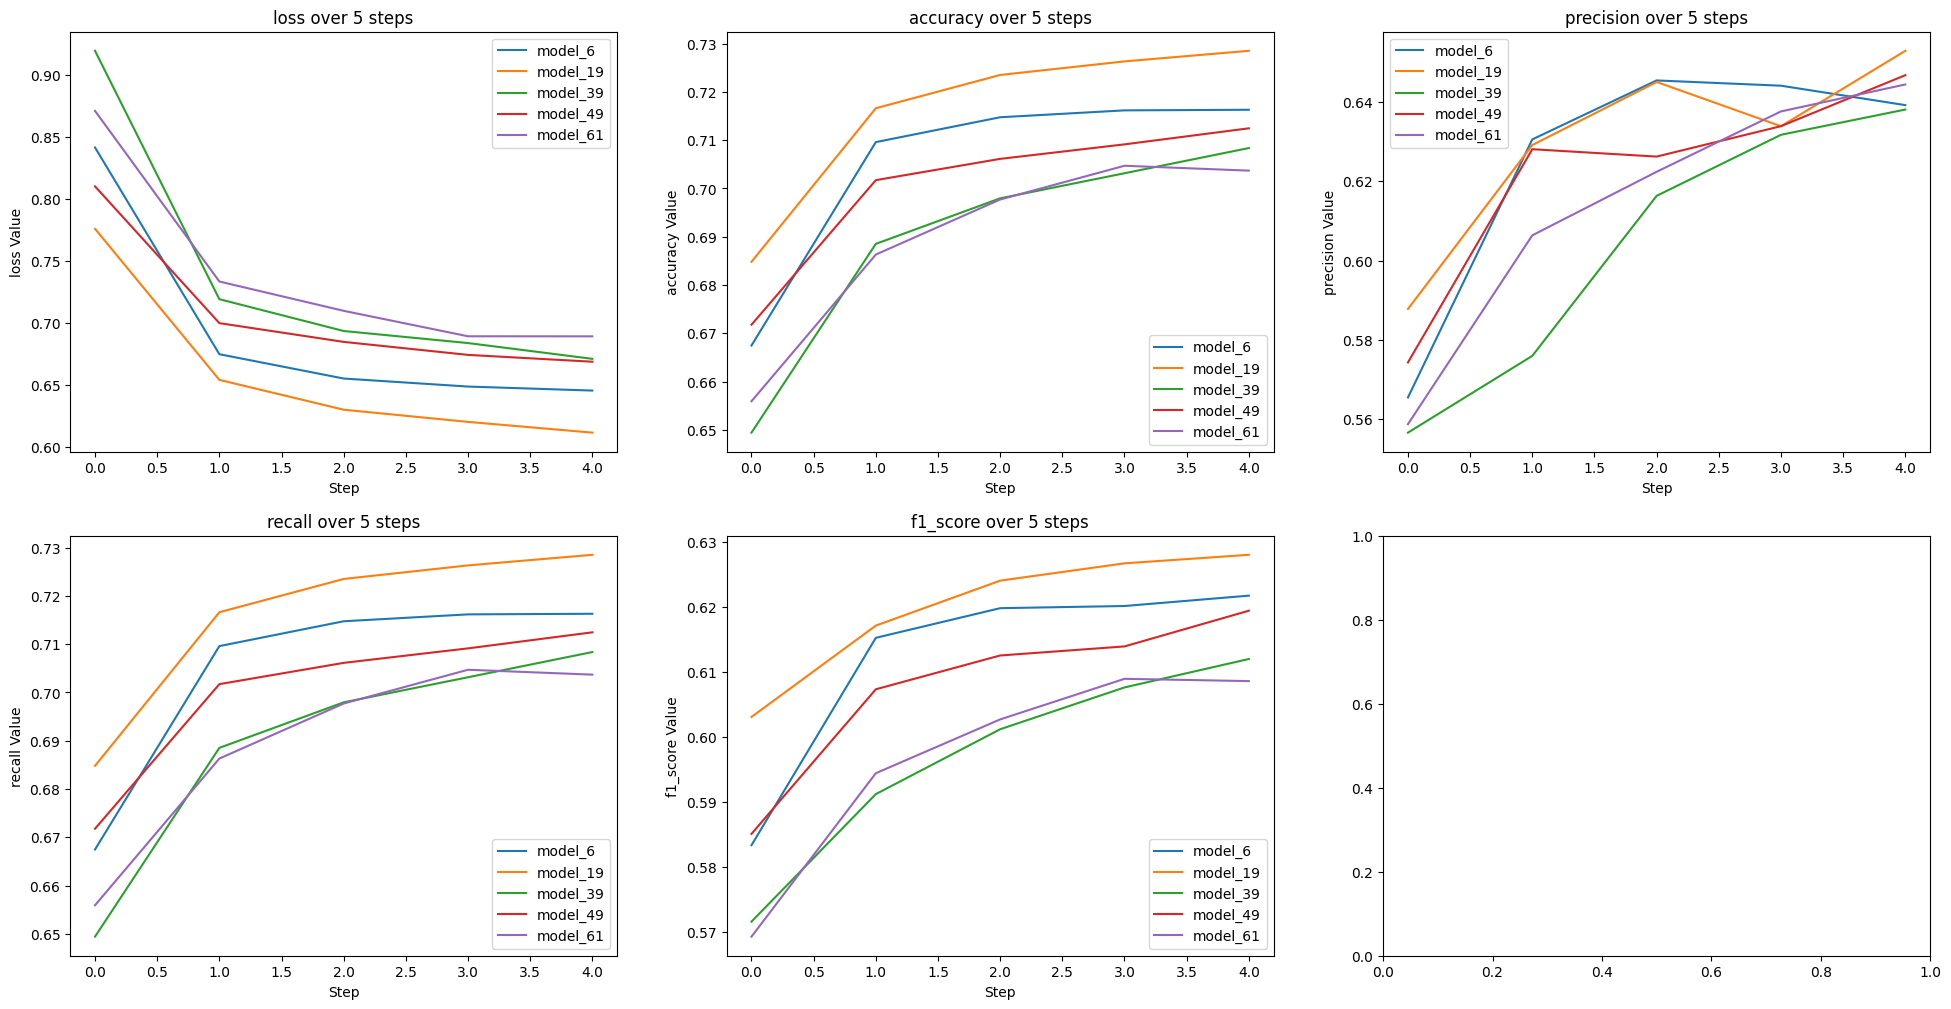

In [39]:
plot_histories("train", gather_histories(best_models))

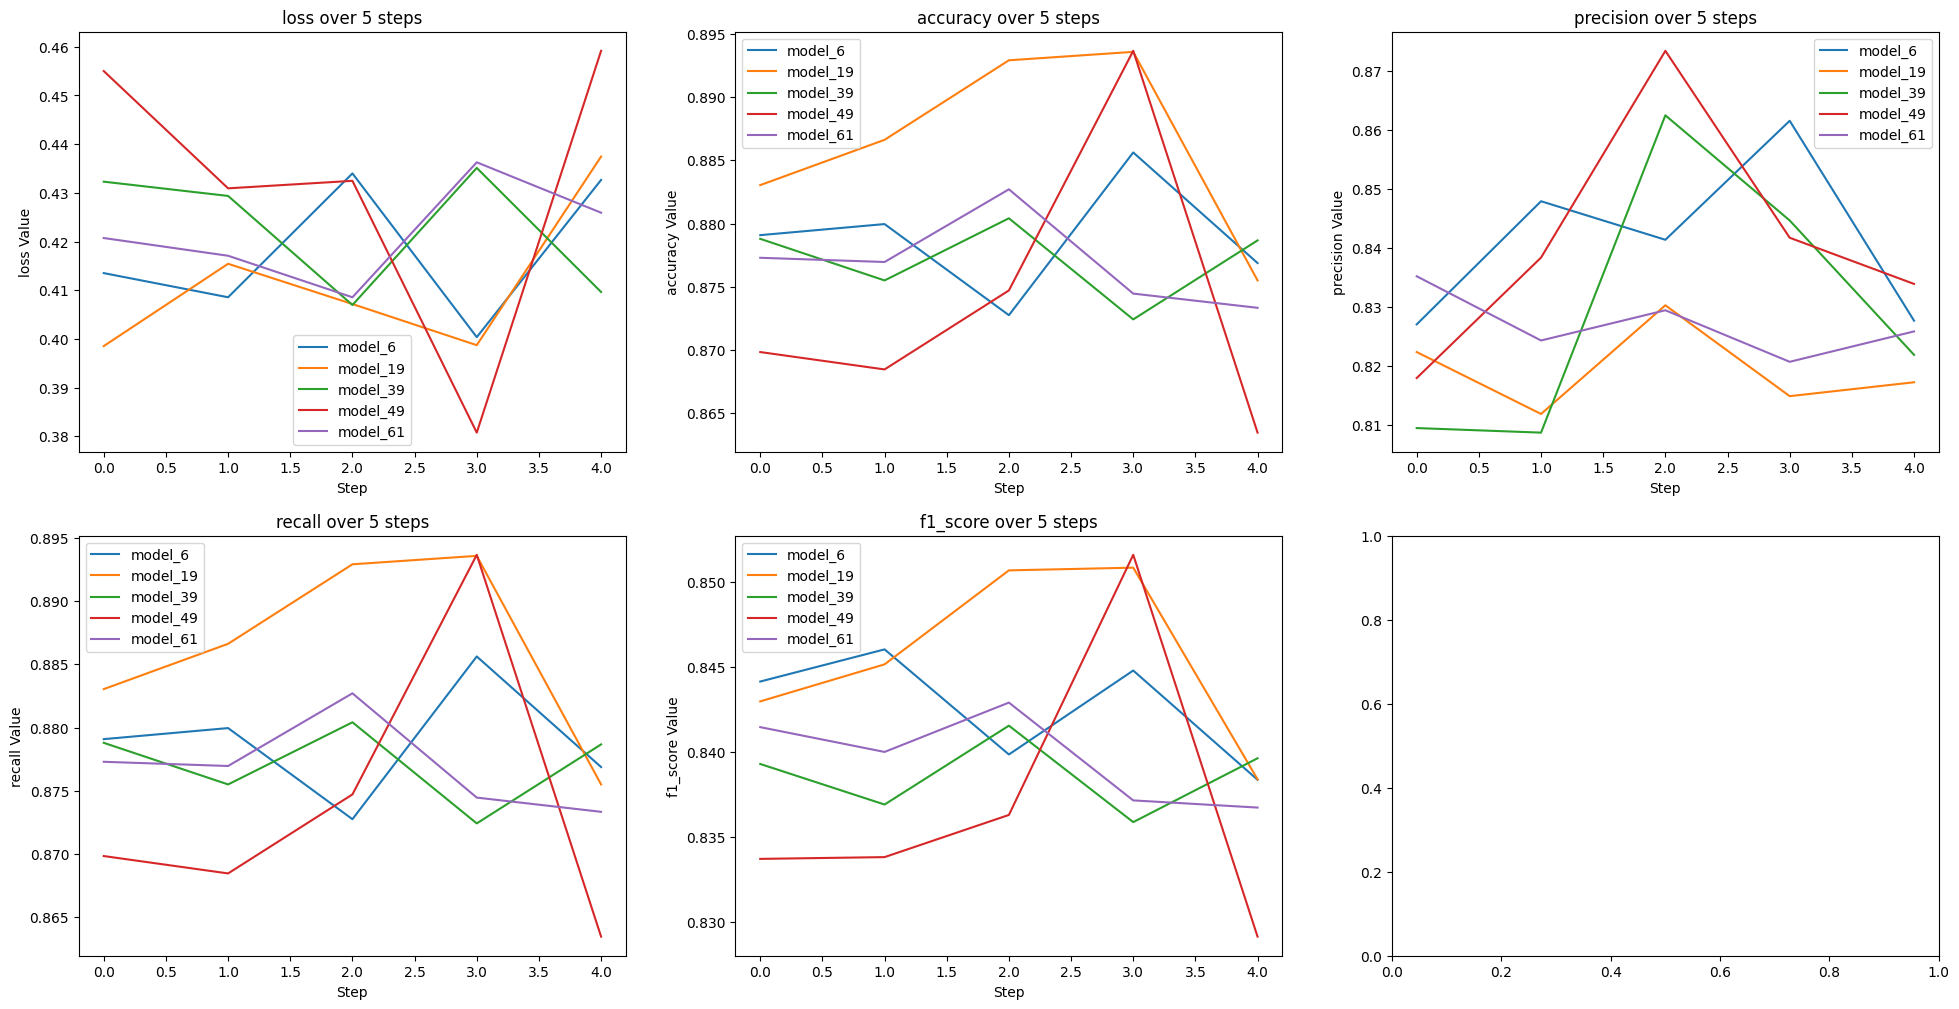

In [40]:
plot_histories("val", gather_histories(best_models))

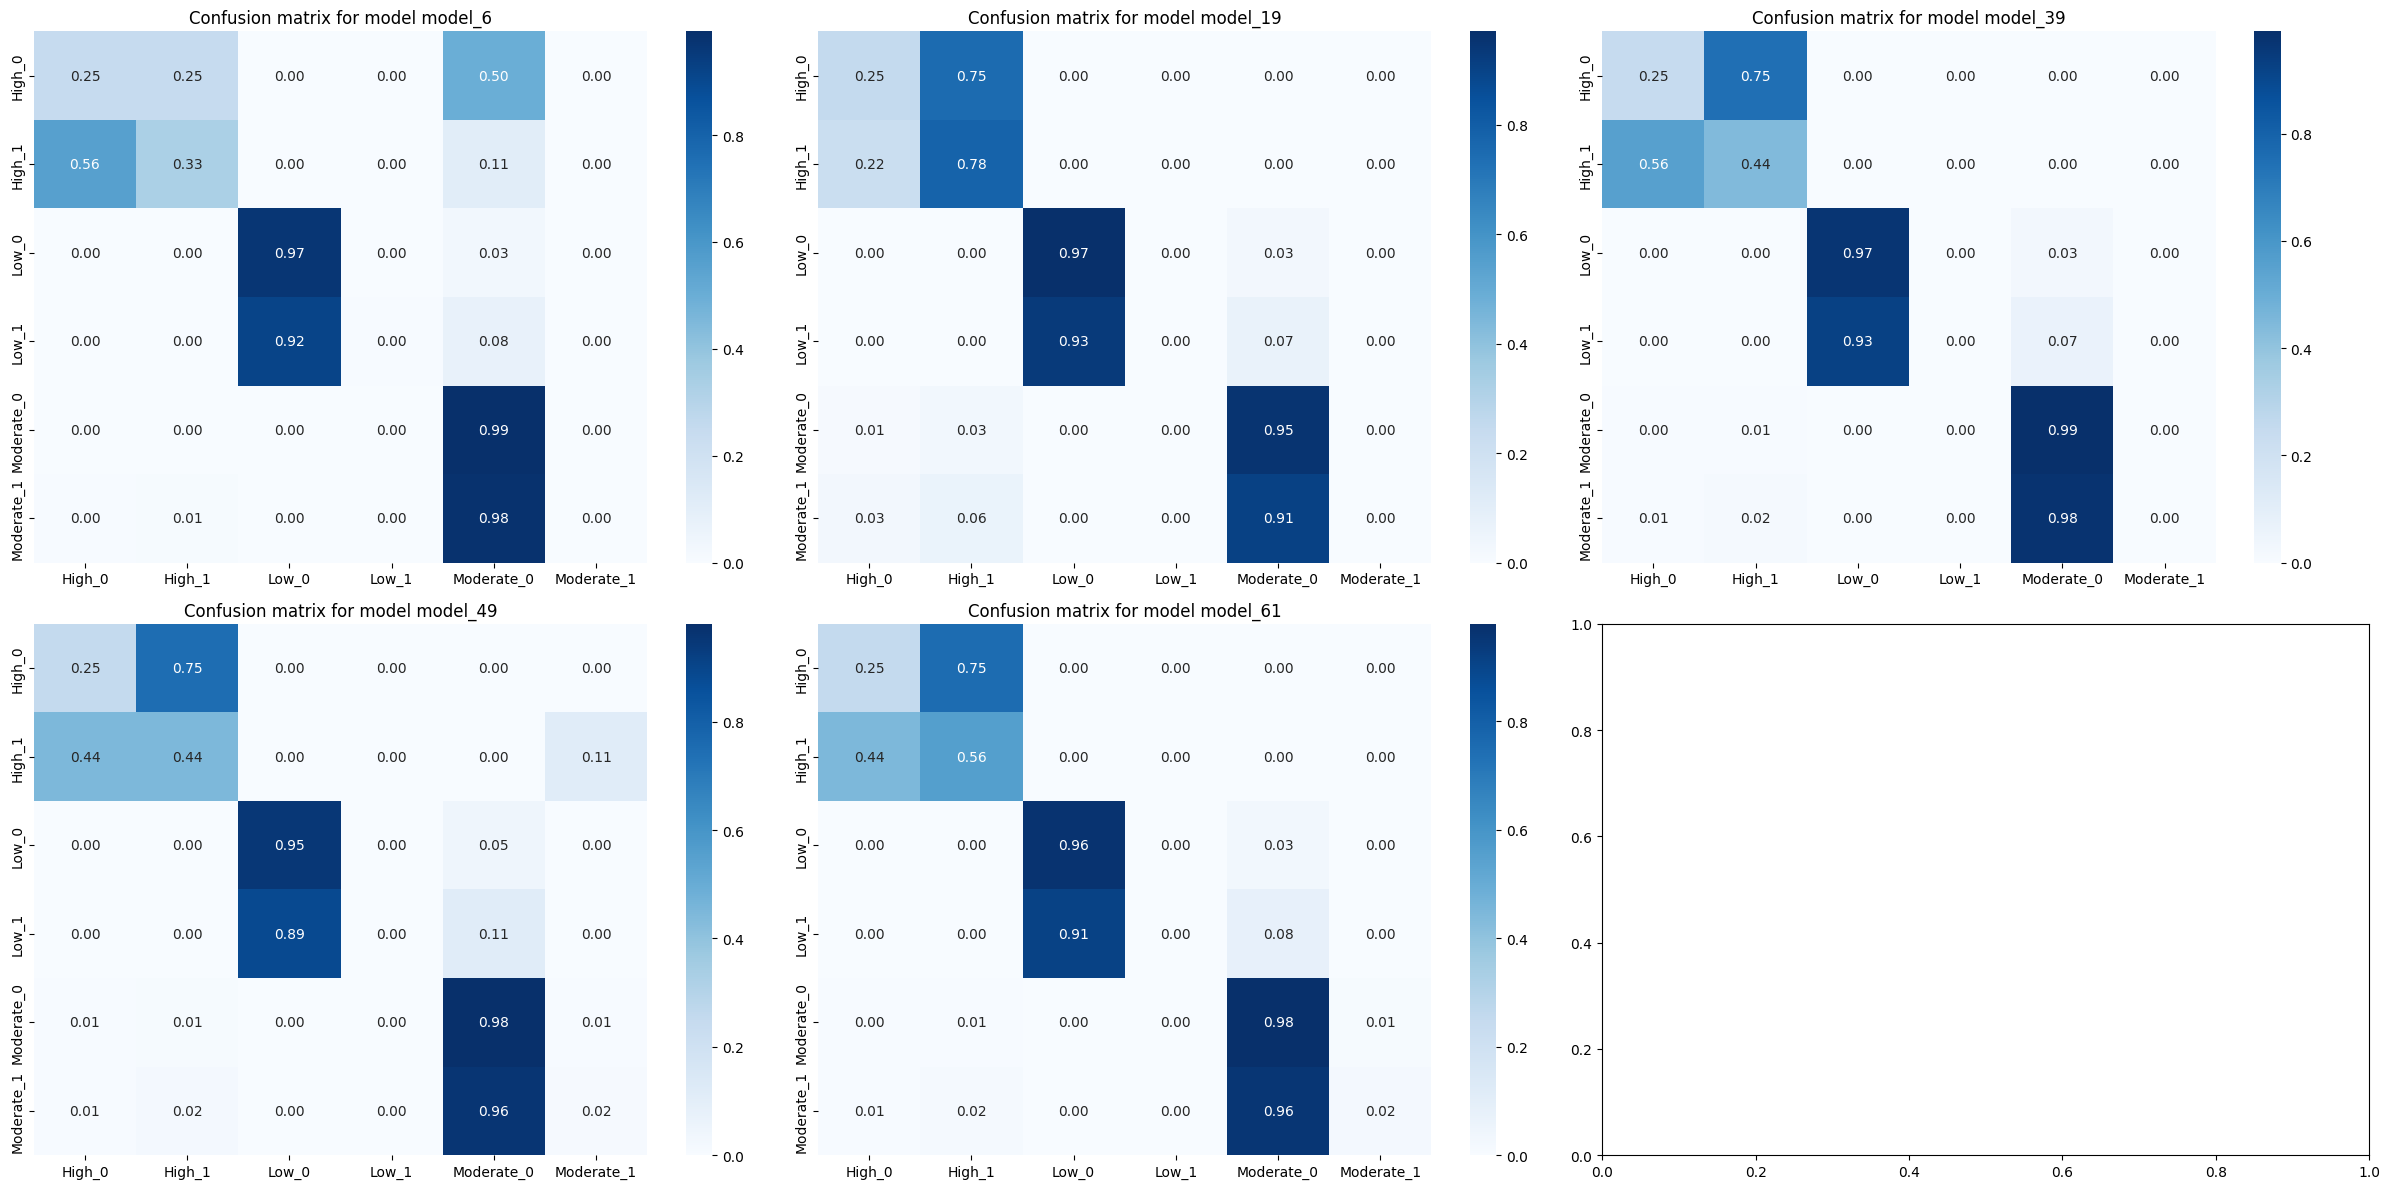

In [41]:
models_list = [model for model, _ in best_models.values()]
plot_best_heatmaps(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

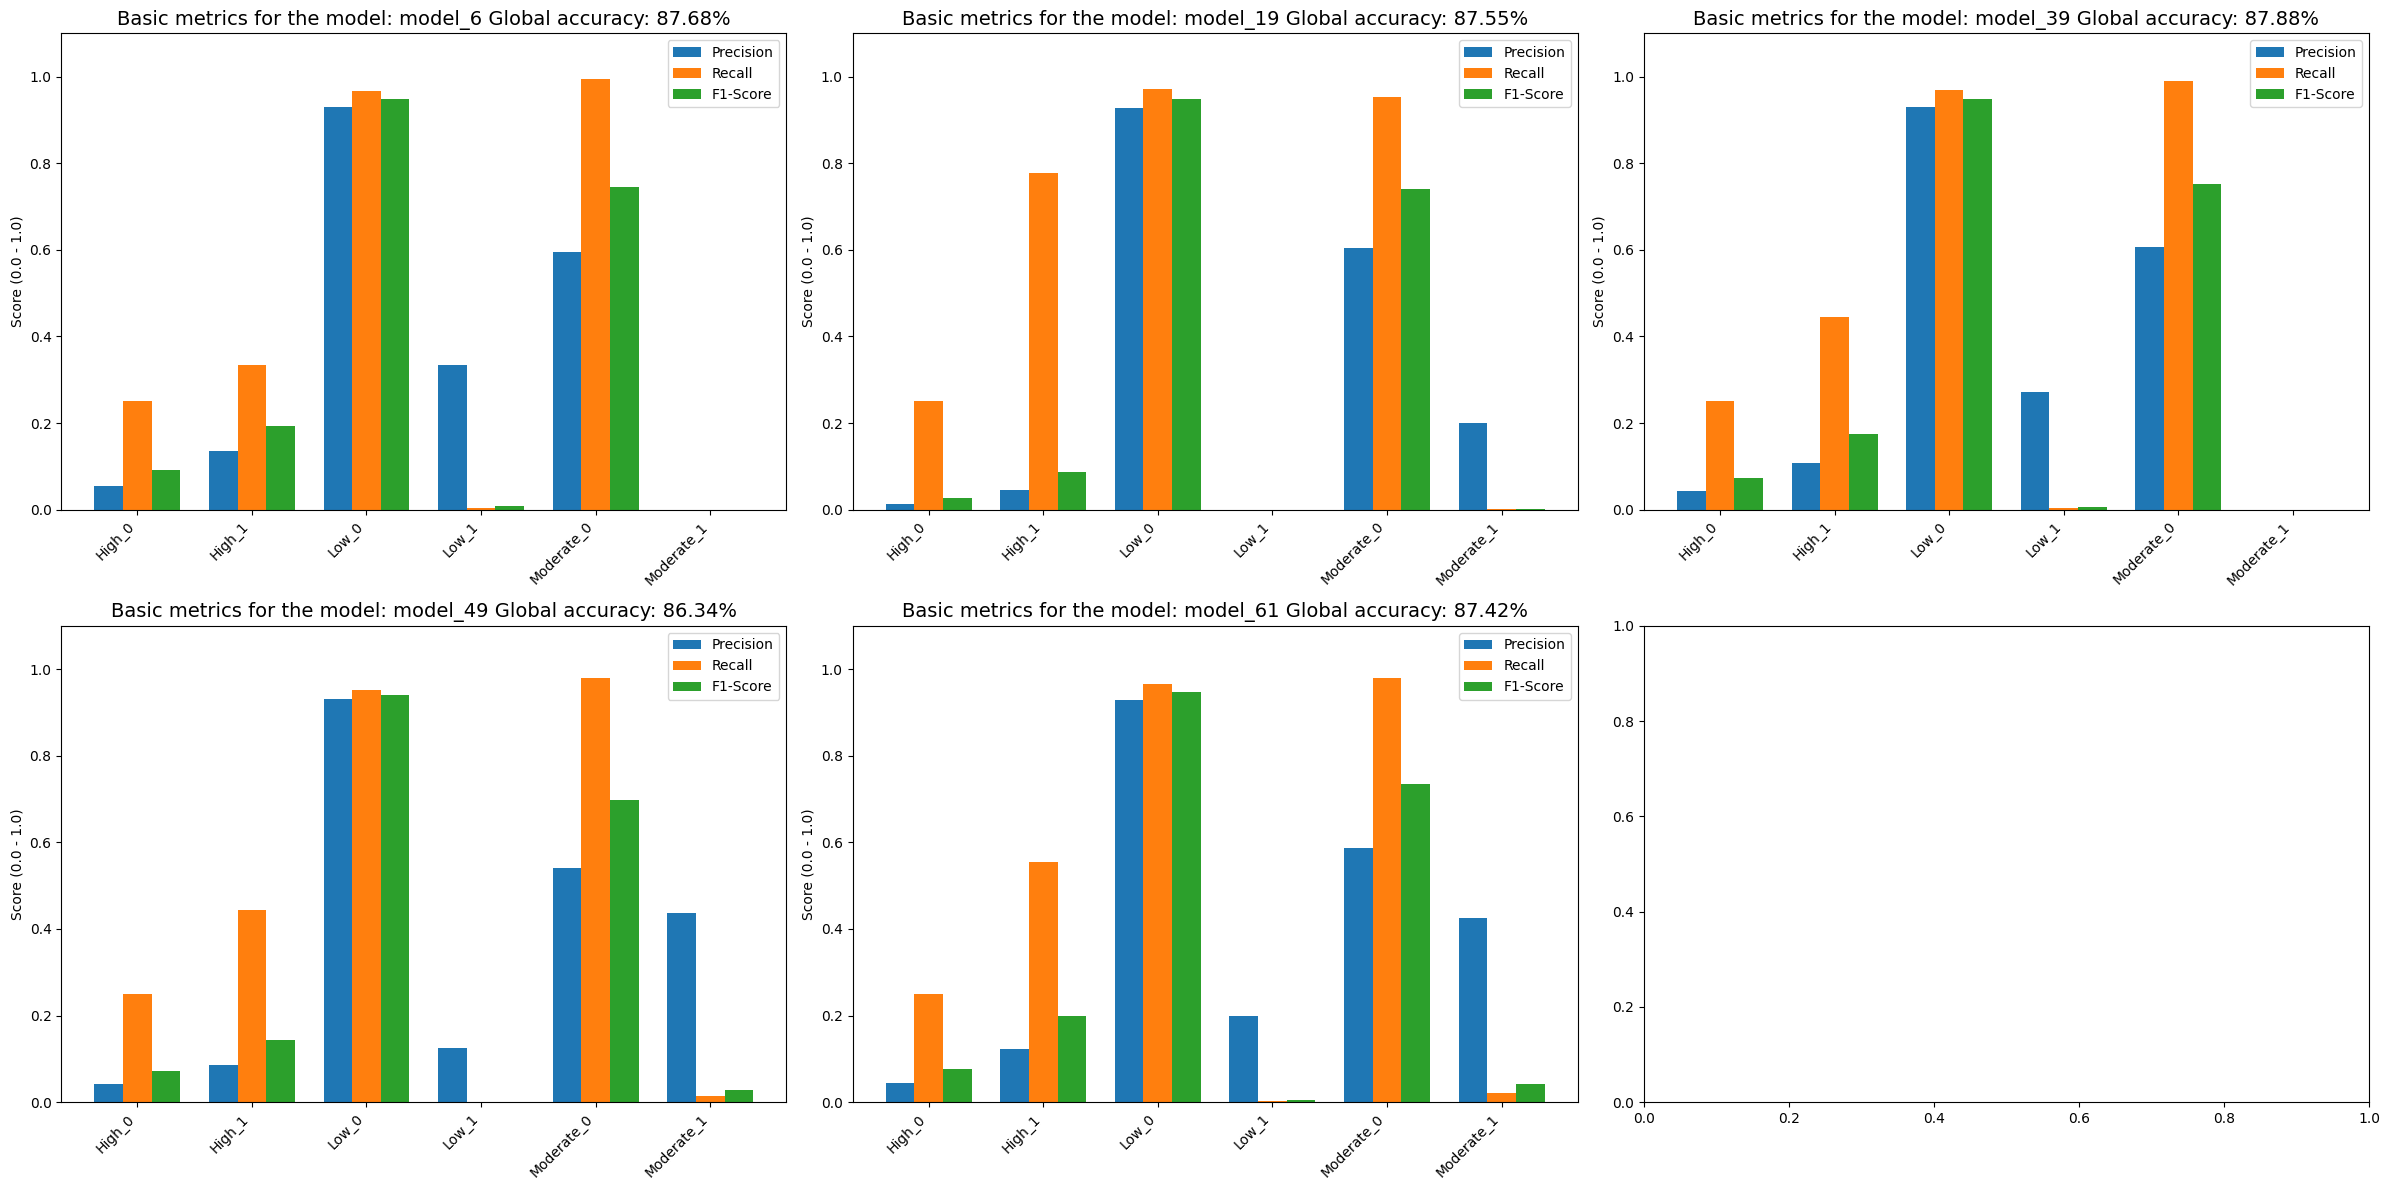

In [42]:
plot_best_basic_scores(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

We can see that these methods had a harder time classifying the more rare classes,

In [43]:
models_info = [model[0].model_info for model in best_models.values()]
pprint(models_info, indent=4, sort_dicts=False)

[   {   'model': {   'neurons': 64,
                     'dropouts': [0.2],
                     'is_batchnorm': [True],
                     'activations': ['ReLU'],
                     'is_skipping_conn': [False],
                     'input_shape': 37,
                     'output_shape': 6,
                     'name': 'model_6'},
        'train': {   'epochs': 5,
                     'optimizer': 'Adam',
                     'criterion': 'CrossEntropyLoss',
                     'batch_size': 64,
                     'learning_rate': 0.001,
                     'lr_decay': 1e-05}},
    {   'model': {   'neurons': 128,
                     'dropouts': [-1, 0.2, 0.4],
                     'is_batchnorm': [True, False, True],
                     'activations': ['ReLU', 'GELU', 'GELU'],
                     'is_skipping_conn': [False, True, False],
                     'input_shape': 37,
                     'output_shape': 6,
                     'name': 'model_19'},
        'train'

What the testing would be without the classical methods, I'm testing the `RandomForestClassifier`, `BaggingClassifier`, `SVC` and `XGBoost` to verify the supremacy of the NN here. I'm using `GridSearch` here to find the best hyperparameters for each algorithm with 5-fold validation. The results will be presented below using exisiting plotting methods for test set.

In [24]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

In [50]:


classic_models = {
    "random_forest": RandomForestClassifier(),
    "bagging" : BaggingClassifier(),
    "svc": LinearSVC(),
    "xgboost": XGBClassifier()
}

param_grids = {
    "random_forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 30, 50]
    },
    "bagging": {
        "n_estimators": [50, 100, 200],
        "max_samples": [0.5, 0.8, 1.0]
    },
    "svc": {
        "C": [0.1, 1, 10],
        "penalty": ["l1", "l2"],
        "dual": [False]
    },
    "xgboost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5, 7]
    }
}

df_train = pd.read_csv(ROOT_PATH / "data" / "train_data.csv")
df_test = pd.read_csv(ROOT_PATH / "data" / "test_data.csv")

x_train = df_train.drop(['target'], axis=1)
y_train = df_train['target']

x_test = df_test.drop(['target'], axis=1)
y_test = df_test['target']
best_models = {}
predictions = {}

In [115]:


for name, model in classic_models.items():
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=4
    )

    grid_search.fit(x_train, y_train)

    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(x_test)
    predictions[name] = y_pred

    print(f"{name} best parameters: {grid_search.best_params_}")

random_forest best parameters: {'max_depth': 30, 'n_estimators': 200}
bagging best parameters: {'max_samples': 1.0, 'n_estimators': 200}
svc best parameters: {'C': 10, 'dual': False, 'penalty': 'l2'}
xgboost best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


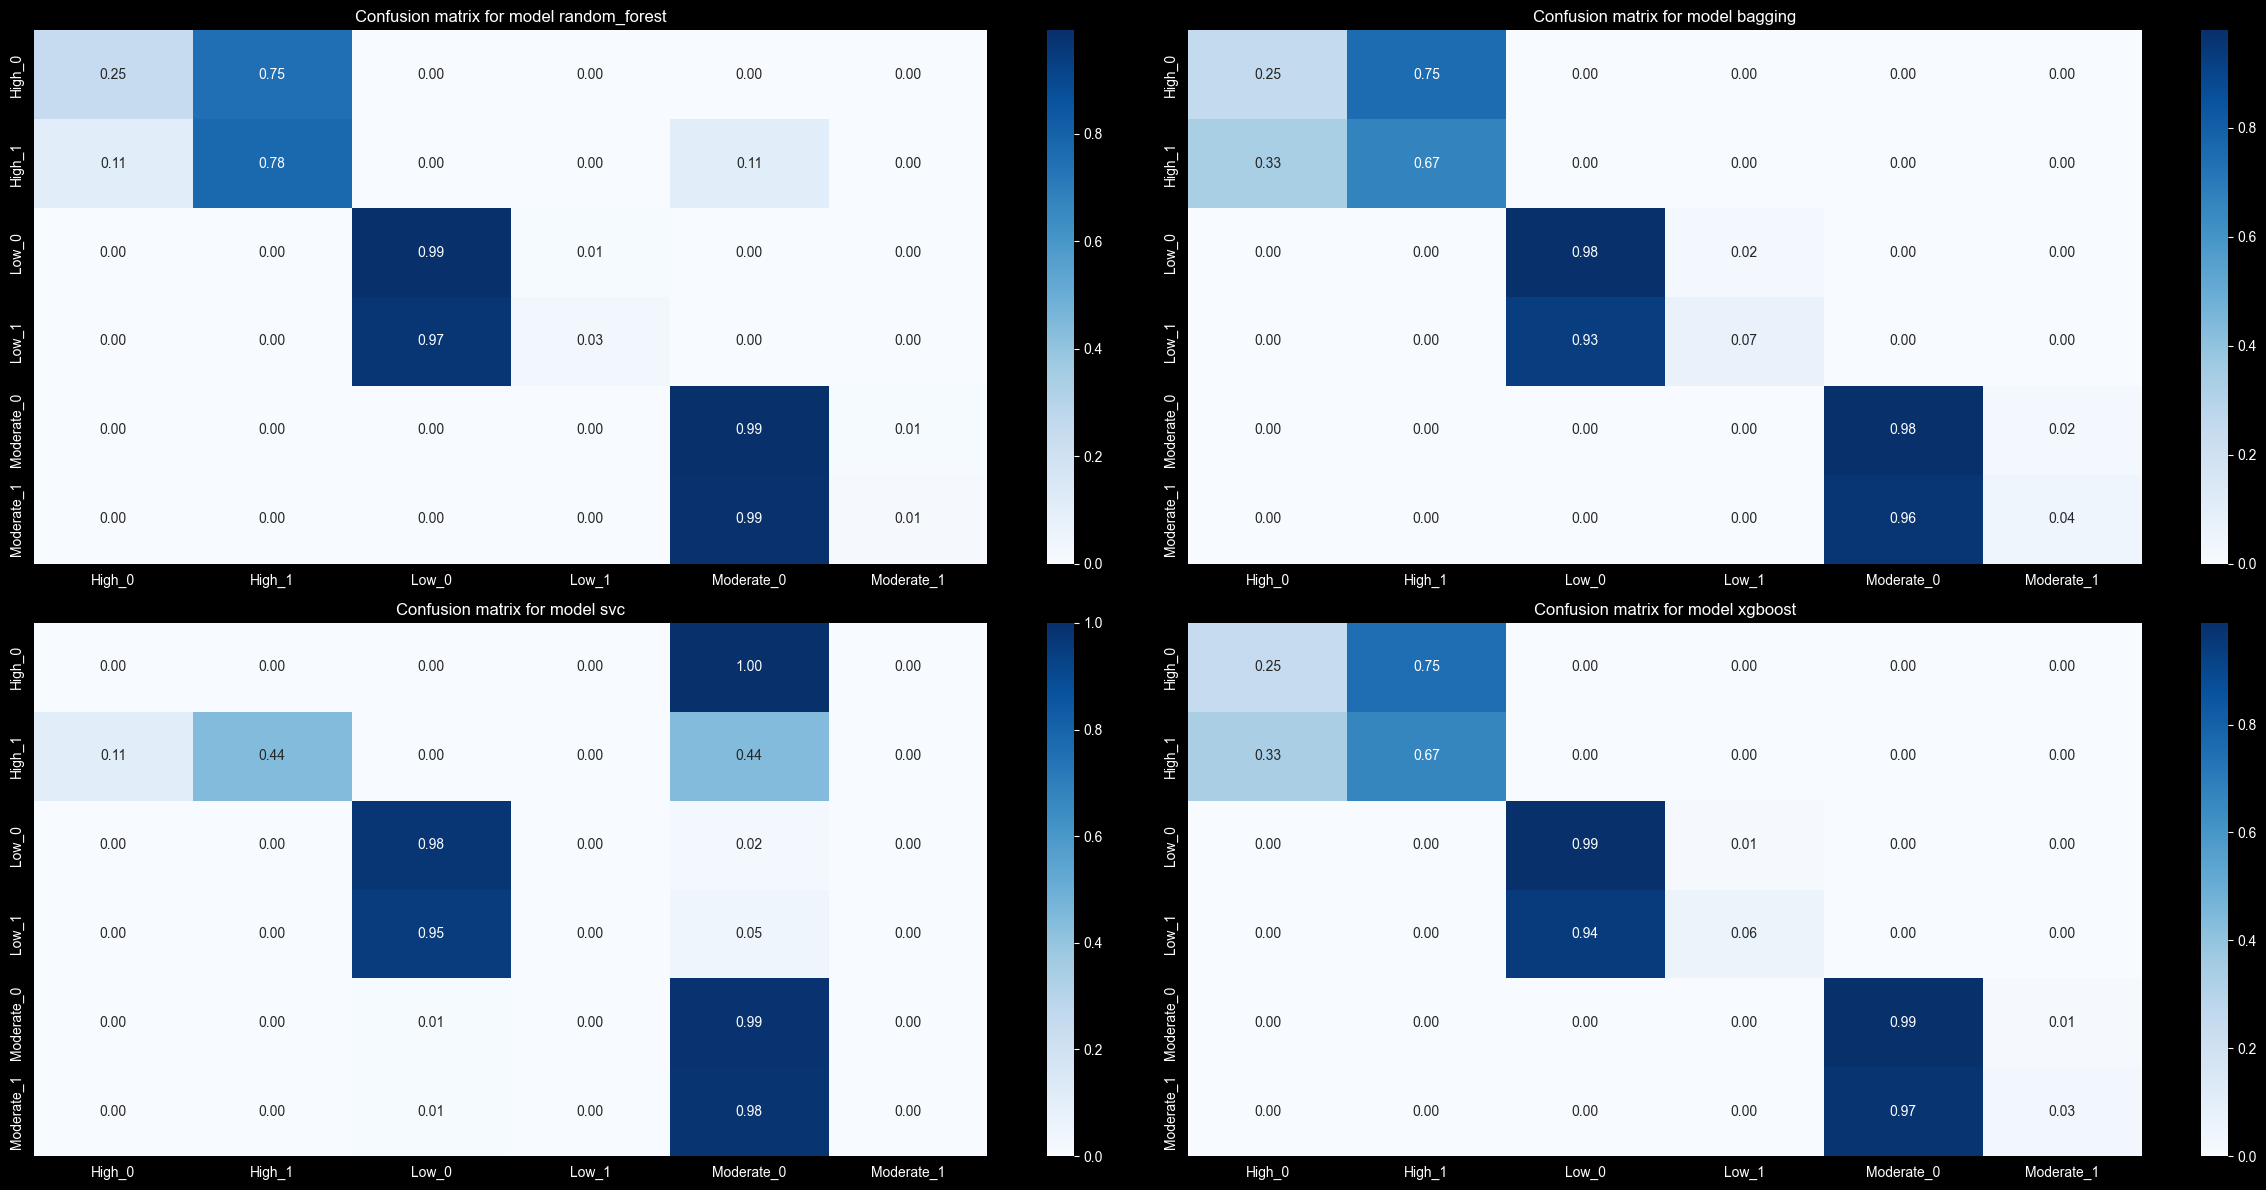

In [116]:
fig, axs = plt.subplots(2, 2, figsize=(24, 12))

for idx, item in enumerate(predictions.items()):
    name, y_pred = item
    x, y = idx//2, idx%2
    generate_heatmap(y_test, y_pred, ax=axs[x, y], title=f"Confusion matrix for model {name}", class_names=class_names)
plt.tight_layout()
plt.show()

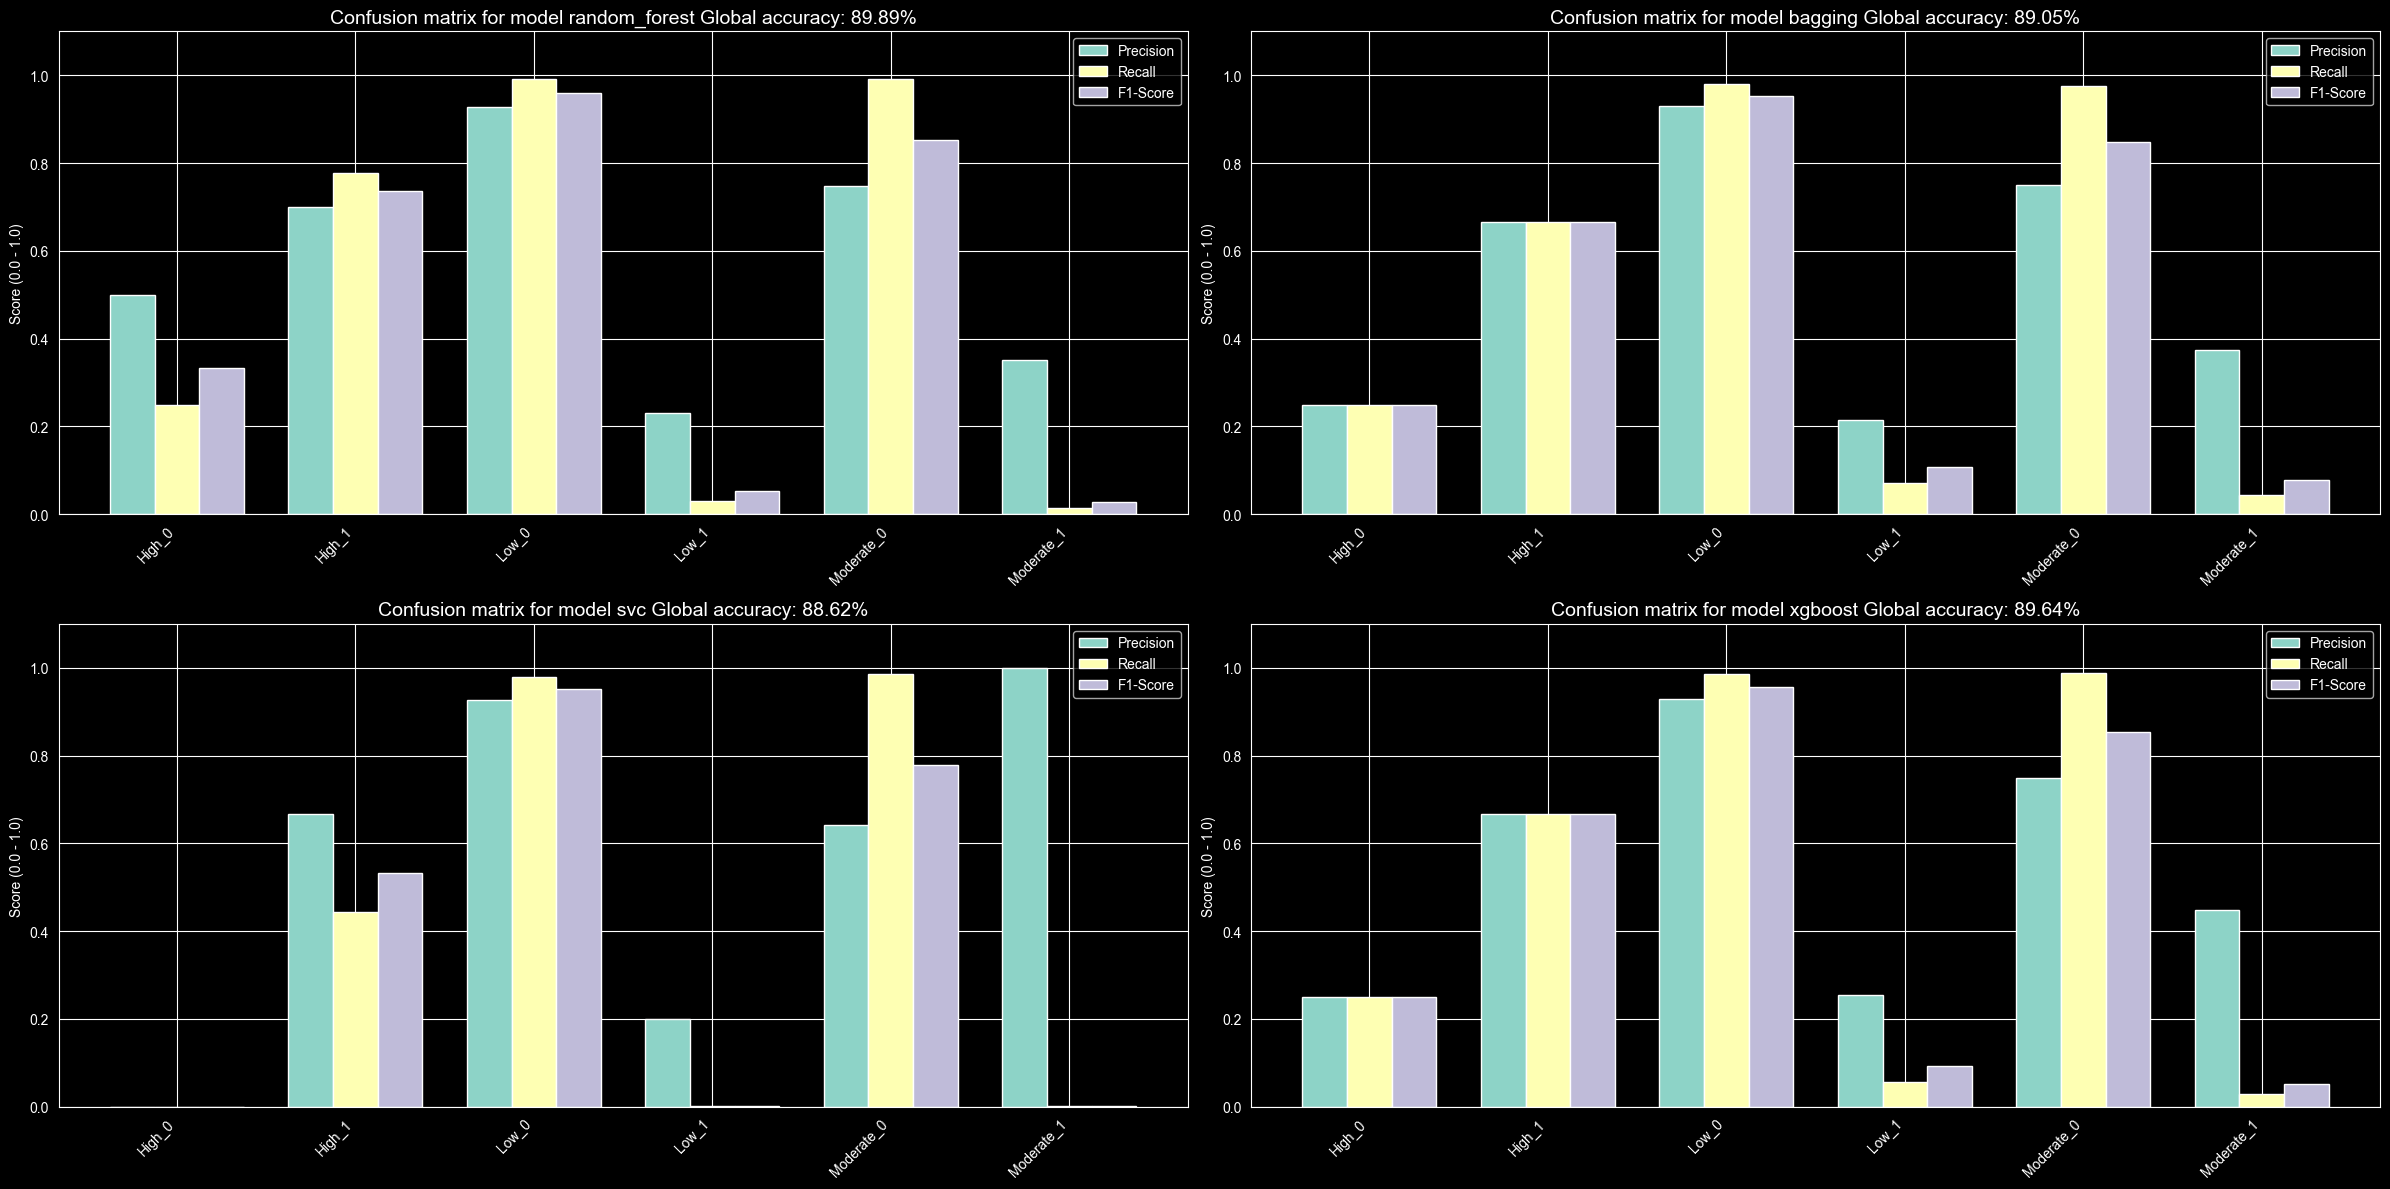

In [117]:
fig, axs = plt.subplots(2, 2, figsize=(24, 12))

for idx, item in enumerate(predictions.items()):
    name, y_pred = item
    x, y = idx//2, idx%2
    plot_test_metrics(y_test.to_numpy(), y_pred, ax=axs[x, y], title=f"Confusion matrix for model {name}", class_names=class_names)
plt.tight_layout()
plt.show()

So the classical methods overall had similar accuracy to the models that did not used the weights for the classes, but were good at classifying the `High_1` class. Nevertheless they were not as good as the models that used the sqrt weight for the classes, which maybe had worse accuracy, but were a bit better at classifying the classes with fewer data.

Last step is to check the results on the unedited training dataset, for the check let's compare one of the best classical methods and one best model. For the classical model I've chosen the RandomForest because XGBoost might work better even on the unedited data, because of it's mechanism to increase the priority of inccorectly classified data, which would probably be the classes with fewer samples.

In [25]:
import os

train_unedited = pd.read_csv("data/train_data_unedited.csv")
x, y = train_unedited.drop(['target'], axis = 1), train_unedited['target']

In [56]:
best_classical_model = RandomForestClassifier(max_depth=30, n_estimators=200)

In [57]:
best_classical_model.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

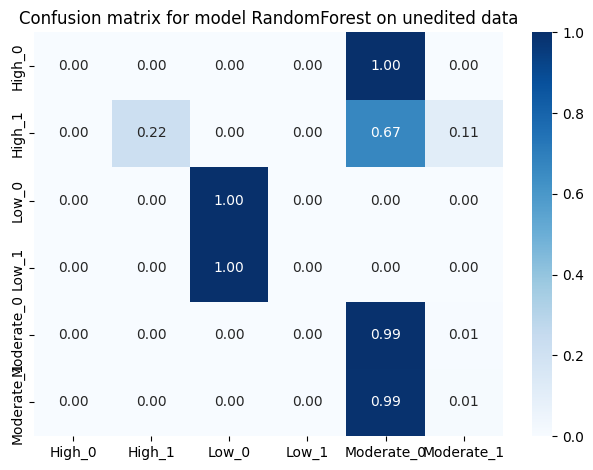

In [61]:
y_pred = best_classical_model.predict(x_test)
generate_heatmap(y_test, y_pred, class_names=class_names, title=f"Confusion matrix for model RandomForest on unedited data")
plt.tight_layout()

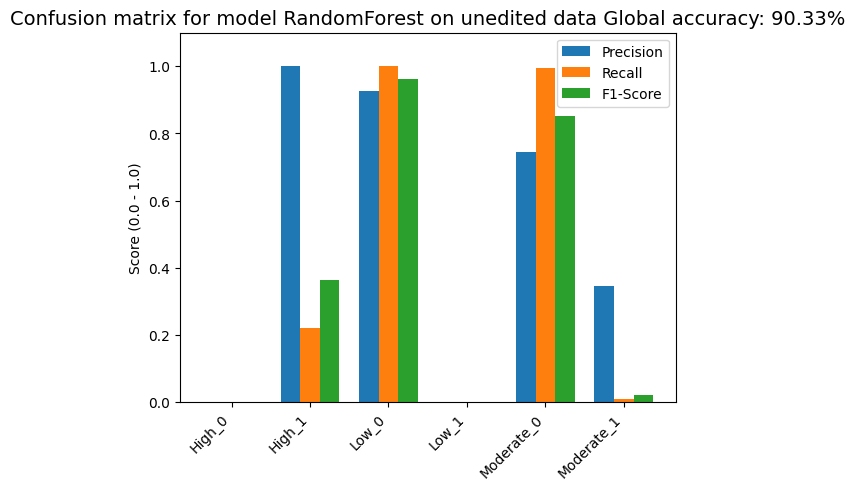

In [60]:
plot_test_metrics(y_test.to_numpy(), y_pred, title=f"Confusion matrix for model RandomForest on unedited data", class_names=class_names, ax = plt.figure().gca())

Despite scoring better results, the fairness of this model is for sure lower, it could not predict the class **High_0** at all

Now checking the NN model, but first i need to change the train function a bit

In [26]:
from tqdm.notebook import tqdm
def train_model_on_unedited(model, batch_size, epochs, learning_rate, weight_decay, optimizer, criterion, device, metrics: dict = None):

    optimizer = optimizer(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    train_data = DataLoader(BurnoutDataset("unedited"), batch_size=batch_size, shuffle=True)
    val_data = DataLoader(BurnoutDataset("val"), batch_size=batch_size, shuffle=True)

    if metrics is not None:
        history = ModelHistory(["train", "val"], model.name,  **metrics)
    else:
        history = ModelHistory(["train", "val"], model.name)

    for epoch in range(epochs):

        _train_one_epoch(model, train_data, device, criterion, optimizer, history)
        _val_one_epoch(model, val_data, device, criterion, history)


    train_info = {
        "epochs": epochs,
        "optimizer" : optimizer.__class__.__name__,
        "criterion" : criterion.__class__.__name__,
        "batch_size" : batch_size,
        "learning_rate" : learning_rate,
        "lr_decay" : weight_decay,
    }

    model.add_training_info(train_info)


    return model, history


I will be using a model without the class weights, because creating the weights for this dataset could have too big of an impact during calculating the gradients, additionally using this model will better visualize the effect of under/upsampling

In [34]:
model = Model(
    neurons=64,
    dropouts=[0.2],
    is_batchnorm=[True],
    activations=[nn.ReLU],
    is_skipping_conn=[False],
    input_shape=37,
    output_shape=6,
    name=f"model_on_unedited"
).to("cpu")

model, history = train_model_on_unedited(
    model,
    batch_size=64,
    epochs=5,
    learning_rate=0.001,
    weight_decay=1e-5,
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss(),
    device="cpu",
    metrics= {
        "accuracy" : accuracy_score,
        "precision" : precision_metric,
        "recall" : recall_metric,
        "f1_score" : f1_score_metric
    }
)





  0%|          | 0/1500 [00:00<?, ?it/s]



  3%|▎         | 38/1500 [00:00<00:03, 372.85it/s]



  5%|▌         | 76/1500 [00:00<00:04, 334.59it/s]



  8%|▊         | 115/1500 [00:00<00:03, 350.32it/s]



 11%|█         | 161/1500 [00:00<00:03, 384.72it/s]



 13%|█▎        | 200/1500 [00:00<00:03, 384.42it/s]



 17%|█▋        | 260/1500 [00:00<00:02, 452.28it/s]



 21%|██        | 315/1500 [00:00<00:02, 478.52it/s]



 25%|██▌       | 376/1500 [00:00<00:02, 516.55it/s]



 29%|██▉       | 437/1500 [00:00<00:01, 539.80it/s]



 34%|███▍      | 509/1500 [00:01<00:01, 593.94it/s]



 38%|███▊      | 572/1500 [00:01<00:01, 604.37it/s]



 42%|████▏     | 633/1500 [00:01<00:01, 593.29it/s]



 46%|████▋     | 695/1500 [00:01<00:01, 600.17it/s]



 51%|█████     | 763/1500 [00:01<00:01, 620.07it/s]



 55%|█████▌    | 831/1500 [00:01<00:01, 634.06it/s]



 60%|█████▉    | 896/1500 [00:01<00:00, 633.74it/s]



 64%|██████▍   | 960/1500 [00:01<00:00, 608.49it/s]



 68%|██████▊   | 10

{   'model': {   'neurons': 64,
                     'dropouts': [0.2],
                     'is_batchnorm': [True],
                     'activations': ['ReLU'],
                     'is_skipping_conn': [False],
                     'input_shape': 37,
                     'output_shape': 6,
                     'name': 'model_6'
            },
    'train': {   'epochs': 5,
                     'optimizer': 'Adam',
                     'criterion': 'CrossEntropyLoss',
                     'batch_size': 64,
                     'learning_rate': 0.001,
                     'lr_decay': 1e-05}
    }
}

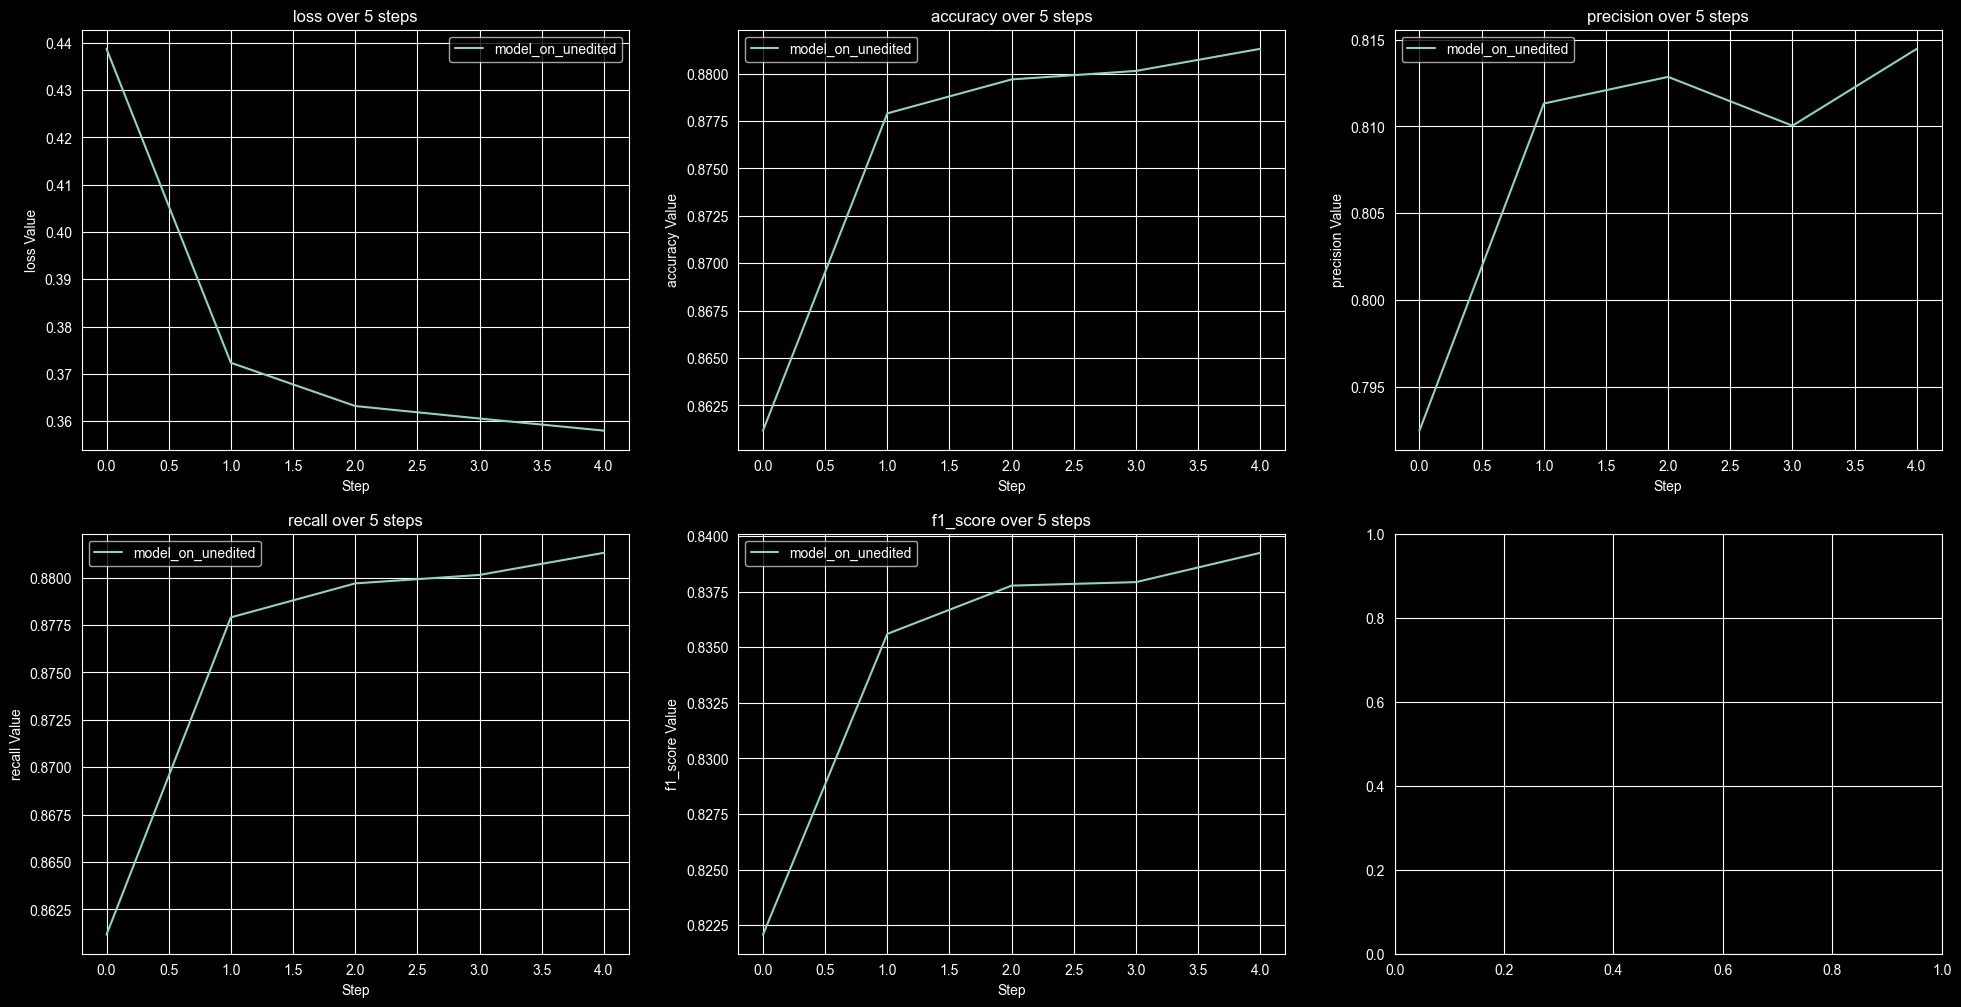

In [36]:
plot_histories("train", [history])

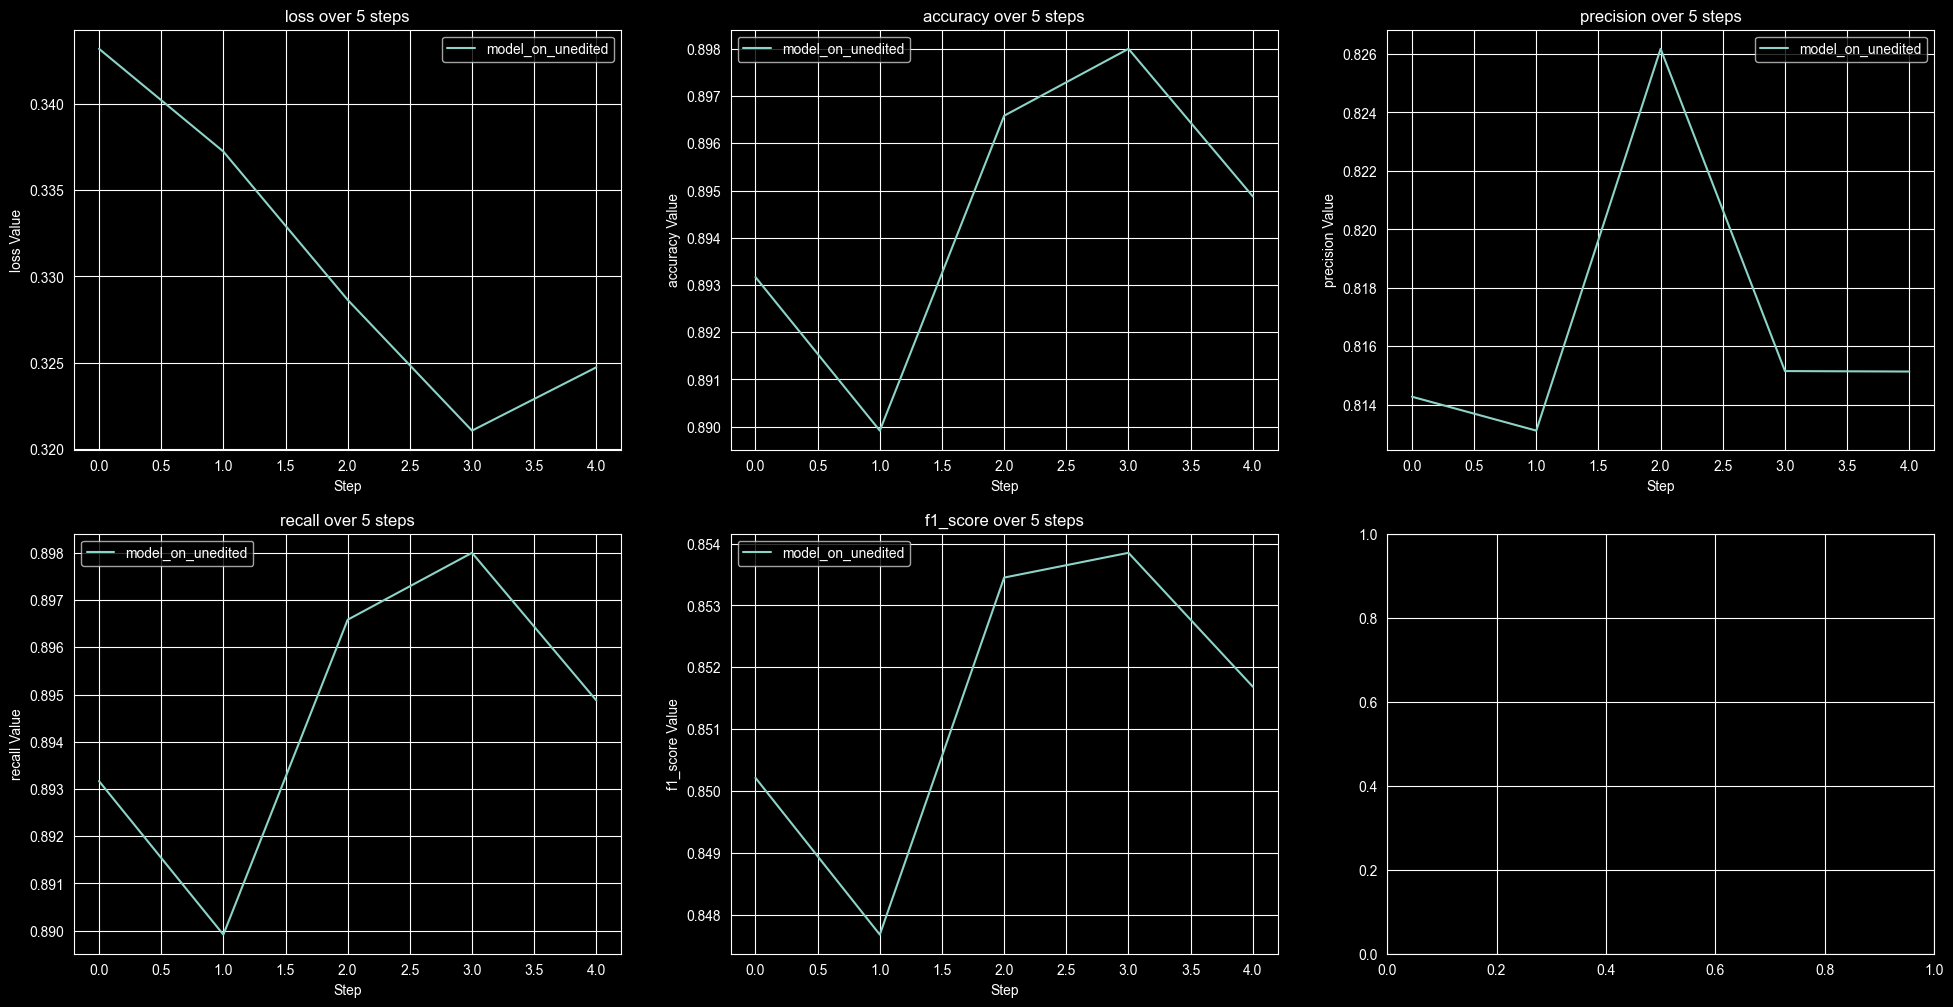

In [39]:
plot_histories("val", [history])

In [43]:
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=False)
_, y_pred, y_true = test_model(model, test_loader, nn.CrossEntropyLoss(), "cpu")

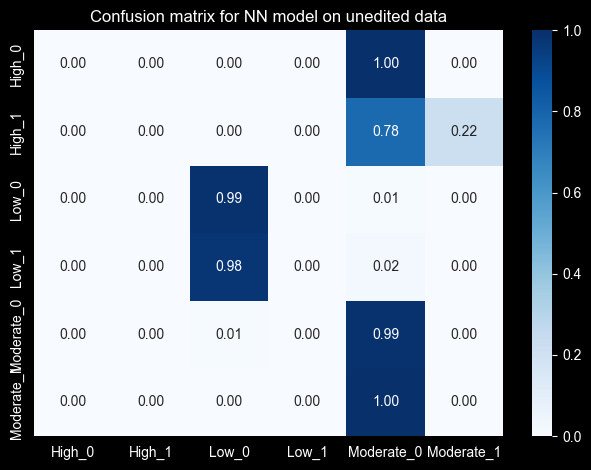

In [45]:
generate_heatmap(y_true, y_pred, class_names=class_names, title=f"Confusion matrix for NN model on unedited data")
plt.tight_layout()

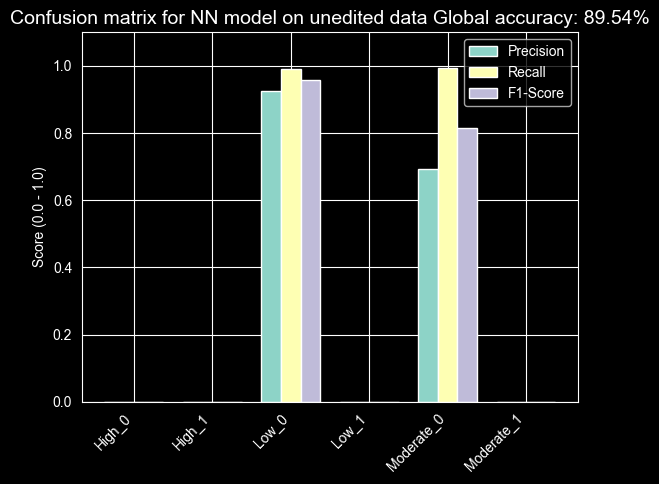

In [47]:
plot_test_metrics(y_true, y_pred, title=f"Confusion matrix for NN model on unedited data", class_names=class_names, ax = plt.figure().gca())

As we can see the model did perform worse on the classes with fewer samples, same as the Random Forest model.

## Final conclusions

- The dataset proved to be a challenge with its low samples for some classes
- To help increase the model's fairness I've used techniques such as down/upsampling, using RandomDownsampling and SMOTE for upsampling and adding class weights for the NN models
- To choose the best dataset for training I should have tested few training datasets before choosing one (unedited dataset, testing different upsampling/downsampling methods)
- For each dataset I should have explained the features importance using for example SHAP
- I didn't check for any outliers and didn't clip the values
- The NN models were just as good as classical methods, despite using Random Search on roughly 200 of them, the model architecture enabled for more than 50 000 models, when adding at least 1 hidden layer
- I've tested and visualized the results for models, focusing on 1 hyperparameter where possible